# Applying Symbolic Regression to data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pysr import PySRRegressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

[juliapkg] Found dependencies: /Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/juliapkg/juliapkg.json
[juliapkg] Locating Julia =1.10.0, ^1.10.3
[juliapkg] Querying Julia versions from https://julialang-s3.julialang.org/bin/versions.json
[juliapkg] WARNING: About to install Julia 1.11.6 to /Users/pomeret/Desktop/overexpression_signalling/overexpression/julia_env/pyjuliapkg/install.
[juliapkg]   If you use juliapkg in more than one environment, you are likely to
[juliapkg]   have Julia installed in multiple locations. It is recommended to
[juliapkg]   install JuliaUp (https://github.com/JuliaLang/juliaup) or Julia
[juliapkg]   (https://julialang.org/downloa

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed ADTypes ────────────────── v1.17.0
   Installed Tricks ─────────────────── v0.1.12
   Installed JLLWrappers ────────────── v1.7.1
   Installed StatisticalTraits ──────── v3.5.0
   Installed micromamba_jll ─────────── v1.5.12+0
   Installed Preferences ────────────── v1.5.0
   Installed DynamicExpressions ─────── v1.10.3
   Installed Optim ──────────────────── v1.13.2
   Installed Compat ─────────────────── v4.18.0
   Installed DataStructures ─────────── v0.19.0
   Installed DispatchDoctor ─────────── v0.4.26
   Installed SymbolicRegression ─────── v1.11.3
   Installed StatsBase ──────────────── v0.34.6
   Installed ChainRulesCore ─────────── v1.26.0
   Installed SortingAlgorithms ──────── v1.2.2
   Installed DifferentiationInterface ─ v0.7.4
   Installed LossFunctions ──────────── v1.0.2
    Updating `~/Desktop/overexpression_signalling/overexpression/julia_env/Project.toml`
⌅ [609

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
raw_data = pd.read_csv("../../data/processed/filtered_time_trajectories.csv")
unique_markers = raw_data['marker'].unique()

raw_data['u-ERK1-2'] = raw_data['p-ERK1-2_max'] - raw_data['p-ERK1-2']

raw_data

,marker,GFP_bin,timepoint,GFP,p-ERK1-2,p-MEK1-2,p-RAF,p-p90RSK,p-MAPKAPK2,p-PDK1,...,p-ERK1-2_range,p-MEK1-2_range,p-ERK1-2_fit,p-MEK1-2_fit,p-RAF_fit,p-p90RSK_fit,p-MAPKAPK2_fit,p-PDK1_fit,p-MKK3-6_fit,u-ERK1-2
0,ABL1,0.0,0,0.002565,1.254476,1.751215,0.721822,0.738379,2.749147,2.522660,...,1.244239,0.784651,1.285355,1.774367,0.609829,0.776356,2.666457,2.366938,1.675299,1.244239
1,ABL1,0.0,5,0.001577,2.448472,2.535867,0.496611,2.222533,2.688830,2.224343,...,1.244239,0.784651,2.392879,2.481974,0.694847,2.267530,2.837855,2.486452,1.222687,0.050243
2,ABL1,0.0,10,0.001655,2.498715,2.515224,0.866328,2.439627,3.082402,2.696167,...,1.244239,0.784651,2.266816,2.394304,0.750836,2.100892,2.930030,2.560796,1.675298,0.000000
3,ABL1,0.0,15,0.001869,1.740379,2.043900,0.719653,1.416048,2.880376,2.547036,...,1.244239,0.784651,2.155102,2.317496,0.785231,1.858076,2.970444,2.602775,1.675299,0.758336
4,ABL1,0.0,30,0.002174,1.971318,2.216377,0.914907,1.512044,3.018678,2.751365,...,1.244239,0.784651,1.890629,2.139599,0.809893,1.351194,2.942819,2.618563,1.675299,0.527397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11516,untransfected4,38.0,5,2.302069,3.466068,2.983050,0.777438,2.023848,2.314603,1.914813,...,2.267238,0.685212,3.484061,2.985566,0.823180,2.096220,2.445225,1.918632,1.197562,0.127282
11517,untransfected4,38.0,10,2.240226,3.593350,2.992375,0.890372,2.404489,2.590829,2.080163,...,2.267238,0.685212,3.408637,2.917406,0.845942,2.196169,2.498836,2.009566,1.253018,0.000000
11518,untransfected4,38.0,15,2.267303,2.919287,2.733287,0.803575,1.862190,2.490066,1.925309,...,2.267238,0.685212,3.224280,2.845688,0.861551,2.046715,2.523042,2.048923,1.279217,0.674063
11519,untransfected4,38.0,30,2.273431,2.957403,2.724717,0.933310,1.593922,2.564638,2.116259,...,2.267238,0.685212,2.747642,2.676912,0.879778,1.554872,2.509606,2.019758,1.269767,0.635947


In [3]:
data_fitted = pd.read_csv('../../data/processed/extra_fit_trajectories.csv')
data_fitted.columns = data_fitted.columns.str.replace('_fit$', '', regex=True)

# Remove trajectories (marker/bin) that contain NaNs in any column
data = data_fitted.groupby(['marker', 'GFP_bin']).filter(lambda g: not g.isnull().any().any())

In [4]:
def get_trajectories(data, marker):
    """
    Get the trajectories of a specific marker from the data.
    """
    data = data[data['marker'] == marker]
    data = data.drop(columns=['marker', 'timepoint', 'GFP_bin'])
    trajectories = [data.iloc[i:i+8,:] for i in range(0, len(data), 8)]
    return trajectories

In [5]:
def get_X_y(data, marker, features=data.columns):
    """
    Get the trajectories of a specific marker from the data.
    """
    data = data[data['marker'] == marker]
    data = data.dropna()
    data = data.drop(columns=['marker', 'timepoint'])
    X1_df = data.drop(['p-ERK1-2_dt', 'p-MEK1-2_dt'], axis=1)
    X1 = X1_df[features]
    y1 = data['p-ERK1-2_dt'].values
    return X1, y1

X_columns = data.drop(columns=['marker', 'timepoint', 'GFP_bin', 'p-ERK1-2_dt', 'p-MEK1-2_dt']).columns


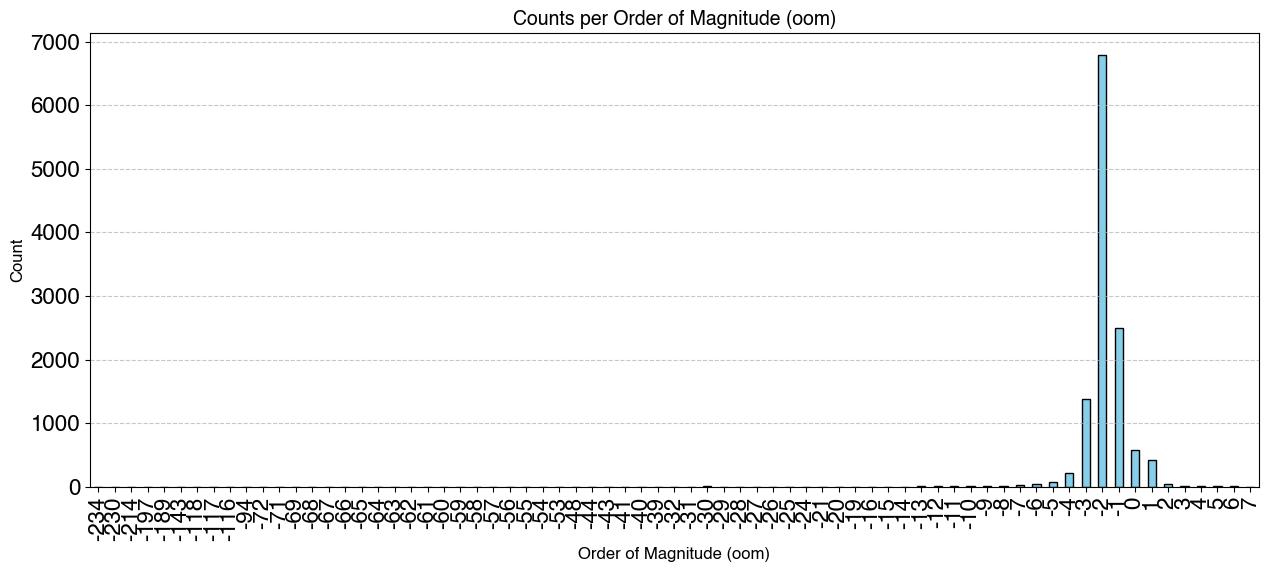

In [6]:
# Filter out non-positive values to avoid issues with log10
target_abs = data['p-ERK1-2_dt'].abs().copy()

# Bin the data by the integer part of the log10 values of the target_abs
oom_bins = np.floor(np.log10(target_abs[target_abs > 0]))  # Avoid log10 of non-positive values

# Count the number of occurrences in each bin
oom_counts = oom_bins.value_counts().sort_index()

plt.rcParams.update({
    'font.size': 16,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica']
})

# Plot the bar plot
plt.figure(figsize=(13, 6))
oom_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Order of Magnitude (oom)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Counts per Order of Magnitude (oom)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(ticks=range(len(oom_counts)), labels=oom_counts.index.astype(int), rotation=90)
plt.tight_layout()
plt.show()

In [7]:
log10_cutoff = -3

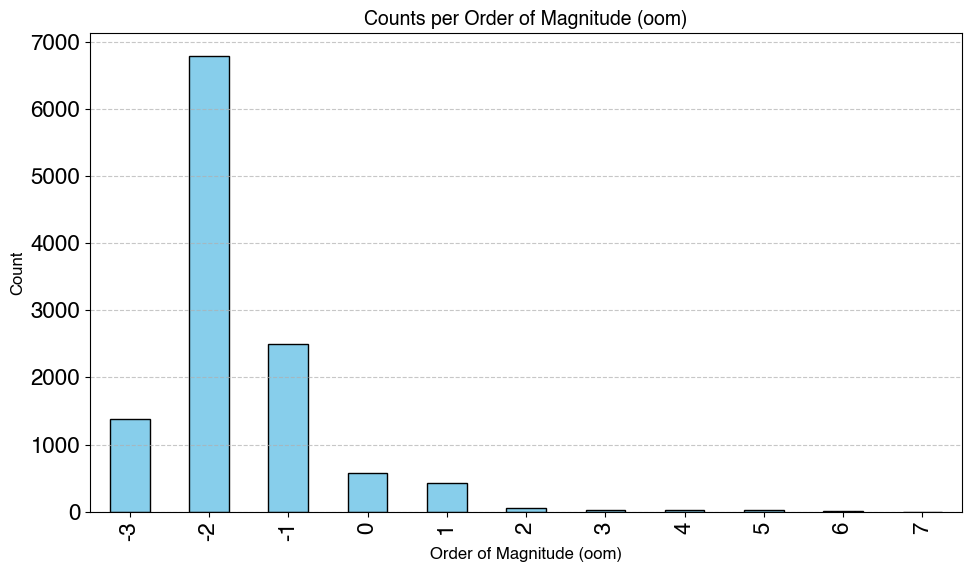

In [8]:
data_floored = data.copy()
data_floored.loc[data_floored['p-ERK1-2_dt'].abs() < 10**log10_cutoff, 'p-ERK1-2_dt'] = 0.0

# Filter out non-positive values to avoid issues with log10
target_abs = data_floored['p-ERK1-2_dt'].abs().copy()

# Bin the data by the integer part of the log10 values of the target_abs
oom_bins = np.floor(np.log10(target_abs[target_abs > 0]))  # Avoid log10 of non-positive values

# Count the number of occurrences in each bin
oom_counts = oom_bins.value_counts().sort_index()

# Plot the bar plot
plt.figure(figsize=(10, 6))
oom_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Order of Magnitude (oom)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Counts per Order of Magnitude (oom)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(ticks=range(len(oom_counts)), labels=oom_counts.index.astype(int), rotation=90)
plt.tight_layout()
plt.show()

In [9]:
data_floored[data_floored['p-ERK1-2_dt'] == 0.0].shape

(549, 15)

In [10]:
data_floored[data_floored['p-ERK1-2_dt'] != 0.0].shape

(11796, 15)

/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


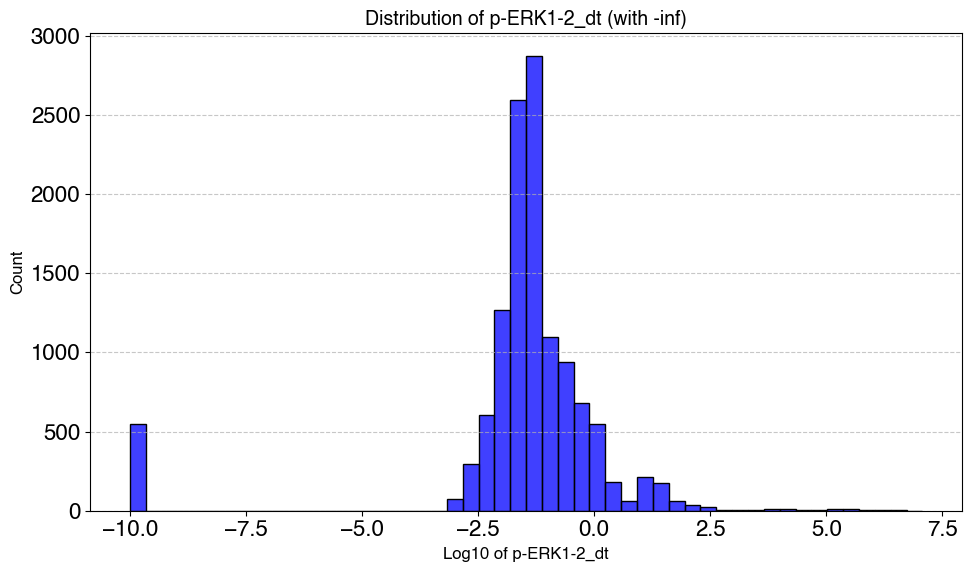

In [11]:
# Replace -inf with a specific label for plotting
log_values = np.log10(data_floored['p-ERK1-2_dt'].abs())
log_values = log_values.replace(-np.inf, -10)  # Replace -inf with a placeholder value (e.g., -10)

plt.figure(figsize=(10, 6))
sns.histplot(log_values, bins=50, kde=False, color='blue')
plt.xlabel('Log10 of p-ERK1-2_dt', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of p-ERK1-2_dt (with -inf)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
def balance_data_by_oom(data, target_col='p-ERK1-2_dt', log10_cutoff=-3, min_samples=500, max_samples=1000):
    """
    Balance data by order-of-magnitude bins of the target column.
    Returns the balanced DataFrame.
    """
    from sklearn.utils import resample

    # Add oom_bins column
    data = data.copy()
    data['oom_bins'] = np.floor(np.log10(data[target_col].abs() + 10**log10_cutoff))

    balanced_data = []
    for oom, group in data.groupby('oom_bins'):
        if len(group) < min_samples:
            balanced_group = resample(group, replace=True, n_samples=min_samples, random_state=42)
        elif len(group) > max_samples:
            balanced_group = resample(group, replace=False, n_samples=max_samples, random_state=42)
        else:
            balanced_group = group
        balanced_data.append(balanced_group)

    balanced_data = pd.concat(balanced_data)
    balanced_data = balanced_data.drop(columns=['oom_bins'])
    balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

    return balanced_data


/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


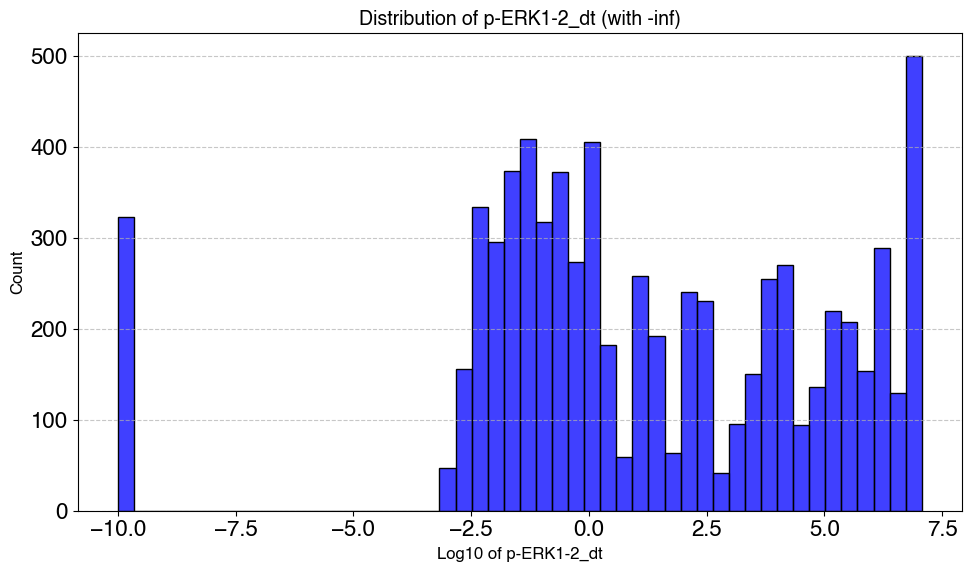

In [13]:
from sklearn.utils import resample

# Combine the data with the oom_bins
data_floored['oom_bins'] = np.floor(np.log10(data['p-ERK1-2_dt'].abs() + 10**log10_cutoff))  # Avoid log10 of zero

# Separate the data into bins
balanced_data = []

# Iterate through each bin and balance the data
for oom, group in data_floored.groupby('oom_bins'):
    if len(group) < 500:  # Oversample if the bin has fewer than 500 samples
        balanced_group = resample(group, replace=True, n_samples=500, random_state=42)
    elif len(group) > 1000:  # Undersample if the bin has more than 1000 samples
        balanced_group = resample(group, replace=False, n_samples=1000, random_state=42)
    else:  # Keep the bin as is if it has a moderate number of samples
        balanced_group = group
    balanced_data.append(balanced_group)

# Combine all the balanced groups
balanced_data = pd.concat(balanced_data)

# Drop the temporary oom_bins column
balanced_data = balanced_data.drop(columns=['oom_bins'])

# Shuffle the data
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

# Display the balanced data distribution
# Plot the distribution of the balanced data
# Replace -inf with a specific label for plotting
log_values = np.log10(balanced_data['p-ERK1-2_dt'].abs())
log_values = log_values.replace(-np.inf, -10)  # Replace -inf with a placeholder value (e.g., -10)

plt.figure(figsize=(10, 6))
sns.histplot(log_values, bins=50, kde=False, color='blue')
plt.xlabel('Log10 of p-ERK1-2_dt', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of p-ERK1-2_dt (with -inf)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

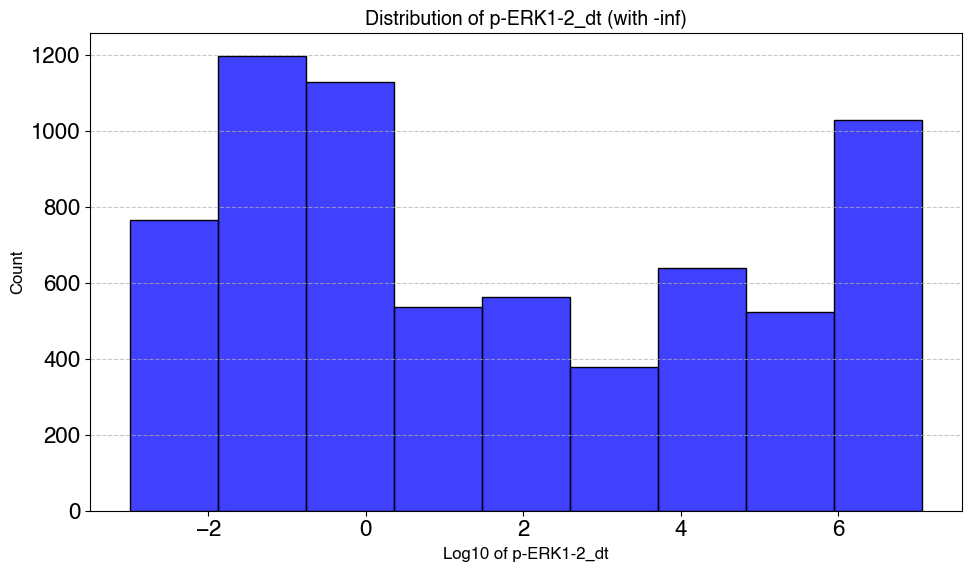

In [14]:
balanced_data = balanced_data[balanced_data['p-ERK1-2_dt'] != 0]

# Display the balanced data distribution
# Plot the distribution of the balanced data
# Replace -inf with a specific label for plotting
log_values = np.log10(balanced_data['p-ERK1-2_dt'].abs())
log_values = log_values.replace(-np.inf, -10)  # Replace -inf with a placeholder value (e.g., -10)

plt.figure(figsize=(10, 6))
sns.histplot(log_values, bins=9, kde=False, color='blue')
plt.xlabel('Log10 of p-ERK1-2_dt', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of p-ERK1-2_dt (with -inf)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
balanced_data.shape

(6753, 15)

In [16]:
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint, uniform  # For distributions
# from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# from sklearn.ensemble import RandomForestRegressor
# X_list = []
# y_list = []

# for marker in unique_markers:
#     X, y = get_X_y(data, marker)
#     X_list.append(X)
#     y_list.append(y)

# # Combine all markers' data into a single X and y
# X = np.vstack(X_list)
# y = np.hstack(y_list)


# # Define parameter distributions (can use lists or distributions)
# param_distributions = {
#     'n_estimators': randint(100, 300),
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': randint(2, 11),
#     'min_samples_leaf': randint(1, 5),
#     'criterion': ['squared_error', 'absolute_error']
# }

# # Create the Random Forest model
# rf = RandomForestRegressor(random_state=42)

# # RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_distributions,
#     n_iter=50,  # Number of combinations to try
#     cv=3,
#     scoring='neg_mean_squared_error',
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )

# # Fit the search
# random_search.fit(X, y)

# # Get results
# print("Best Parameters:", random_search.best_params_)
# print("Best Score:", random_search.best_score_)

In [17]:
# # Initialize a dictionary to store feature importances for each marker
# feature_importances_dict = {}
# metrics_df = pd.DataFrame(columns=["Marker", "R²", "Absolute Error"])

# X_list = []
# y_list = []

# for marker in unique_markers:
#     X, y = get_X_y(data, marker)
#     X_list.append(X)
#     y_list.append(y)

# # Combine all markers' data into a single X and y
# X = np.vstack(X_list)
# y = np.hstack(y_list)

# # Standardize the features
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# # Split the data into training and testing sets
# X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_scaled, y, test_size=0.3)

# # Train a Random Forest Regressor
# rf = RandomForestRegressor(n_estimators=200)#, max_depth=20, min_samples_leaf=4, min_samples_split=10, criterion='absolute_error')
# rf.fit(X_train_rf, y_train_rf)

# # Predict on the test set
# y_pred_rf = rf.predict(X_test_rf)

# # Calculate R² and Mean Absolute Error (MAE)
# r2 = r2_score(y_test_rf, y_pred_rf)
# mae = np.mean(np.square(y_test_rf - y_pred_rf))

# # Record R² and MAE for the current marker
# metrics_df = pd.concat([metrics_df, pd.DataFrame({"Marker": [marker], "R²": [r2], "Absolute Error": [mae]})], ignore_index=True)

# # Get feature importances
# feature_importances = rf.feature_importances_
# feature_importances_dict[marker] = feature_importances

# # Convert the dictionary to a DataFrame for easier plotting
# feature_importances_df = pd.DataFrame(feature_importances_dict, index=X_columns)

In [18]:
# from sklearn.metrics import r2_score

# test_r2 = r2_score(y_test_rf, y_pred_rf)
# print(f"Test R²: {test_r2:.4f}")

# train_r2 = r2_score(y_train_rf, rf.predict(X_train_rf))
# print(f"Train R²: {train_r2:.4f}")

Feature selection

In [19]:
# import pandas as pd
# import numpy as np
# import xgboost as xgb
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error, r2_score
# from scipy.stats.mstats import winsorize

# # === Data Preparation Example ===
# df = balanced_data.dropna().copy()
# df = df.drop(columns=["marker", "timepoint"])

# X_full = df.drop(columns=["p-ERK1-2_dt", "p-MEK1-2_dt"])
# y_raw = df["p-ERK1-2_dt"]
# y_winsor = winsorize(y_raw + 1.0, limits=[0.01, 0.01])
# y_proc = np.array(y_winsor)

# X_train, X_test, y_train, y_test = train_test_split(X_full.values, y_proc, test_size=0.2, random_state=42)

# # === Custom Loss Function ===
# def log_abs_with_sign_penalty_obj(predt, dtrain):
#     y_true = dtrain.get_label()
#     epsilon = 1e-5
#     sign_penalty = 20.0

#     abs_pred = np.abs(predt)
#     abs_true = np.abs(y_true)

#     log_pred = np.log(abs_pred + epsilon)
#     log_true = np.log(abs_true + epsilon)

#     diff = log_pred - log_true
#     grad_base = diff / (abs_pred + epsilon)
#     hess_base = (1 - diff) / (abs_pred + epsilon)**2

#     sign_pred = np.sign(predt)
#     sign_true = np.sign(y_true)
#     sign_mismatch = (sign_pred != sign_true)

#     grad = grad_base + sign_penalty * sign_mismatch * sign_pred
#     hess = hess_base
#     return grad, hess

# # === Training ===
# dtrain = xgb.DMatrix(X_train, label=y_train)
# dtest = xgb.DMatrix(X_test, label=y_test)

# params = {
#     "max_depth": 6,
#     "eta": 0.1,
#     "subsample": 0.8,
#     "colsample_bytree": 0.8,
#     "base_score": np.median(np.log(np.abs(y_train) + 1e-5)),
#     "n_jobs": -1
# }

# final_model = xgb.train(
#     params,
#     dtrain,
#     num_boost_round=300,
#     obj=log_abs_with_sign_penalty_obj,
#     evals=[(dtest, "test")],
#     early_stopping_rounds=20,
#     verbose_eval=20
# )

# # === Evaluation ===
# y_pred = final_model.predict(dtest)
# print("R²:", r2_score(y_test, y_pred))
# print("MAE:", mean_absolute_error(y_test, y_pred))

# # === Feature Importance Extraction ===
# importance_gain = final_model.get_score(importance_type="gain")
# importance_weight = final_model.get_score(importance_type="weight")

# # As DataFrame for easier viewing
# importance_df = pd.DataFrame({
#     "feature": list(importance_gain.keys()),
#     "gain_importance": list(importance_gain.values()),
#     "weight_importance": [importance_weight.get(k, 0) for k in importance_gain.keys()]
# }).sort_values(by="gain_importance", ascending=False)

# print("Feature Importances:")
# print(importance_df)

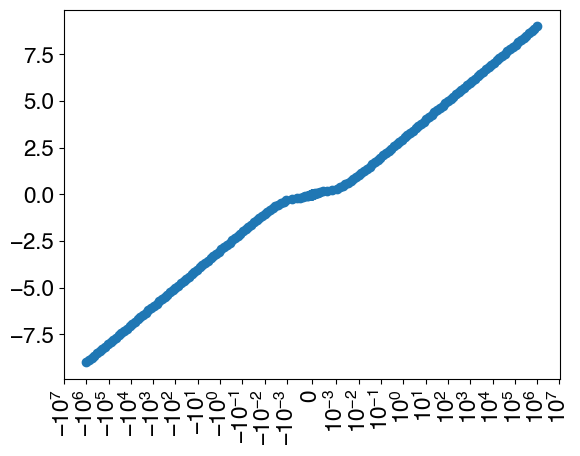

In [20]:
pows = np.linspace(-6, 6, 100)
vals_pos = np.array([10**z for z in pows])
vals_neg = np.array([-10**z for z in pows])
vals = np.concatenate([vals_pos, vals_neg], axis=0)
vals = np.sort(vals)

def signed_log(x, epsilon=log10_cutoff):
    return np.sign(x) * (np.log10(np.abs(x)+10**epsilon) - epsilon)

fvals = signed_log(vals, epsilon=log10_cutoff)

plt.scatter(vals, fvals)
plt.xscale("symlog", linthresh=10**log10_cutoff)
plt.xticks(rotation=90)
plt.show()

[I 2025-08-13 11:47:28,890] A new study created in memory with name: no-name-88b4237d-afb5-4a6d-80b5-bbe73d983f57
[I 2025-08-13 11:47:31,727] Trial 0 finished with value: 0.6616919339352823 and parameters: {'max_depth': 12, 'eta': 0.146483919495772, 'subsample': 0.6900171703971858, 'colsample_bytree': 0.5638332616931465}. Best is trial 0 with value: 0.6616919339352823.
[I 2025-08-13 11:47:34,428] Trial 1 finished with value: 0.6244248384146259 and parameters: {'max_depth': 12, 'eta': 0.12491866972447072, 'subsample': 0.6635473949726731, 'colsample_bytree': 0.6704855034230308}. Best is trial 1 with value: 0.6244248384146259.
[I 2025-08-13 11:47:35,890] Trial 2 finished with value: 0.9786153983368152 and parameters: {'max_depth': 6, 'eta': 0.011413786095195473, 'subsample': 0.5148047315957516, 'colsample_bytree': 0.8016474937473257}. Best is trial 1 with value: 0.6244248384146259.
[I 2025-08-13 11:47:37,213] Trial 3 finished with value: 0.9423971980727623 and parameters: {'max_depth': 5,

Best trial: FrozenTrial(number=24, state=1, values=[0.6019214883293819], datetime_start=datetime.datetime(2025, 8, 13, 11, 48, 27, 562488), datetime_complete=datetime.datetime(2025, 8, 13, 11, 48, 30, 672532), params={'max_depth': 11, 'eta': 0.05952778098585091, 'subsample': 0.9269765282079633, 'colsample_bytree': 0.9588255390287754}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'max_depth': IntDistribution(high=12, log=False, low=3, step=1), 'eta': FloatDistribution(high=0.3, log=True, low=0.01, step=None), 'subsample': FloatDistribution(high=1.0, log=False, low=0.5, step=None), 'colsample_bytree': FloatDistribution(high=1.0, log=False, low=0.5, step=None)}, trial_id=24, value=None)
[0]	test-mae:3.96443
[30]	test-mae:1.07151
[60]	test-mae:0.67686
[90]	test-mae:0.61039
[120]	test-mae:0.59446
[150]	test-mae:0.58560
[180]	test-mae:0.57583
[210]	test-mae:0.56947
[240]	test-mae:0.56728
[270]	test-mae:0.56512
[299]	test-mae:0.56296
R²: 0.9999999874591737
MAE: 54.34

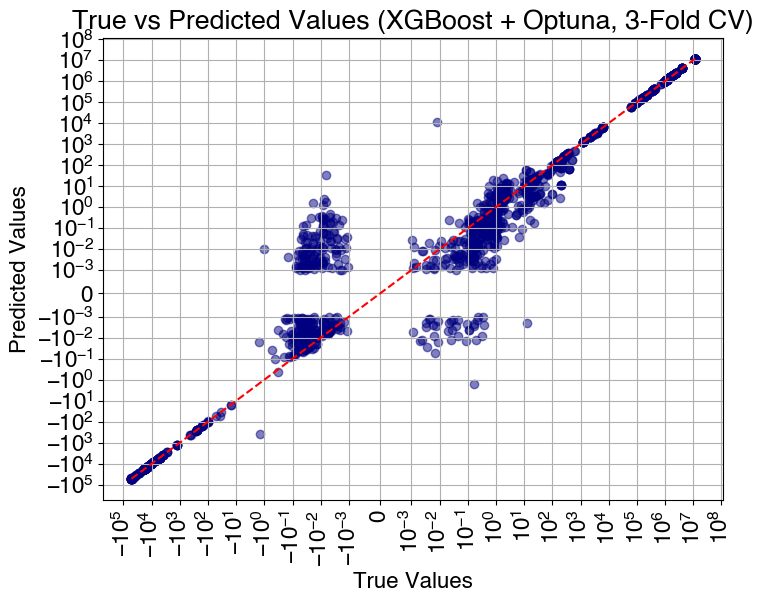

In [21]:
import pandas as pd
import numpy as np
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt

# === Signed Log Transformation ===
def signed_log(x, epsilon=log10_cutoff):
    return np.sign(x) * (np.log10(np.abs(x)) - epsilon)

def inverse_signed_log(z, epsilon=log10_cutoff):
    return np.sign(z) * (10**(np.abs(z) + epsilon))

# === Data Preparation ===
df = balanced_data.dropna().copy()
df = df.drop(columns=["marker", "timepoint", "GFP_bin"])

X_full = df.drop(columns=["p-ERK1-2_dt", "p-MEK1-2_dt"])
y_raw = df["p-ERK1-2_dt"]
y_winsor = winsorize(y_raw, limits=[0.01, 0.01])
y_proc = signed_log(np.array(y_winsor))

X_train, X_test, y_train, y_test = train_test_split(X_full.values, y_proc, test_size=0.2, random_state=42)

def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "eta": trial.suggest_float("eta", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "objective": "reg:absoluteerror",
        "n_jobs": -1
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    mae_scores = []
    
    for train_index, val_index in kf.split(X_train):
        X_tr, X_val = X_train[train_index], X_train[val_index]
        y_tr, y_val = y_train[train_index], y_train[val_index]

        dtrain = xgb.DMatrix(X_tr, label=y_tr)
        dval = xgb.DMatrix(X_val, label=y_val)

        model = xgb.train(
            params,
            dtrain,
            num_boost_round=300,
            evals=[(dval, "validation")],
            early_stopping_rounds=20,
            verbose_eval=False
        )

        y_pred_log = model.predict(dval)
        # y_pred = inverse_signed_log(y_pred_log)
        # y_val_real = inverse_signed_log(y_val)
        mae_scores.append(mean_absolute_error(y_val, y_pred_log))
    
    return np.mean(mae_scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best trial:", study.best_trial)

# Train final model with best params
best_params = {**study.best_trial.params, "objective": "reg:absoluteerror", "random_state": 42, "n_jobs": -1}
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

final_model = xgb.train(
    best_params,
    dtrain,
    num_boost_round=300,
    evals=[(dtest, "test")],
    early_stopping_rounds=30,
    verbose_eval=30
)

# === Evaluation ===
y_pred_log = final_model.predict(dtest)
y_pred = inverse_signed_log(y_pred_log)
y_test_real = inverse_signed_log(y_test)

print("R\u00b2:", r2_score(y_test_real, y_pred))
print("MAE:", mean_absolute_error(y_test_real, y_pred))

print("R\u00b2:", r2_score(y_pred_log, y_test))
print("MAE:", mean_absolute_error(y_pred_log, y_test))

importance_gain = final_model.get_score(importance_type="gain")
importance_weight = final_model.get_score(importance_type="weight")

importance_df = pd.DataFrame({
    "feature": list(importance_gain.keys()),
    "gain_importance": list(importance_gain.values()),
    "weight_importance": [importance_weight.get(k, 0) for k in importance_gain.keys()]
}).sort_values(by="gain_importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_real, y_pred, alpha=0.5, color="navy")
plt.xscale("symlog", linthresh=10**log10_cutoff)
plt.yscale("symlog", linthresh=10**log10_cutoff)
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--')
plt.xlabel("True Values")
plt.xticks(rotation=90)
plt.ylabel("Predicted Values")
plt.grid(True, which='both')
plt.title("True vs Predicted Values (XGBoost + Optuna, 3-Fold CV)")
plt.show()

Optimal number of features: 10
Selected features: ['GFP', 'p-ERK1-2', 'p-MEK1-2', 'p-RAF', 'p-p90RSK', 'p-MAPKAPK2', 'p-PDK1', 'p-MKK3-6', 'p-ERK1-2_min', 'p-MEK1-2_min']
R²: 0.9982820872967977
MAE: 39437.884729301724


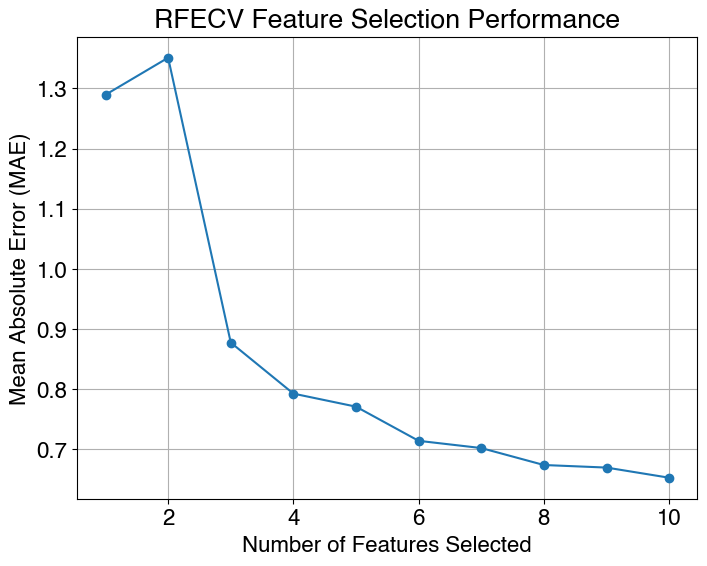

Fitting estimator with 10 features.
Fitting estimator with 10 features.
Fitting estimator with 10 features.
Fitting estimator with 9 features.
Fitting estimator with 9 features.
Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 8 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 7 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.
Fitting estimator with 6 features.
Fitting estimator with 6 features.
Fitting estimator with 5 features.
Fitting estimator with 5 features.
Fitting estimator with 5 features.
Fitting estimator with 4 features.
Fitting estimator with 4 features.
Fitting estimator with 4 features.
Fitting estimator with 3 features.
Fitting estimator with 3 features.
Fitting estimator with 3 features.
Fitting estimator with 2 features.
Fitting estimator with 2 features.
Fitting estimator with 2 features.


In [22]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold
from sklearn.feature_selection import RFECV
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt

# === Data Preparation ===
df = balanced_data.dropna().copy()
df = df.drop(columns=["marker", "timepoint", "GFP_bin"])

X_full = df.drop(columns=["p-ERK1-2_dt", "p-MEK1-2_dt"])
y_raw = df["p-ERK1-2_dt"]
y_winsor = winsorize(y_raw, limits=[0.01, 0.01])
y_proc = signed_log(np.array(y_winsor))

X_train, X_test, y_train, y_test = train_test_split(X_full.values, y_proc, test_size=0.2, random_state=42)

# === RFE with XGBoost ===
model = xgb.XGBRegressor(**best_params)

kf = KFold(n_splits=3, shuffle=True, random_state=42)
rfecv = RFECV(estimator=model, step=1, cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=1)

rfecv.fit(X_train, y_train)

print(f"Optimal number of features: {rfecv.n_features_}")
selected_features_mask = rfecv.support_
selected_features = X_full.columns[selected_features_mask]
print(f"Selected features: {list(selected_features)}")

# === Evaluation ===
final_model = xgb.XGBRegressor(**best_params)

final_model.fit(X_train[:, selected_features_mask], y_train)
y_pred_log = final_model.predict(X_test[:, selected_features_mask])
y_pred = inverse_signed_log(y_pred_log)
y_test_real = inverse_signed_log(y_test)

print("R²:", r2_score(y_test_real, y_pred))
print("MAE:", mean_absolute_error(y_test_real, y_pred))

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1), -rfecv.cv_results_["mean_test_score"], marker="o")
plt.xlabel("Number of Features Selected")
plt.ylabel("Mean Absolute Error (MAE)")
plt.title("RFECV Feature Selection Performance")
plt.grid(True)
plt.show()

In [23]:
# Final selected features
selected_features_mask = rfecv.support_
selected_feature_indices = np.where(selected_features_mask)[0]
selected_feature_names = X_full.columns[selected_features_mask]

# Full ranking
ranking = rfecv.ranking_
ranked_features = pd.DataFrame({
    "feature": X_full.columns,
    "rank": ranking
}).sort_values(by="rank")

print("Selected feature names:", list(selected_feature_names))
print("Feature ranking table:")
print(ranked_features)

Selected feature names: ['GFP', 'p-ERK1-2', 'p-MEK1-2', 'p-RAF', 'p-p90RSK', 'p-MAPKAPK2', 'p-PDK1', 'p-MKK3-6', 'p-ERK1-2_min', 'p-MEK1-2_min']
Feature ranking table:
        feature  rank
0           GFP     1
1      p-ERK1-2     1
2      p-MEK1-2     1
3         p-RAF     1
4      p-p90RSK     1
5    p-MAPKAPK2     1
6        p-PDK1     1
7      p-MKK3-6     1
8  p-ERK1-2_min     1
9  p-MEK1-2_min     1


In [24]:
best_features = selected_feature_names[:7]

In [25]:
# === Data Preparation ===
df = balanced_data.dropna().copy()
df = df.drop(columns=["marker", "timepoint", "GFP_bin"])

X_full = df.drop(columns=["p-ERK1-2_dt", "p-MEK1-2_dt"])
feature_names = X_full.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X_full.values, signed_log(winsorize(df["p-ERK1-2_dt"], limits=[0.01, 0.01])), test_size=0.2, random_state=42)

# === Train Final Model ===
final_model = xgb.XGBRegressor(
    max_depth=12,
    eta=0.0375,
    subsample=0.667,
    colsample_bytree=0.91,
    objective="reg:squarederror",
    n_jobs=-1
)

final_model.fit(X_train, y_train)

# === Evaluation ===
y_pred_log = final_model.predict(X_test)
y_pred = inverse_signed_log(y_pred_log)
y_test_real = inverse_signed_log(y_test)

print("R²:", r2_score(y_test_real, y_pred))
print("MAE:", mean_absolute_error(y_test_real, y_pred))

# === Feature Importance Extraction ===
booster = final_model.get_booster()
importance_gain = booster.get_score(importance_type="gain")
importance_weight = booster.get_score(importance_type="weight")

importance_df = pd.DataFrame({
    "feature": [feature_names[int(k[1:])] for k in importance_gain.keys()],
    "gain_importance": list(importance_gain.values()),
    "weight_importance": [importance_weight.get(k, 0) for k in importance_gain.keys()]
}).sort_values(by="gain_importance", ascending=False)

print("Feature Importances:")
print(importance_df)

R²: 0.8799630287101349
MAE: 331137.1718366364
Feature Importances:
        feature  gain_importance  weight_importance
8  p-ERK1-2_min       149.203873             2164.0
1      p-ERK1-2       108.535957             5020.0
4      p-p90RSK        33.507252             3027.0
3         p-RAF        24.368559             3066.0
7      p-MKK3-6        24.091366             2126.0
5    p-MAPKAPK2        19.543373             2440.0
2      p-MEK1-2        17.071335             3549.0
6        p-PDK1        15.095689             2153.0
9  p-MEK1-2_min        14.948422             1648.0
0           GFP         7.081942             6491.0


In [26]:
# import pandas as pd
# import numpy as np
# import optuna
# from sklearn.model_selection import train_test_split, KFold
# from sklearn.metrics import mean_absolute_error, r2_score
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import RandomForestRegressor
# from scipy.stats.mstats import winsorize
# import matplotlib.pyplot as plt

# # === Data Preparation ===
# df = balanced_data.dropna().copy()
# df = df.drop(columns=["marker", "timepoint"])

# X_full = df.drop(columns=["p-ERK1-2_dt", "p-MEK1-2_dt"])
# y_raw = df["p-ERK1-2_dt"]
# y_winsor = winsorize(y_raw, limits=[0.01, 0.01])  # Shift for log safety
# y_proc = np.array(y_winsor)

# X_scaled = StandardScaler().fit_transform(X_full)
# X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y_proc, test_size=0.2, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# # === Optuna Objective ===
# def objective(trial):
#     kf = KFold(n_splits=3, shuffle=True, random_state=42)
#     mae_scores = []

#     rf_params = {
#         "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
#         "max_depth": trial.suggest_int("max_depth", 3, 20),
#         "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
#         "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
#         "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
#         "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
#         "random_state": 42,
#         "n_jobs": -1
#     }

#     for train_idx, val_idx in kf.split(X_train):
#         X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
#         y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

#         model = RandomForestRegressor(**rf_params)
#         model.fit(X_train_fold, y_train_fold)

#         y_val_pred = model.predict(X_val_fold)
#         mae = mean_absolute_error(y_val_fold, y_val_pred)
#         mae_scores.append(mae)

#     return np.mean(mae_scores)

# # === Run Optuna ===
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=10)

# print("✅ Best Trial:")
# print(study.best_trial)

# # === Final Model Training ===
# best_params = {**study.best_trial.params, "random_state": 42, "n_jobs": -1}

# final_model = RandomForestRegressor(**best_params)
# final_model.fit(X_train, y_train)

# # === Test Set Evaluation ===
# y_pred = final_model.predict(X_test)

# r2 = r2_score(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)

# print("\n🎯 Final Test Set:")
# print(f"R²:  {r2:.4f}")
# print(f"MAE: {mae:.4f}")

# plt.figure(figsize=(8, 6))
# plt.scatter(y_test, y_pred, alpha=0.5, color="navy")
# plt.xscale("symlog", linthresh=1e-5)
# plt.yscale("symlog", linthresh=1e-5)
# plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
# plt.xlabel("True Values")
# plt.ylabel("Predicted Values")
# plt.grid(True, which='both')
# plt.title("True vs Predicted Values (Random Forest)")
# plt.show()

In [27]:
# # Extract feature importances
# feature_importances = final_model.feature_importances_

# # Create a DataFrame for better visualization
# importance_df = pd.DataFrame({
#     'Feature': X_columns,
#     'Importance': feature_importances
# }).sort_values(by='Importance', ascending=False)

# # Print the feature importance
# print(importance_df)

# # Optionally, plot the feature importance
# plt.figure(figsize=(10, 6))
# sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
# plt.title('Feature Importance')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.tight_layout()
# plt.show()

In [28]:
# from sklearn.feature_selection import RFECV
# from sklearn.ensemble import RandomForestRegressor
# import matplotlib.pyplot as plt
# import numpy as np
# from tqdm.auto import tqdm
# import time

# # Final model with fixed best_params from Optuna
# final_model = RandomForestRegressor(**best_params)

# rfecv = RFECV(
#     estimator=final_model,
#     step=1,
#     cv=5,
#     scoring='neg_mean_absolute_error',
#     n_jobs=-1
# )

# print("⏳ Running RFECV...")
# rfecv.fit(X_train, y_train)

# print(f"✅ Optimal number of features: {rfecv.n_features_}")
# selected_features_mask = rfecv.support_

In [29]:
# import matplotlib.pyplot as plt
# import numpy as np

# # === Visualization with cv_results_ ===
# plt.figure(figsize=(8, 6))
# plt.plot(
#     range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
#     -np.array(rfecv.cv_results_['mean_test_score']),
#     marker="o"
# )
# plt.xlabel("Number of Features Selected")
# plt.ylabel("Mean Absolute Error (MAE)")
# plt.title("RFECV Feature Selection Performance")
# plt.grid(True)
# plt.show()

In [30]:
# # Final selected features
# selected_features_mask = rfecv.support_
# selected_feature_indices = np.where(selected_features_mask)[0]
# selected_feature_names = X_full.columns[selected_features_mask]

# # Full ranking
# ranking = rfecv.ranking_
# ranked_features = pd.DataFrame({
#     "feature": X_full.columns,
#     "rank": ranking
# }).sort_values(by="rank")

# print("Selected feature names:", list(selected_feature_names))
# print("Feature ranking table:")
# print(ranked_features)

SR

In [31]:
# Hyperparameters for PySR (Python Symbolic Regression)
N_ITERATIONS = 300  # Total iterations for model training
POPULATION_SIZE = 30  # Symbolic expressions in the population
POPULATIONS = 30  # Number of populations to evolve
MAX_SIZE = 35  # Maximum size of symbolic expressions
# MAX_DEPTH = 5  # Maximum depth of symbolic expressions
PARSIMONY = 0.8  # Regularization to reduce expression complexity
VERBOSITY = 1  # Verbosity level during training
BATCHING = True  # Enable mini-batch training
ANNEALING = True  # Enable annealing to escape local minima
LOG_SPACE_LOSS = f"my_loss(x,y)=(sign(x)*(log10(abs(x)+10^{log10_cutoff})+{abs(log10_cutoff)})-sign(y)*(log10(abs(y)+10^{log10_cutoff})+{abs(log10_cutoff)}))^2"  # Custom log-space loss function

# Operators for Symbolic Regression
BINARY_OPERATORS = ["+", "*", "/", "-"]  # Binary operators for expressions
UNARY_OPERATORS = ["exp", "log"]  # Unary operators for expressions


In [32]:
markers_DUSP = [data for data in unique_markers if str(data).startswith('DUSP')]
markers_receptors = ["EGFR", "ERBB2", "FGFR1", "MET", "TYRO3", "TEC"]
markers_PTPN = [data for data in unique_markers if str(data).startswith('PTPN')]
markers_AKT = ["PIK3R1", "PIP5K3", "AKT3", "PRKACA"]
markers_phosphatases = markers_DUSP + markers_PTPN
markers_untransvected = ["untransfected1", "untransfected2", "untransfected3", "untransfected4"]

my_marker_sets = [markers_phosphatases, markers_receptors, markers_DUSP, markers_PTPN]

markers_choice = markers_DUSP

In [33]:
best_best_features = best_features[:4]

if 'p-ERK1-2_min' not in best_features:
    best_features = list(best_features) + ['p-ERK1-2_min']

if 'GFP' not in best_features:
    best_features = list(best_features) + ['GFP']

best_features 

['GFP',
 'p-ERK1-2',
 'p-MEK1-2',
 'p-RAF',
 'p-p90RSK',
 'p-MAPKAPK2',
 'p-PDK1',
 'p-ERK1-2_min']

In [34]:
features_choice = ['p-ERK1-2', 'p-MEK1-2', 'p-ERK1-2_min', 'GFP']

In [35]:
balanced_data_filtered = balanced_data[(balanced_data['marker'].isin(markers_choice))]

X = balanced_data_filtered.drop(columns=['p-ERK1-2_dt', 'p-MEK1-2_dt', 'marker', 'timepoint', 'GFP_bin'])
y = balanced_data_filtered['p-ERK1-2_dt']

# Remove rows with NaN values in X or y
X = X.dropna()
X = X[features_choice]
y = y[X.index]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

X_train.columns = X_train.columns.str.replace('-', '_')

In [36]:
balanced_data[balanced_data['marker'].isin(markers_choice)].shape

(447, 15)

In [37]:
model = PySRRegressor(
            niterations=N_ITERATIONS,
            population_size=POPULATION_SIZE,
            populations=POPULATIONS,
            binary_operators=BINARY_OPERATORS,
            # unary_operators=UNARY_OPERATORS,
            maxsize=MAX_SIZE,
            parsimony=PARSIMONY,
            verbosity=VERBOSITY,
            batching=BATCHING,
            elementwise_loss=LOG_SPACE_LOSS,
            annealing=ANNEALING,
        )

model.fit(X_train, y_train)

/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
Compiling Julia backend...
[ Info: Started!



Expressions evaluated per second: 1.440e+05
Progress: 4111 / 9000 total iterations (45.678%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           6.396e+00  0.000e+00  y = 0.035204
3           5.549e+00  7.102e-02  y = 0.053234 / p_ERK1_2
5           3.808e+00  1.882e-01  y = (p_ERK1_2_min / p_ERK1_2) + -0.39996
7           3.308e+00  7.037e-02  y = (-0.40062 + (p_ERK1_2_min / p_ERK1_2)) / p_ERK1_2
9           2.977e+00  5.287e-02  y = ((p_ERK1_2_min / p_ERK1_2) + -0.40279) / (p_ERK1_2 * p...
                                      _ERK1_2)
11          2.786e+00  3.301e-02  y = ((p_ERK1_2_min / p_ERK1_2) + -0.41711) / (p_ERK1_2 * (...
                                      p_ERK1_2 * p_ERK1_2))
13          2.588e+00  3.690e-02  y = (((p_ERK1_2_min / p_ERK1_2) + -0.41263) / ((p_ERK1_2 -...

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                        0.035204027   
	1         0.071021                             0.053234473 / p_ERK1_2   
	2         0.188310             (p_ERK1_2_min / p_ERK1_2) + -0.3885138   
	3         0.070282  (-0.40061533 + (p_ERK1_2_min / p_ERK1_2)) / p_...   
	4         0.052869  ((p_ERK1_2_min / p_ERK1_2) + -0.40279374) / (p...   
	5   >>>>  0.070793  ((0.15975791 / ((p_ERK1_2 / p_ERK1_2_min) + -0...   
	6         0.037024  (((0.15975791 / ((p_ERK1_2 / p_ERK1_2_min) + -...   
	7         0.023066  ((((p_ERK1_2_min / p_ERK1_2) + -0.40469354) / ...   
	8         0.009492  ((((p_ERK1_2_min / p_ERK1_2) + -0.40469354) / ...   
	9         0.013911  (((p_ERK1_2_min / ((p_MEK1_2 - p_ERK1_2) * p_E...   
	10        0.021584  ((p_ERK1_2_min + ((p_ERK1_2_min / ((p_MEK1_2 -...   
	11        0.028689  (((p_ERK1_2_min + (p_ERK1_2_min / ((p_MEK1_2 -...   
	12        0.009065  ((((p_ERK1_2_min + (p_ERK1_2_min / ((p_MEK1_2 ...   
	13        0.012346  ((((p_ERK1_2_min + (p_ERK1_2_min / ((p_MEK1_2 ...   
	14        0.007654  (((((p_ERK1_2_min + (p_ERK1_2_min / (p_ERK1_2 ...   
	15        0.006901  (p_ERK1_2_min * (((((p_ERK1_2_min / (p_ERK1_2 ...   
	16        0.003607  (((p_ERK1_2_min * ((((p_ERK1_2_min + -0.927295...   
	17        0.000533  (((((p_ERK1_2_min * ((((p_ERK1_2_min + -0.9272...   
	
	        loss  complexity  
	0   6.396249           1  
	1   5.549291           3  
	2   3.807796           5  
	3   3.308474           7  
	4   2.976502           9  
	5   2.583544          11  
	6   2.399148          13  
	7   2.290986          15  
	8   2.247903          17  
	9   2.186225          19  
	10  2.093859          21  
	11  1.977098          23  
	12  1.941575          25  
	13  1.894222          27  
	14  1.865448          29  
	15  1.839878          31  
	16  1.826653          33  
	17  1.824707          35  
]

  - outputs/20250813_114854_Yy7jQw/hall_of_fame.csv


In [38]:
model.sympy()

(-0.11236485 + 0.15975791/(p_ERK1_2/p_ERK1_2_min - 0.9839862))/p_ERK1_2

In [39]:
from IPython.display import display, Math

for i in range(len(model.equations_)):
    display(Math(f"$$ {model.latex(i)} $$"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [40]:
# === Signed Log Transformation ===
def signed_log(x, epsilon=-3):
    return np.sign(x) * (np.log10(np.abs(x)+10**epsilon) - epsilon)

In [41]:
y_pred_test = model.predict(X_test.values)
y_pred_train = model.predict(X_train)

# Calculate the loss on the test and training sets
test_loss = mean_absolute_error(y_test, y_pred_test)
train_loss = mean_absolute_error(y_train, y_pred_train)

test_loss_log = mean_absolute_error(signed_log(y_test), signed_log(y_pred_test))
train_loss_log = mean_absolute_error(signed_log(y_train), signed_log(y_pred_train))

# Calculate R² on the test and training sets
test_r2 = r2_score(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)

test_r2_log = r2_score(signed_log(y_test), signed_log(y_pred_test))
train_r2_log = r2_score(signed_log(y_train), signed_log(y_pred_train))

print(f"Training set size: {len(y_train)}")
print(f"Test set size: {len(y_test)}")
print()
print(f"Log MAE on Training Set: {train_loss_log:.4f}")
print(f"Log MAE on Test Set: {test_loss_log:.4f}")
print()
print(f"MAE on Training Set: {train_loss:.4f}")
print(f"MAE on Test Set: {test_loss:.4f}")
print()
print(f"R² on Training Set: {train_r2:.4f}")
print(f"R² on Test Set: {test_r2:.4f}")
print()
print(f"Log R² on Training Set: {train_r2_log:.4f}")
print(f"Log R² on Test Set: {test_r2_log:.4f}")

Training set size: 357
Test set size: 90

Log MAE on Training Set: 1.2269
Log MAE on Test Set: 1.3425

MAE on Training Set: 70.5197
MAE on Test Set: 173.1347

R² on Training Set: -0.0536
R² on Test Set: -0.1526

Log R² on Training Set: 0.5961
Log R² on Test Set: 0.6311


Trajectory 1:


,GFP_bin,marker,timepoint,p-ERK1-2,p-MEK1-2,p-ERK1-2_dt,GFP
2446,15.0,DUSP4,15,3.090532,2.623339,-0.046503,1.175532
2447,15.0,DUSP4,30,2.502624,2.126929,-0.032694,1.169782
2462,18.0,DUSP4,0,1.180090,1.401679,1.614130,1.621334
2463,18.0,DUSP4,1,2.378783,3.475514,0.856546,1.621954
2464,18.0,DUSP4,3,3.309400,3.351450,0.199857,1.621954
2465,18.0,DUSP4,5,3.469270,3.230932,-0.000662,1.620221
2466,18.0,DUSP4,10,3.189469,2.961227,-0.073476,1.622279
2467,18.0,DUSP4,15,2.840487,2.731288,-0.064465,1.621541


Predictions for Trajectory 1:
[-7.85111742e-03  4.92569576e-03  6.86690505e+00  1.74213339e-02
 -7.57400252e-03 -8.96495713e-03 -6.24351974e-03 -2.62663938e-04]


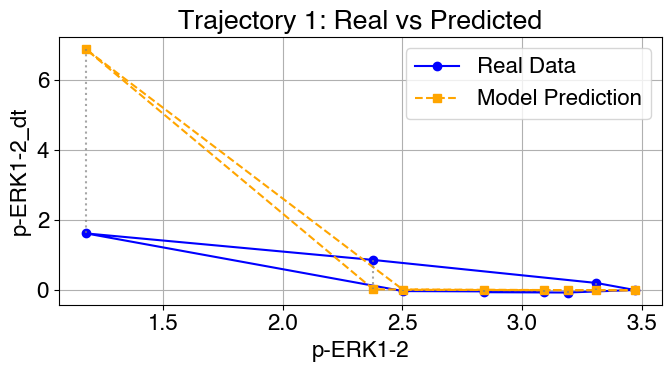

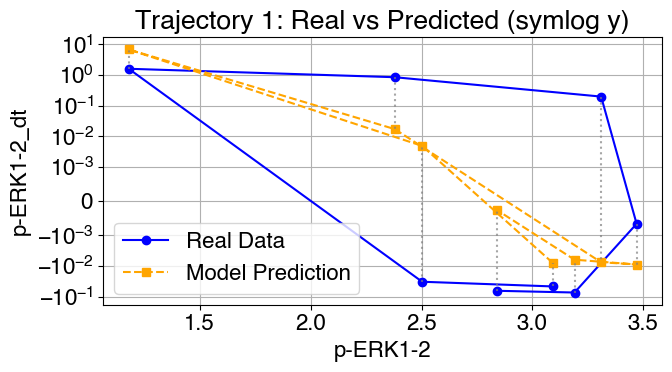

Trajectory 2:


,GFP_bin,marker,timepoint,p-ERK1-2,p-MEK1-2,p-ERK1-2_dt,GFP
1760,24.0,DUSP10 (P2),0,0.707692,1.154683,12.223285,2.512297
1761,24.0,DUSP10 (P2),1,3.180633,3.272856,0.043123,2.500141
1762,24.0,DUSP10 (P2),3,3.090892,3.193120,-0.053965,2.500141
1763,24.0,DUSP10 (P2),5,2.985358,3.116362,-0.051582,2.494985
1764,24.0,DUSP10 (P2),10,2.741517,2.936876,-0.046059,2.505064
1765,24.0,DUSP10 (P2),15,2.523780,2.773812,-0.041128,2.493343
1766,24.0,DUSP10 (P2),30,2.000718,2.368803,-0.029283,2.494685
1767,24.0,DUSP10 (P2),60,1.363154,1.837370,-0.014844,2.500473


Predictions for Trajectory 2:
[ 2.58110989 -0.02214009 -0.02228336 -0.02241193 -0.02246943 -0.02206685
 -0.01684212  0.02709321]


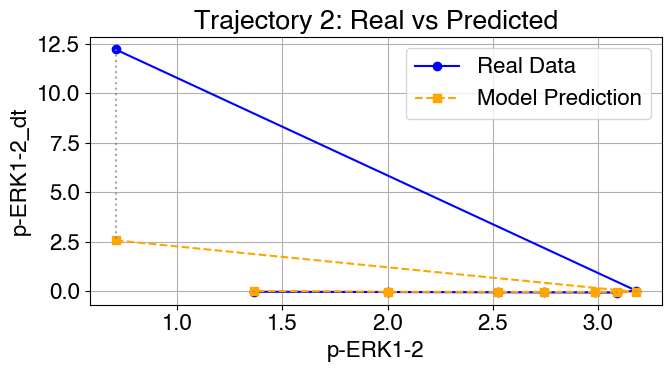

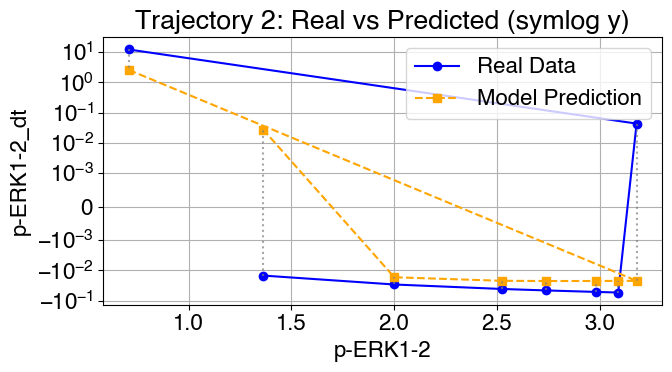

Trajectory 3:


,GFP_bin,marker,timepoint,p-ERK1-2,p-MEK1-2,p-ERK1-2_dt,GFP
1584,2.0,DUSP10 (P2),0,0.701311,1.286038,28.277023,0.127803
1585,2.0,DUSP10 (P2),1,3.864229,4.450128,-0.057135,0.125343
1586,2.0,DUSP10 (P2),3,3.744147,3.764220,-0.059124,0.125343
1587,2.0,DUSP10 (P2),5,3.628168,3.226953,-0.056870,0.125787
1588,2.0,DUSP10 (P2),10,3.357193,2.339672,-0.051605,0.126932
1589,2.0,DUSP10 (P2),15,3.111306,1.858008,-0.046827,0.123881
1590,2.0,DUSP10 (P2),30,2.501998,1.377538,-0.034988,0.124397
1591,2.0,DUSP10 (P2),60,1.706579,1.288380,-0.019533,0.123260


Predictions for Trajectory 3:
[ 1.87937818 -0.02089669 -0.0212413  -0.02157025 -0.02230199 -0.02287046
 -0.02307984 -0.01019444]


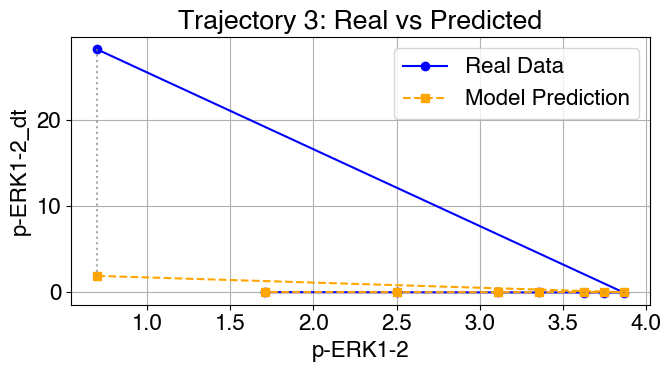

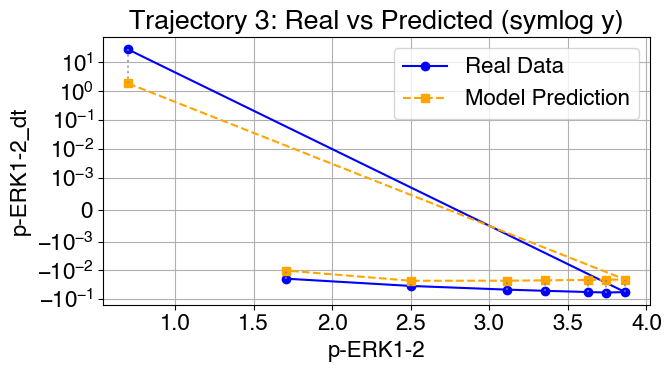

Trajectory 4:


,GFP_bin,marker,timepoint,p-ERK1-2,p-MEK1-2,p-ERK1-2_dt,GFP
2936,33.0,DUSP7,60,1.237681,2.356690,-0.008642,3.490755
2937,34.0,DUSP7,0,0.521154,1.498495,0.799988,3.581916
2938,34.0,DUSP7,1,1.144711,2.070071,0.474527,3.580943
2939,34.0,DUSP7,3,1.727648,2.627645,0.160636,3.580943
2940,34.0,DUSP7,5,1.916361,2.826902,0.047024,3.580159
2941,34.0,DUSP7,10,1.947334,2.903169,-0.011737,3.576423
2942,34.0,DUSP7,15,1.874695,2.871231,-0.015512,3.583453
2943,34.0,DUSP7,30,1.656562,2.752440,-0.013347,3.582724


Predictions for Trajectory 4:
[-7.90810005e-04  1.22199409e+01  1.51687469e-02 -2.58512337e-02
 -2.80408389e-02 -2.82429048e-02 -2.77103445e-02 -2.44301594e-02]


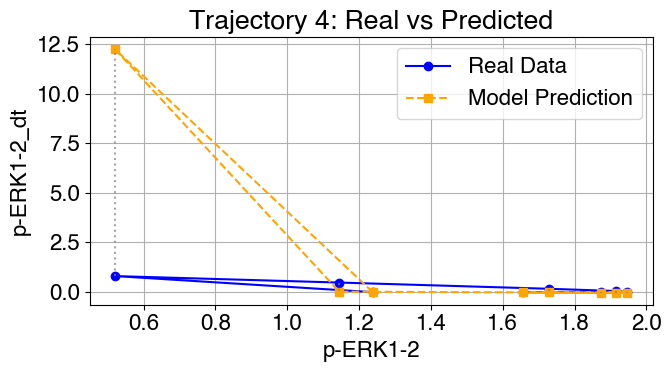

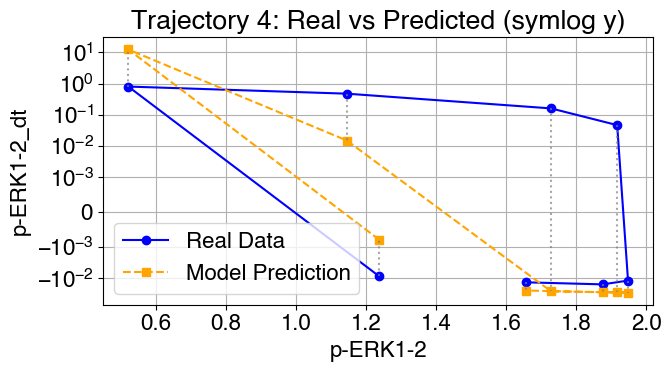

Trajectory 5:


,GFP_bin,marker,timepoint,p-ERK1-2,p-MEK1-2,p-ERK1-2_dt,GFP
1896,41.0,DUSP10 (P2),0,0.702895,1.073251,0.198879,5.369715
1897,41.0,DUSP10 (P2),1,0.872588,2.449411,0.142994,5.371260
1898,41.0,DUSP10 (P2),3,1.076556,3.375516,0.067785,5.371260
1899,41.0,DUSP10 (P2),5,1.164936,3.555093,0.024665,5.370744
1900,41.0,DUSP10 (P2),10,1.161140,3.538855,-0.015664,5.374053
1901,41.0,DUSP10 (P2),15,1.064153,3.468501,-0.020511,5.373193
1902,41.0,DUSP10 (P2),30,0.838454,3.265827,-0.009330,5.369805
1903,41.0,DUSP10 (P2),60,0.719756,2.910430,-0.001174,5.370052


Predictions for Trajectory 5:
[5.9607967  0.51668039 0.15149831 0.09714512 0.09898659 0.16156393
 0.68002609 3.44549811]


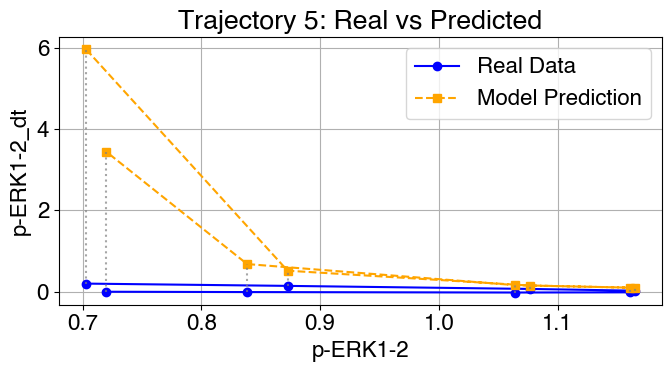

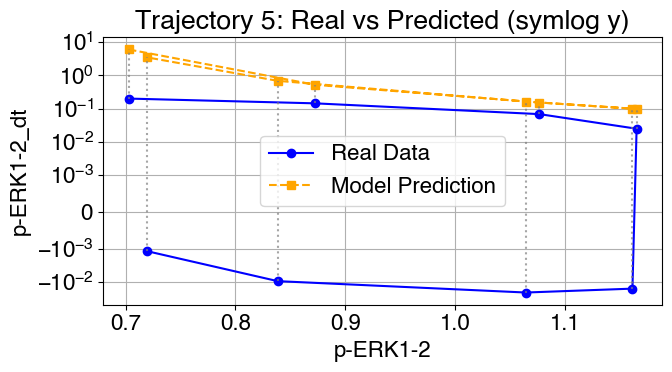

Trajectory 6:


,GFP_bin,marker,timepoint,p-ERK1-2,p-MEK1-2,p-ERK1-2_dt,GFP
2728,7.0,DUSP7,60,1.359156,1.844841,-0.015240,0.486765
2729,8.0,DUSP7,0,0.702019,1.643911,36.865745,0.560127
2730,8.0,DUSP7,1,3.107605,2.681325,-0.041882,0.559747
2731,8.0,DUSP7,3,3.025262,2.645144,-0.040459,0.559747
2732,8.0,DUSP7,5,2.945737,2.602810,-0.039074,0.557906
2733,8.0,DUSP7,10,2.758632,2.504641,-0.035816,0.560725
2734,8.0,DUSP7,15,2.587129,2.416521,-0.032829,0.558901
2735,8.0,DUSP7,30,2.153760,2.202693,-0.025282,0.560058


Predictions for Trajectory 6:
[ 0.04112697  2.71062509 -0.02234854 -0.02246514 -0.02254955 -0.02260153
 -0.02238849 -0.01961006]


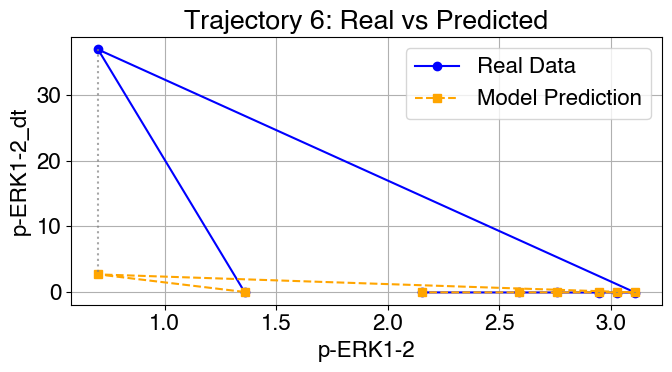

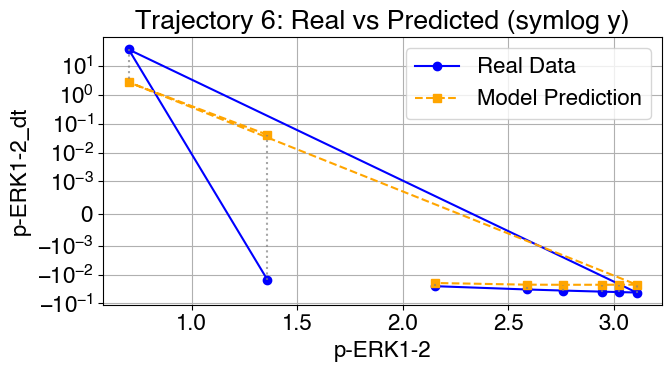

Trajectory 7:


,GFP_bin,marker,timepoint,p-ERK1-2,p-MEK1-2,p-ERK1-2_dt,GFP
2912,30.0,DUSP7,60,1.185723,2.332420,-0.010009,3.184773
2913,31.0,DUSP7,0,0.484748,1.545437,0.610611,3.305599
2914,31.0,DUSP7,1,0.981468,1.998655,0.397541,3.299566
2915,31.0,DUSP7,3,1.511160,2.464225,0.164131,3.299566
2916,31.0,DUSP7,5,1.723925,2.643376,0.062577,3.295329
2917,31.0,DUSP7,10,1.811123,2.720235,-0.005427,3.299274
2918,31.0,DUSP7,15,1.757514,2.690013,-0.013229,3.298077
2919,31.0,DUSP7,30,1.560909,2.571268,-0.012204,3.299575


Predictions for Trajectory 7:
[-9.35572558e-03  2.03885671e+01  4.19296151e-02 -2.48009835e-02
 -2.91522599e-02 -2.99900693e-02 -2.95220735e-02 -2.62125469e-02]


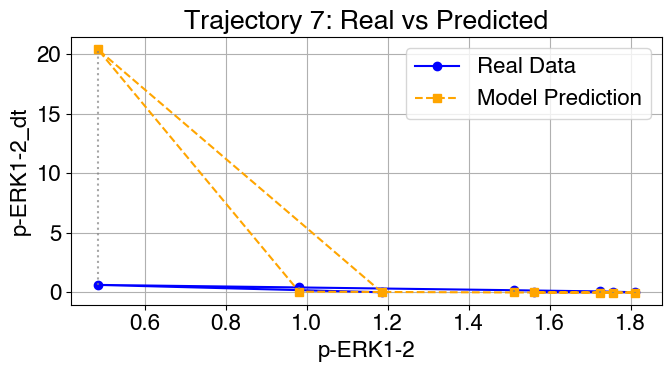

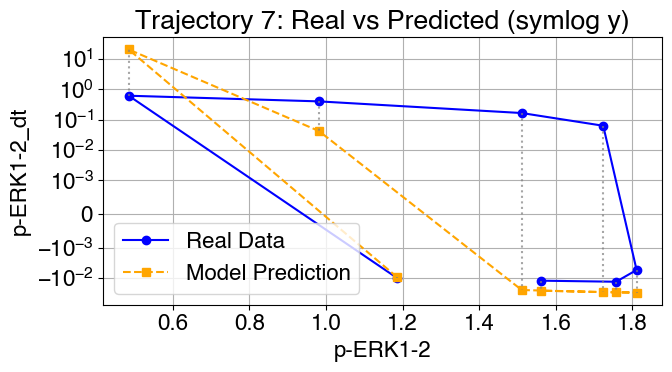

Trajectory 8:


,GFP_bin,marker,timepoint,p-ERK1-2,p-MEK1-2,p-ERK1-2_dt,GFP
2672,0.0,DUSP7,60,1.402685,1.593526,-0.017205,0.006378
2673,1.0,DUSP7,0,0.534074,1.428657,322.580374,0.084392
2674,1.0,DUSP7,1,3.390092,2.670250,-0.057019,0.083788
2675,1.0,DUSP7,3,3.278301,2.615444,-0.054787,0.083788
2676,1.0,DUSP7,5,3.170885,2.562798,-0.052642,0.082887
2677,1.0,DUSP7,10,2.920384,2.441177,-0.047641,0.084091
2678,1.0,DUSP7,15,2.693680,2.332597,-0.043115,0.082262
2679,1.0,DUSP7,30,2.134803,2.071860,-0.031958,0.080871


Predictions for Trajectory 8:
[-0.01662618  3.63938693 -0.02495682 -0.02546777 -0.02596497 -0.02713002
 -0.02814499 -0.02967782]


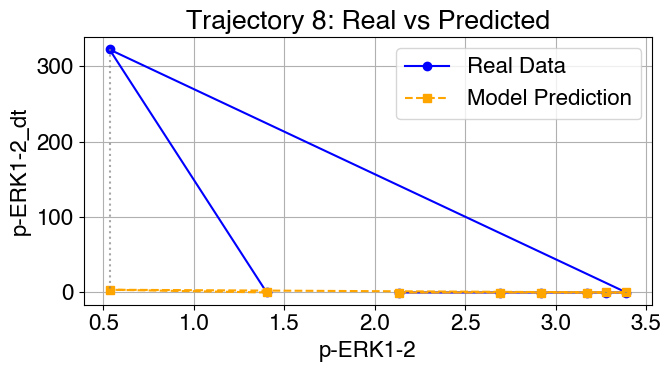

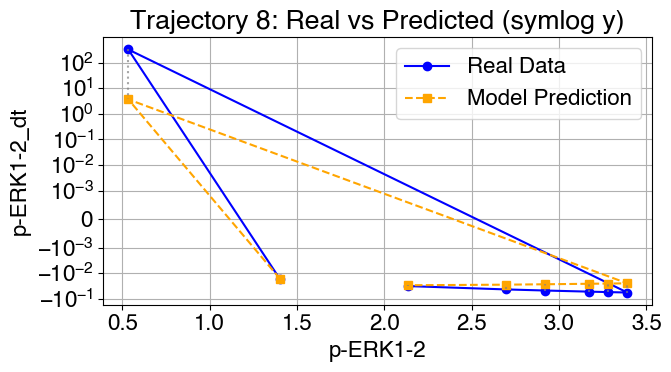

Trajectory 9:


,GFP_bin,marker,timepoint,p-ERK1-2,p-MEK1-2,p-ERK1-2_dt,GFP
1992,5.0,DUSP16,0,0.936902,1.641179,2.268294,0.246550
1993,5.0,DUSP16,1,2.474455,2.845612,0.979079,0.247070
1994,5.0,DUSP16,3,3.390446,2.817649,0.151612,0.247070
1995,5.0,DUSP16,5,3.488972,2.790333,-0.010588,0.247638
1996,5.0,DUSP16,10,3.294652,2.724784,-0.045643,0.244663
1997,5.0,DUSP16,15,3.074780,2.662975,-0.042000,0.248394
1998,5.0,DUSP16,30,2.528997,2.497907,-0.031287,0.248568
1999,5.0,DUSP16,60,1.819848,2.243462,-0.017351,0.246608


Predictions for Trajectory 9:
[ 3.59079145 -0.00822338 -0.0159642  -0.01614743 -0.01572268 -0.01486007
 -0.00926058  0.02461079]


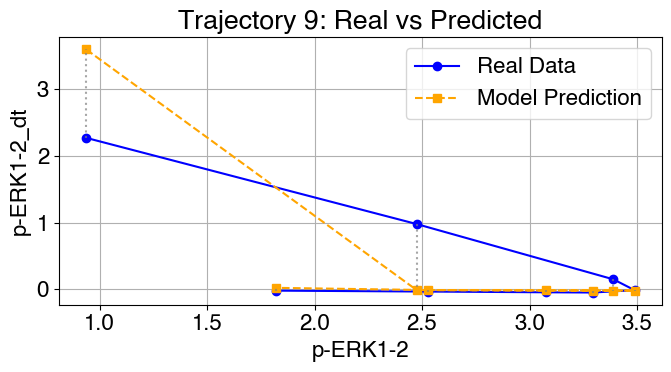

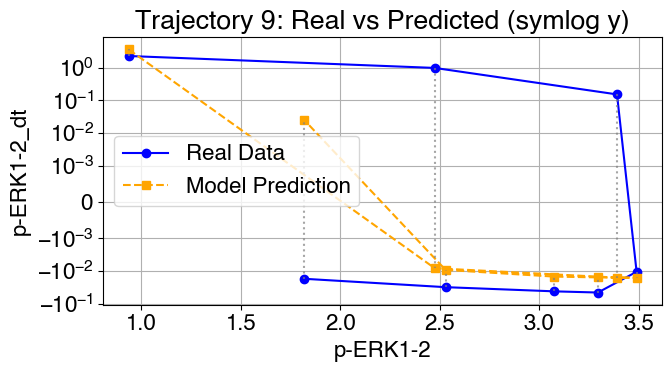

Trajectory 10:


,GFP_bin,marker,timepoint,p-ERK1-2,p-MEK1-2,p-ERK1-2_dt,GFP
1920,44.0,DUSP10 (P2),0,0.681726,0.966935,0.196303,5.673560
1921,44.0,DUSP10 (P2),1,0.848558,2.143939,0.140080,5.672176
1922,44.0,DUSP10 (P2),3,1.048260,3.198553,0.066763,5.672176
1923,44.0,DUSP10 (P2),5,1.137264,3.529853,0.026278,5.668995
1924,44.0,DUSP10 (P2),10,1.152518,3.625393,-0.010545,5.671644
1925,44.0,DUSP10 (P2),15,1.080788,3.564984,-0.015945,5.674882
1926,44.0,DUSP10 (P2),30,0.884593,3.363325,-0.009497,5.670346
1927,44.0,DUSP10 (P2),60,0.731278,3.004594,-0.002330,5.673628


Predictions for Trajectory 10:
[3.80917896 0.46678271 0.13873025 0.08703939 0.08039552 0.11682511
 0.36197003 1.46726931]


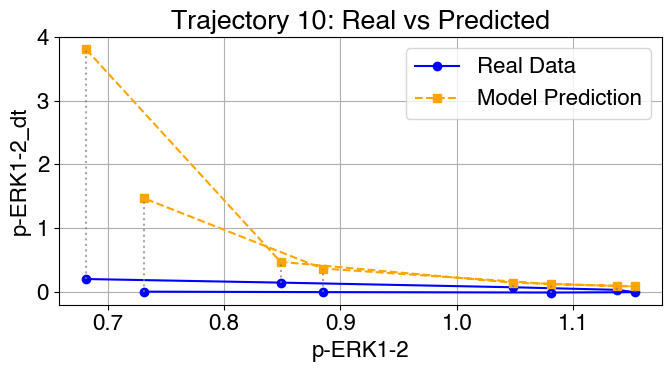

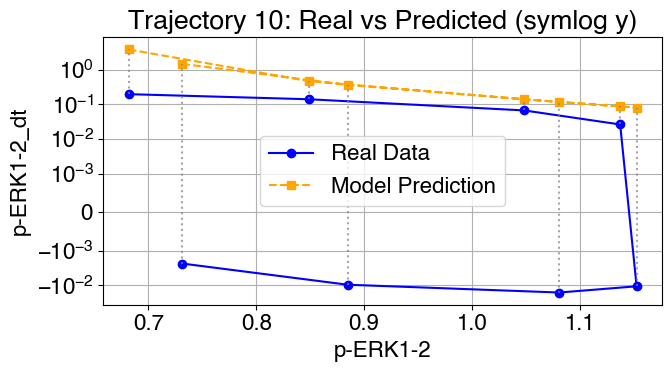

In [42]:
# Randomly select 5 trajectories from DUSP markers only
# np.random.seed(42)  # For reproducibility

# Filter data for DUSP markers
dusp_data = data[data['marker'].isin(markers_choice)].copy()

# Assume each trajectory is a group of 8 consecutive rows as in get_trajectories
all_trajectories = [dusp_data.iloc[i:i+8, :] for i in range(0, len(dusp_data), 8)]
selected_indices = np.random.choice(len(all_trajectories), size=10, replace=False)
selected_trajectories = [all_trajectories[i] for i in selected_indices]

# Display the selected trajectories
for idx, traj in enumerate(selected_trajectories):
    print(f"Trajectory {idx+1}:")
    display(traj[['GFP_bin', 'marker', 'timepoint', 'p-ERK1-2', 'p-MEK1-2', 'p-ERK1-2_dt', 'GFP']])

    # Prepare input features (must match the columns used for model training)
    X_traj = traj[features_choice].copy()
    X_traj.columns = X_traj.columns.str.replace('-', '_')
    # Predict
    y_pred = model.predict(X_traj) # Total number of NaNs
    print(f"Predictions for Trajectory {idx+1}:")
    print(y_pred)

    import matplotlib.pyplot as plt
    erk = traj['p-ERK1-2'].values
    erk_dt = traj['p-ERK1-2_dt'].values

    plt.figure(figsize=(7, 4))
    plt.plot(erk, erk_dt, 'o-', label='Real Data', color='blue')
    plt.plot(erk, y_pred, 's--', label='Model Prediction', color='orange')
    # Draw lines connecting each real and predicted point at the same x
    for x, y_true, y_hat in zip(erk, erk_dt, y_pred):
        plt.plot([x, x], [y_true, y_hat], color='gray', linestyle=':', alpha=0.7)
    plt.xlabel('p-ERK1-2')
    plt.ylabel('p-ERK1-2_dt')
    plt.title(f'Trajectory {idx+1}: Real vs Predicted')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot with symlog y-axis
    plt.figure(figsize=(7, 4))
    plt.plot(erk, erk_dt, 'o-', label='Real Data', color='blue')
    plt.plot(erk, y_pred, 's--', label='Model Prediction', color='orange')
    for x, y_true, y_hat in zip(erk, erk_dt, y_pred):
        plt.plot([x, x], [y_true, y_hat], color='gray', linestyle=':', alpha=0.7)
    plt.xlabel('p-ERK1-2')
    plt.ylabel('p-ERK1-2_dt')
    plt.title(f'Trajectory {idx+1}: Real vs Predicted (symlog y)')
    plt.yscale('symlog', linthresh=1e-3)
    plt.legend()
    plt.grid(True, which='both')
    plt.tight_layout()
    plt.show()


In [43]:
unique_markers

array(['ABL1', 'AKT3', 'ALPK2', 'ARAF', 'DUSP10 (P2)', 'DUSP16', 'DUSP4',
       'DUSP7', 'DYRK2', 'DYRK3', 'EGFR', 'ERBB2', 'FGFR1', 'FLAG-GFP1',
       'FLAG-GFP2', 'FLAG-GFP3', 'FLAG-GFP4', 'MAP2K2', 'MAP4K2', 'MAPK1',
       'MAPK3', 'MAST2', 'MET', 'MST1R', 'PIK3R1', 'PIP5K3', 'PRKACA',
       'PTPN2 (P1)', 'PTPN5', 'PTPN7', 'RPS6KA1', 'RPS6KA3', 'RPS6KA6',
       'TBK1', 'TEC', 'TYRO3', 'untransfected1', 'untransfected2',
       'untransfected3', 'untransfected4'], dtype=object)

In [44]:
marker_groups = [

    # Group 1: Canonical MAPK Cascade – Likely strong proliferation via ERK activation
    ["MAP2K2", "MAPK1", "MAPK3", "RPS6KA1", "RPS6KA3", "RPS6KA6"],

    # Group 2: MAPK Upstream Modulators – More variable but likely moderate activation of MAPK
    ["MAP4K2", "DYRK2", "DYRK3", "ARAF", "TBK1"],

    # Group 3: Phosphatases – Negative regulators, likely to **dampen** MAPK signaling
    ["DUSP4", "DUSP7", "DUSP10 (P2)", "DUSP16", "PTPN5", "PTPN2 (P1)", "PTPN7"],

    # Group 3: DUSP Phosphatases – Negative regulators, likely to **dampen** MAPK signaling
    ["DUSP4", "DUSP7", "DUSP10 (P2)", "DUSP16"],

    # Group 3: PTPN Phosphatases – Negative regulators, likely to **dampen** MAPK signaling
    ["PTPN5", "PTPN2 (P1)", "PTPN7"],

    # Group 4: PI3K/AKT Pathway Activators – Parallel survival/proliferation pathway, similar effects to MAPK but independent
    ["PIK3R1", "AKT3", "PRKACA", "PIP5K3"],

    # Group 5: Receptor Tyrosine Kinases (RTKs) – Upstream of MAPK and PI3K, strong activators when overexpressed
    ["EGFR", "ERBB2", "FGFR1", "MET", "MST1R"],

    # Group 6: Non-RTK Cytoplasmic Tyrosine Kinases – May activate downstream targets but less predictable alone
    ["ABL1", "TEC", "TYRO3"],

    # Group 7: Miscellaneous Kinases – Unclear perturbational output; might affect scaffolding or specific branches
    ["ALPK2", "MAST2"],

    # Group 8: Strong Upstream Activators (RTKs + ARAF) – High perturbational similarity via convergence on Ras-MAPK
    ["EGFR", "ERBB2", "FGFR1", "MET", "MST1R", "ARAF"],

    # Group 9: Feedback Inhibitors – Select phosphatases with known feedback roles
    ["DUSP4", "DUSP10 (P2)", "PTPN2 (P1)"],  # DUSP6 omitted unless added to available marker list

    # Group 10: Controls
    ["FLAG-GFP1", "FLAG-GFP2", "FLAG-GFP3", "FLAG-GFP4"],
    ["untransfected1", "untransfected2", "untransfected3", "untransfected4"]
]

In [45]:
marker_groups_expanded = [

    # === MAPK Core & Modules ===
    ["MAP2K2", "MAPK1", "MAPK3"],  # Core ERK cascade
    ["MAPK1", "MAPK3", "RPS6KA1"],  # MAPK + RSK
    ["MAP2K2", "MAP4K2", "ARAF"],  # MAPK + upstream modulators

    # === RTKs ===
    ["EGFR", "ERBB2", "FGFR1"],
    ["MET", "MST1R", "FGFR1"],
    ["EGFR", "ERBB2", "MET", "MST1R", "FGFR1"],

    # === PI3K/AKT pathway ===
    ["AKT3", "PIK3R1", "PIP5K3", "PRKACA"],
    ["AKT3", "PRKACA", "PIP5K3"],

    # === Phosphatases ===
    ["DUSP4", "DUSP7", "DUSP10 (P2)", "DUSP16"],
    ["PTPN2 (P1)", "PTPN5", "PTPN7"],
    ["DUSP4", "PTPN2 (P1)", "DUSP10 (P2)"],

    # === Non-RTK Tyrosine Kinases ===
    ["ABL1", "TEC", "TYRO3"],

    # === DYRK & MAP4K Modules ===
    ["DYRK2", "DYRK3", "MAP4K2"],

    # === RSK Feedback ===
    ["RPS6KA1", "RPS6KA3", "RPS6KA6"],

    # === Scaffolding / less-annotated kinases ===
    ["MAST2", "ALPK2", "ARAF"],
    ["TEC", "MAST2", "ALPK2"],

    # === Immune/Stress-Linked Kinases ===
    ["TBK1", "MAP4K2", "DYRK2"],

    # === Feedback inhibition + core pathway ===
    ["MAPK1", "DUSP4", "PTPN2 (P1)"],
    ["MAPK3", "DUSP10 (P2)", "PTPN7"], # remove

    # === Mixed positive and negative regulators ===
    ["EGFR", "AKT3", "DUSP4"],
    ["ERBB2", "PRKACA", "PTPN2 (P1)"],

    # === Mixed scaffolds and kinases ===
    ["MAST2", "ARAF", "RPS6KA1"],
    ["TYRO3", "MAPK3", "ALPK2"],

    # === Control groups ===
    ["FLAG-GFP1", "FLAG-GFP2", "FLAG-GFP3", "FLAG-GFP4"],
    ["untransfected1", "untransfected2", "untransfected3", "untransfected4"],

    # === Combo groups (RTK + PI3K) ===
    ["EGFR", "ERBB2", "AKT3", "PRKACA"],
    ["MET", "MST1R", "PIK3R1", "PIP5K3"],

    # === Combo groups (RTK + Phosphatases) ===
    ["EGFR", "ERBB2", "PTPN2 (P1)", "DUSP4"],
    ["MET", "FGFR1", "DUSP10 (P2)", "PTPN5"],

    # === Combo groups (MAPK core + PI3K) ===
    ["MAP2K2", "MAPK3", "AKT3", "PIP5K3"],
    ["MAPK1", "MAPK3", "PRKACA", "PIK3R1"],

    # === Combo groups (feedback + stress) ===
    ["DUSP4", "DUSP16", "DYRK2", "MAP4K2"],

    # === Fill remaining underused protein coverage ===
    ["ABL1", "PRKACA", "RPS6KA3"],
    ["TBK1", "PIP5K3", "DUSP7"],
    ["TYRO3", "MAST2", "PIP5K3"],

]

In [46]:
features_choice = best_features #['p-ERK1-2', 'p-MEK1-2', 'p-ERK1-2_min', 'GFP']

In [47]:
results_by_strategy = {}

In [48]:
from IPython.display import display, Math

results_by_group = {}
for markers_choice in marker_groups:
    print(f"Processing markers: {markers_choice}")
        
    
        # Filter the balanced data for the selected markers
    balanced_data_filtered = balanced_data[(balanced_data['marker'].isin(markers_choice))]

    X = balanced_data_filtered.drop(columns=['p-ERK1-2_dt', 'p-MEK1-2_dt', 'marker', 'timepoint', 'GFP_bin'])
    y = balanced_data_filtered['p-ERK1-2_dt']

    # Remove rows with NaN values in X or y
    X = X.dropna()
    X = X[features_choice]
    y = y[X.index]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    X_train.columns = X_train.columns.str.replace('-', '_')

    model = PySRRegressor(
                niterations=N_ITERATIONS,
                population_size=POPULATION_SIZE,
                populations=POPULATIONS,
                binary_operators=BINARY_OPERATORS,
                # unary_operators=UNARY_OPERATORS,
                maxsize=MAX_SIZE,
                # maxdepth=MAX_DEPTH,
                parsimony=PARSIMONY,
                verbosity=0,
                batching=BATCHING,
                elementwise_loss=LOG_SPACE_LOSS,
                annealing=ANNEALING,
            )

    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test.values)
    y_pred_train = model.predict(X_train)

    # Calculate the loss on the test and training sets
    rel_mae_train = np.mean(np.abs((y_train - y_pred_train) / (np.abs(y_train) + 1e-8)))
    rel_mae_test = np.mean(np.abs((y_test - y_pred_test) / (np.abs(y_test) + 1e-8)))

    test_loss_log = mean_absolute_error(signed_log(y_test), signed_log(y_pred_test))
    train_loss_log = mean_absolute_error(signed_log(y_train), signed_log(y_pred_train))

    # Calculate R² on the test and training sets
    test_r2 = r2_score(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)

    test_r2_log = r2_score(signed_log(y_test), signed_log(y_pred_test))
    train_r2_log = r2_score(signed_log(y_train), signed_log(y_pred_train))

    # Store only metrics and marker group in a dict (one entry for this run)
    results = {
        'markers_choice': markers_choice,
        'train_loss_log': train_loss_log,
        'test_loss_log': test_loss_log,
        'rel_mae_train': rel_mae_train,
        'rel_mae_test': rel_mae_test,
        'train_r2_log': train_r2_log,
        'test_r2_log': test_r2_log,
        'train_r2': train_r2,
        'test_r2': test_r2,
    }

    results_by_group[str(markers_choice)] = results

    print(f"Training set size: {len(y_train)}")
    print(f"Test set size: {len(y_test)}")
    print()
    print("Best model equation:")
    display(Math(f"$$ {model.latex()} $$"))
    print()
    print(f"Log MAE on Training Set: {train_loss_log:.4f}")
    print(f"Log MAE on Test Set: {test_loss_log:.4f}")
    print()
    print(f"Relative MAE on Training Set: {rel_mae_train:.4f}")
    print(f"Relative MAE on Test Set: {rel_mae_test:.4f}")
    print()
    print(f"Log R² on Training Set: {train_r2_log:.4f}")
    print(f"Log R² on Test Set: {test_r2_log:.4f}")
    print()
    print(f"Linear R² on Training Set: {train_r2:.4f}")
    print(f"Linear R² on Test Set: {test_r2:.4f}")
    print()

results_by_strategy["best_features"] = results_by_group

Processing markers: ['MAP2K2', 'MAPK1', 'MAPK3', 'RPS6KA1', 'RPS6KA3', 'RPS6KA6']


/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Training set size: 630
Test set size: 158

Best model equation:


<IPython.core.display.Math object>


Log MAE on Training Set: 1.3843
Log MAE on Test Set: 1.4960

Relative MAE on Training Set: 5.8507
Relative MAE on Test Set: 8.6938

Log R² on Training Set: 0.3894
Log R² on Test Set: 0.3507

Linear R² on Training Set: -0.1571
Linear R² on Test Set: -0.2201

Processing markers: ['MAP4K2', 'DYRK2', 'DYRK3', 'ARAF', 'TBK1']


...


Log MAE on Training Set: 1.2011
Log MAE on Test Set: 1.3225

Relative MAE on Training Set: 2.2667
Relative MAE on Test Set: 1.5724

Log R² on Training Set: 0.4744
Log R² on Test Set: 0.5318

Linear R² on Training Set: -0.0147
Linear R² on Test Set: -0.0452

Processing markers: ['untransfected1', 'untransfected2', 'untransfected3', 'untransfected4']


/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Training set size: 314
Test set size: 79

Best model equation:


<IPython.core.display.Math object>


Log MAE on Training Set: 0.6804
Log MAE on Test Set: 0.7199

Relative MAE on Training Set: 6.0652
Relative MAE on Test Set: 4.4413

Log R² on Training Set: 0.8816
Log R² on Test Set: 0.8865

Linear R² on Training Set: -0.0813
Linear R² on Test Set: -0.1377



/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_58910/764559987.py:38: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


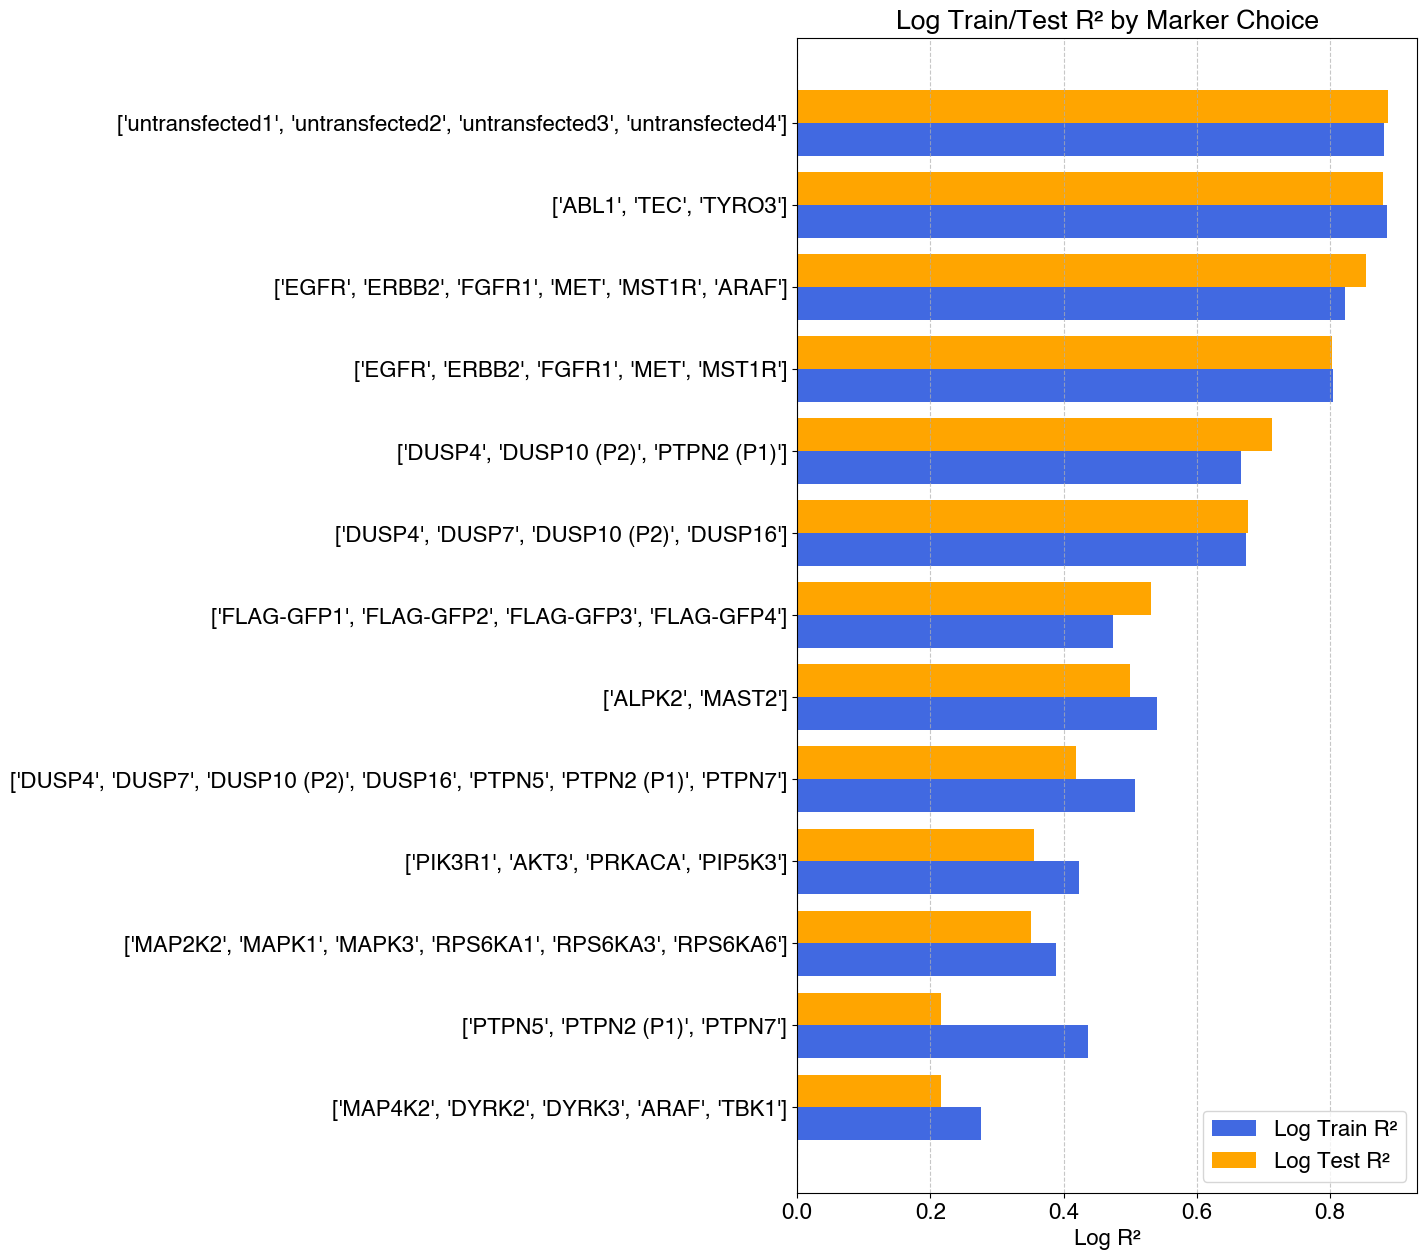

In [49]:
import numpy as np

import matplotlib.pyplot as plt

# Collect marker group names and their log R² metrics from results_by_group
marker_group_names = []
train_r2_log_list = []
test_r2_log_list = []

for group, res in results_by_strategy["best_features"].items():
    marker_group_names.append(str(group))
    train_r2_log_list.append(res['train_r2_log'])
    test_r2_log_list.append(res['test_r2_log'])

# Convert to numpy arrays for sorting
train_r2_log_arr = np.array(train_r2_log_list)
test_r2_log_arr = np.array(test_r2_log_list)
marker_group_names = np.array(marker_group_names)

# Sort by test_r2_log descending
sort_idx = np.argsort(test_r2_log_arr)
marker_group_names_sorted = marker_group_names[sort_idx]
train_r2_log_sorted = train_r2_log_arr[sort_idx]
test_r2_log_sorted = test_r2_log_arr[sort_idx]

# Horizontal bar plot (flipped axes)
plt.figure(figsize=(max(8, len(marker_group_names_sorted) * 0.5), 15))
bar_height = 0.4
y = np.arange(len(marker_group_names_sorted))

plt.barh(y - bar_height/2, train_r2_log_sorted, height=bar_height, label='Log Train R²', color='royalblue')
plt.barh(y + bar_height/2, test_r2_log_sorted, height=bar_height, label='Log Test R²', color='orange')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.yticks(y, marker_group_names_sorted)
plt.xlabel('Log R²')
plt.title('Log Train/Test R² by Marker Choice')
plt.legend()
plt.tight_layout()
plt.show()

In [50]:
from IPython.display import display, Math

features_choice = best_features #['p-ERK1-2', 'p-MEK1-2', 'p-ERK1-2_min', 'GFP']

results_by_group = {}
for markers_choice in marker_groups_expanded:
    print(f"Processing markers: {markers_choice}")
        
    
        # Filter the balanced data for the selected markers
    balanced_data_filtered = balanced_data[(balanced_data['marker'].isin(markers_choice))]

    X = balanced_data_filtered.drop(columns=['p-ERK1-2_dt', 'p-MEK1-2_dt', 'marker', 'timepoint', 'GFP_bin'])
    y = balanced_data_filtered['p-ERK1-2_dt']

    # Remove rows with NaN values in X or y
    X = X.dropna()
    X = X[features_choice]
    y = y[X.index]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    X_train.columns = X_train.columns.str.replace('-', '_')

    model = PySRRegressor(
                niterations=N_ITERATIONS,
                population_size=POPULATION_SIZE,
                populations=POPULATIONS,
                binary_operators=BINARY_OPERATORS,
                # unary_operators=UNARY_OPERATORS,
                maxsize=MAX_SIZE,
                # maxdepth=MAX_DEPTH,
                parsimony=PARSIMONY,
                verbosity=0,
                batching=BATCHING,
                elementwise_loss=LOG_SPACE_LOSS,
                annealing=ANNEALING,
            )

    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test.values)
    y_pred_train = model.predict(X_train)

    # Calculate the loss on the test and training sets
    rel_mae_train = np.mean(np.abs((y_train - y_pred_train) / (np.abs(y_train) + 1e-8)))
    rel_mae_test = np.mean(np.abs((y_test - y_pred_test) / (np.abs(y_test) + 1e-8)))

    test_loss_log = mean_absolute_error(signed_log(y_test), signed_log(y_pred_test))
    train_loss_log = mean_absolute_error(signed_log(y_train), signed_log(y_pred_train))

    # Calculate R² on the test and training sets
    test_r2 = r2_score(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)

    test_r2_log = r2_score(signed_log(y_test), signed_log(y_pred_test))
    train_r2_log = r2_score(signed_log(y_train), signed_log(y_pred_train))

    # Store only metrics and marker group in a dict (one entry for this run)
    results = {
        'markers_choice': markers_choice,
        'train_loss_log': train_loss_log,
        'test_loss_log': test_loss_log,
        'rel_mae_train': rel_mae_train,
        'rel_mae_test': rel_mae_test,
        'train_r2_log': train_r2_log,
        'test_r2_log': test_r2_log,
        'train_r2': train_r2,
        'test_r2': test_r2,
    }

    results_by_group[str(markers_choice)] = results

    print(f"Training set size: {len(y_train)}")
    print(f"Test set size: {len(y_test)}")
    print()
    print("Best model equation:")
    display(Math(f"$$ {model.latex()} $$"))
    print()
    print(f"Log MAE on Training Set: {train_loss_log:.4f}")
    print(f"Log MAE on Test Set: {test_loss_log:.4f}")
    print()
    print(f"Relative MAE on Training Set: {rel_mae_train:.4f}")
    print(f"Relative MAE on Test Set: {rel_mae_test:.4f}")
    print()
    print(f"Log R² on Training Set: {train_r2_log:.4f}")
    print(f"Log R² on Test Set: {test_r2_log:.4f}")
    print()
    print(f"Linear R² on Training Set: {train_r2:.4f}")
    print(f"Linear R² on Test Set: {test_r2:.4f}")
    print()
    print()

results_by_strategy["best_features_expanded"] = results_by_group



Processing markers: ['MAP2K2', 'MAPK1', 'MAPK3']


/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Training set size: 317
Test set size: 80

Best model equation:


<IPython.core.display.Math object>


Log MAE on Training Set: 1.0504
Log MAE on Test Set: 1.2076

Relative MAE on Training Set: 3.2779
Relative MAE on Test Set: 3.9056

Log R² on Training Set: 0.6311
Log R² on Test Set: 0.5078

Linear R² on Training Set: -0.1329
Linear R² on Test Set: -0.1008


Processing markers: ['MAPK1', 'MAPK3', 'RPS6KA1']


...


Log MAE on Training Set: 1.0861
Log MAE on Test Set: 1.2880

Relative MAE on Training Set: 9.7410
Relative MAE on Test Set: 16.5413

Log R² on Training Set: 0.6975
Log R² on Test Set: 0.5078

Linear R² on Training Set: -0.2792
Linear R² on Test Set: -0.6500


Processing markers: ['TYRO3', 'MAST2', 'PIP5K3']


/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Training set size: 344
Test set size: 87

Best model equation:


<IPython.core.display.Math object>


Log MAE on Training Set: 1.7127
Log MAE on Test Set: 2.0823

Relative MAE on Training Set: 79.2202
Relative MAE on Test Set: 38.4646

Log R² on Training Set: 0.4877
Log R² on Test Set: 0.2411

Linear R² on Training Set: -0.2237
Linear R² on Test Set: -0.1980




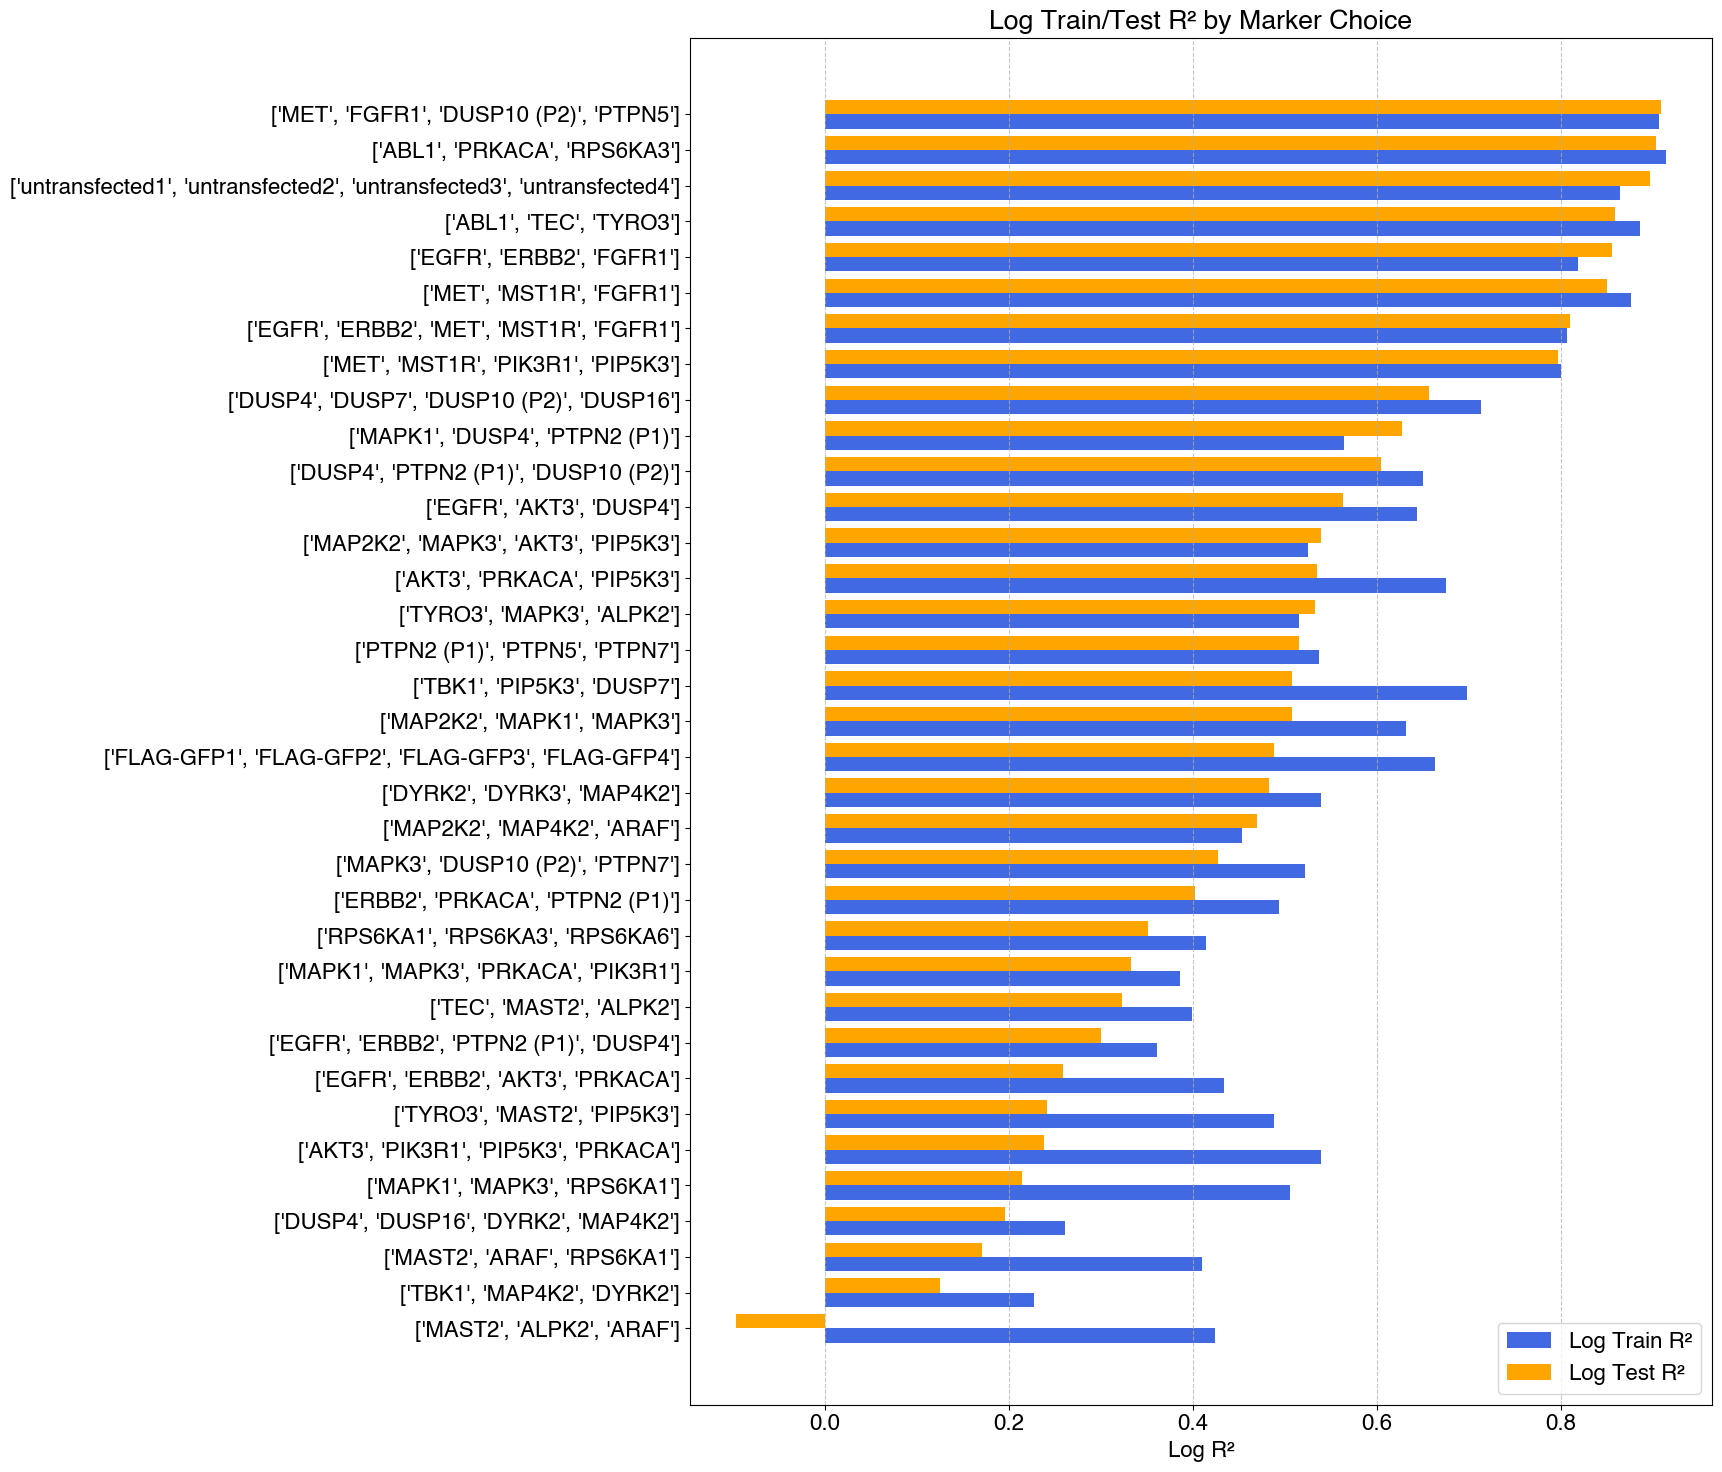

In [51]:
import numpy as np

import matplotlib.pyplot as plt

# Collect marker group names and their log R² metrics from results_by_group
marker_group_names = []
train_r2_log_list = []
test_r2_log_list = []

for group, res in results_by_group.items():
    marker_group_names.append(str(group))
    train_r2_log_list.append(res['train_r2_log'])
    test_r2_log_list.append(res['test_r2_log'])

# Convert to numpy arrays for sorting
train_r2_log_arr = np.array(train_r2_log_list)
test_r2_log_arr = np.array(test_r2_log_list)
marker_group_names = np.array(marker_group_names)

# Sort by test_r2_log descending
sort_idx = np.argsort(test_r2_log_arr)
marker_group_names_sorted = marker_group_names[sort_idx]
train_r2_log_sorted = train_r2_log_arr[sort_idx]
test_r2_log_sorted = test_r2_log_arr[sort_idx]

# Horizontal bar plot (flipped axes)
plt.figure(figsize=(max(8, len(marker_group_names_sorted) * 0.5), 15))
bar_height = 0.4
y = np.arange(len(marker_group_names_sorted))

plt.barh(y - bar_height/2, train_r2_log_sorted, height=bar_height, label='Log Train R²', color='royalblue')
plt.barh(y + bar_height/2, test_r2_log_sorted, height=bar_height, label='Log Test R²', color='orange')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.yticks(y, marker_group_names_sorted)
plt.xlabel('Log R²')
plt.title('Log Train/Test R² by Marker Choice')
plt.legend()
plt.tight_layout()
plt.show()

marker_groups_expanded = [

    # === MAPK Core & Modules ===
    ["MAP2K2", "MAPK1", "MAPK3"],  # Core ERK cascade
    ["MAPK1", "MAPK3", "RPS6KA1"],  # MAPK + RSK
    ["MAP2K2", "MAP4K2", "ARAF"],  # MAPK + upstream modulators

    # === RTKs ===
    ["EGFR", "ERBB2", "FGFR1"],
    ["MET", "MST1R", "FGFR1"],
    ["EGFR", "ERBB2", "MET", "MST1R", "FGFR1"],

    # === PI3K/AKT pathway ===
    ["AKT3", "PIK3R1", "PIP5K3", "PRKACA"],
    ["AKT3", "PRKACA", "PIP5K3"],

    # === Phosphatases ===
    ["DUSP4", "DUSP7", "DUSP10 (P2)", "DUSP16"],
    ["PTPN2 (P1)", "PTPN5", "PTPN7"],
    ["DUSP4", "PTPN2 (P1)", "DUSP10 (P2)"],

    # === Non-RTK Tyrosine Kinases ===
    ["ABL1", "TEC", "TYRO3"],

    # === DYRK & MAP4K Modules ===
    ["DYRK2", "DYRK3", "MAP4K2"],

    # === RSK Feedback ===
    ["RPS6KA1", "RPS6KA3", "RPS6KA6"],

    # === Scaffolding / less-annotated kinases ===
    ["MAST2", "ALPK2", "ARAF"],
    ["TEC", "MAST2", "ALPK2"],

    # === Immune/Stress-Linked Kinases ===
    ["TBK1", "MAP4K2", "DYRK2"],

    # === Feedback inhibition + core pathway ===
    ["MAPK1", "DUSP4", "PTPN2 (P1)"],
    ["MAPK3", "DUSP10 (P2)", "PTPN7"],

    # === Mixed positive and negative regulators ===
    ["EGFR", "AKT3", "DUSP4"],
    ["ERBB2", "PRKACA", "PTPN2 (P1)"],

    # === Mixed scaffolds and kinases ===
    ["MAST2", "ARAF", "RPS6KA1"],
    ["TYRO3", "MAPK3", "ALPK2"],

    # === Control groups ===
    ["FLAG-GFP1", "FLAG-GFP2", "FLAG-GFP3", "FLAG-GFP4"],
    ["untransfected1", "untransfected2", "untransfected3", "untransfected4"],

    # === Combo groups (RTK + PI3K) ===
    ["EGFR", "ERBB2", "AKT3", "PRKACA"],
    ["MET", "MST1R", "PIK3R1", "PIP5K3"],

    # === Combo groups (RTK + Phosphatases) ===
    ["EGFR", "ERBB2", "PTPN2 (P1)", "DUSP4"],
    ["MET", "FGFR1", "DUSP10 (P2)", "PTPN5"],

    # === Combo groups (MAPK core + PI3K) ===
    ["MAP2K2", "MAPK3", "AKT3", "PIP5K3"],
    ["MAPK1", "MAPK3", "PRKACA", "PIK3R1"],

    # === Combo groups (feedback + stress) ===
    ["DUSP4", "DUSP16", "DYRK2", "MAP4K2"],

    # === Fill remaining underused protein coverage ===
    ["ABL1", "PRKACA", "RPS6KA3"],
    ["TBK1", "PIP5K3", "DUSP7"],
    ["TYRO3", "MAST2", "PIP5K3"],

]

In [52]:
features_choice = ['p-ERK1-2', 'p-MEK1-2', 'p-ERK1-2_min', 'GFP']

In [53]:
from IPython.display import display, Math




results_by_group = {}
for markers_choice in marker_groups:
    print(f"Processing markers: {markers_choice}")
        
    
        # Filter the balanced data for the selected markers
    balanced_data_filtered = balanced_data[(balanced_data['marker'].isin(markers_choice))]

    X = balanced_data_filtered.drop(columns=['p-ERK1-2_dt', 'p-MEK1-2_dt', 'marker', 'timepoint', 'GFP_bin'])
    y = balanced_data_filtered['p-ERK1-2_dt']

    # Remove rows with NaN values in X or y
    X = X.dropna()
    X = X[features_choice]
    y = y[X.index]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    X_train.columns = X_train.columns.str.replace('-', '_')

    model = PySRRegressor(
                niterations=N_ITERATIONS,
                population_size=POPULATION_SIZE,
                populations=POPULATIONS,
                binary_operators=BINARY_OPERATORS,
                # unary_operators=UNARY_OPERATORS,
                maxsize=MAX_SIZE,
                # maxdepth=MAX_DEPTH,
                parsimony=PARSIMONY,
                verbosity=0,
                batching=BATCHING,
                elementwise_loss=LOG_SPACE_LOSS,
                annealing=ANNEALING,
            )

    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test.values)
    y_pred_train = model.predict(X_train)

    # Calculate the loss on the test and training sets
    rel_mae_train = np.mean(np.abs((y_train - y_pred_train) / (np.abs(y_train) + 1e-8)))
    rel_mae_test = np.mean(np.abs((y_test - y_pred_test) / (np.abs(y_test) + 1e-8)))

    test_loss_log = mean_absolute_error(signed_log(y_test), signed_log(y_pred_test))
    train_loss_log = mean_absolute_error(signed_log(y_train), signed_log(y_pred_train))

    # Calculate R² on the test and training sets
    test_r2 = r2_score(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)

    test_r2_log = r2_score(signed_log(y_test), signed_log(y_pred_test))
    train_r2_log = r2_score(signed_log(y_train), signed_log(y_pred_train))

    results = {
        'markers_choice': markers_choice,
        'train_loss_log': train_loss_log,
        'test_loss_log': test_loss_log,
        'rel_mae_train': rel_mae_train,
        'rel_mae_test': rel_mae_test,
        'train_r2_log': train_r2_log,
        'test_r2_log': test_r2_log,
        'train_r2': train_r2,
        'test_r2': test_r2,
    }

    results_by_group[str(markers_choice)] = results

    print(f"Training set size: {len(y_train)}")
    print(f"Test set size: {len(y_test)}")
    print()
    print(f"Log MAE on Training Set: {train_loss_log:.4f}")
    print(f"Log MAE on Test Set: {test_loss_log:.4f}")
    print()

    print(f"Relative MAE on Training Set: {rel_mae_train:.4f}")
    print(f"Relative MAE on Test Set: {rel_mae_test:.4f}")
    print()
    print(f"R² on Training Set: {train_r2:.4f}")
    print(f"R² on Test Set: {test_r2:.4f}")
    print()
    print(f"Log R² on Training Set: {train_r2_log:.4f}")
    print(f"Log R² on Test Set: {test_r2_log:.4f}")
    print()
   
    display(Math(f"$$ {model.latex()} $$"))
    print()
    print()

results_by_strategy["GFP only"] = results_by_group

Processing markers: ['MAP2K2', 'MAPK1', 'MAPK3', 'RPS6KA1', 'RPS6KA3', 'RPS6KA6']


/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Training set size: 630
Test set size: 158

Log MAE on Training Set: 1.5831
Log MAE on Test Set: 1.4486

Relative MAE on Training Set: 5.9458
Relative MAE on Test Set: 9.3354

R² on Training Set: -0.1676
R² on Test Set: -0.0922

Log R² on Training Set: 0.2791
Log R² on Test Set: 0.2978



<IPython.core.display.Math object>



Processing markers: ['MAP4K2', 'DYRK2', 'DYRK3', 'ARAF', 'TBK1']


...

<IPython.core.display.Math object>



Processing markers: ['untransfected1', 'untransfected2', 'untransfected3', 'untransfected4']


/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Training set size: 314
Test set size: 79

Log MAE on Training Set: 0.9490
Log MAE on Test Set: 0.9173

Relative MAE on Training Set: 6.6933
Relative MAE on Test Set: 1.5835

R² on Training Set: -0.1518
R² on Test Set: -0.1916

Log R² on Training Set: 0.7859
Log R² on Test Set: 0.7662



<IPython.core.display.Math object>

In [96]:
from IPython.display import display, Math

features_choice = ['p-ERK1-2', 'p-MEK1-2', 'p-ERK1-2_min', 'GFP']

results_by_group = {}
for markers_choice in marker_groups_expanded:
    print(f"Processing markers: {markers_choice}")
        
    
        # Filter the balanced data for the selected markers
    balanced_data_filtered = balanced_data[(balanced_data['marker'].isin(markers_choice))]

    X = balanced_data_filtered.drop(columns=['p-ERK1-2_dt', 'p-MEK1-2_dt', 'marker', 'timepoint', 'GFP_bin'])
    y = balanced_data_filtered['p-ERK1-2_dt']

    # Remove rows with NaN values in X or y
    X = X.dropna()
    X = X[features_choice]
    y = y[X.index]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    X_train.columns = X_train.columns.str.replace('-', '_')

    model = PySRRegressor(
                niterations=N_ITERATIONS,
                population_size=POPULATION_SIZE,
                populations=POPULATIONS,
                binary_operators=BINARY_OPERATORS,
                # unary_operators=UNARY_OPERATORS,
                maxsize=MAX_SIZE,
                # maxdepth=MAX_DEPTH,
                parsimony=PARSIMONY,
                verbosity=0,
                batching=BATCHING,
                elementwise_loss=LOG_SPACE_LOSS,
                annealing=ANNEALING,
            )

    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test.values)
    y_pred_train = model.predict(X_train)

    # Calculate the loss on the test and training sets
    rel_mae_train = np.mean(np.abs((y_train - y_pred_train) / (np.abs(y_train) + 1e-8)))
    rel_mae_test = np.mean(np.abs((y_test - y_pred_test) / (np.abs(y_test) + 1e-8)))

    test_loss_log = mean_absolute_error(signed_log(y_test), signed_log(y_pred_test))
    train_loss_log = mean_absolute_error(signed_log(y_train), signed_log(y_pred_train))

    # Calculate R² on the test and training sets
    test_r2 = r2_score(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)

    test_r2_log = r2_score(signed_log(y_test), signed_log(y_pred_test))
    train_r2_log = r2_score(signed_log(y_train), signed_log(y_pred_train))

    # Store only metrics and marker group in a dict (one entry for this run)
    results = {
        'markers_choice': markers_choice,
        'train_loss_log': train_loss_log,
        'test_loss_log': test_loss_log,
        'rel_mae_train': rel_mae_train,
        'rel_mae_test': rel_mae_test,
        'train_r2_log': train_r2_log,
        'test_r2_log': test_r2_log,
        'train_r2': train_r2,
        'test_r2': test_r2,
    }

    results_by_group[str(markers_choice)] = results

    print(f"Training set size: {len(y_train)}")
    print(f"Test set size: {len(y_test)}")
    print()
    print("Best model equation:")
    display(Math(f"$$ {model.latex()} $$"))
    print()
    print(f"Log MAE on Training Set: {train_loss_log:.4f}")
    print(f"Log MAE on Test Set: {test_loss_log:.4f}")
    print()
    print(f"Relative MAE on Training Set: {rel_mae_train:.4f}")
    print(f"Relative MAE on Test Set: {rel_mae_test:.4f}")
    print()
    print(f"Log R² on Training Set: {train_r2_log:.4f}")
    print(f"Log R² on Test Set: {test_r2_log:.4f}")
    print()
    print(f"Linear R² on Training Set: {train_r2:.4f}")
    print(f"Linear R² on Test Set: {test_r2:.4f}")
    print()

results_by_strategy["GFP_expanded"] = results_by_group

Processing markers: ['MAP2K2', 'MAPK1', 'MAPK3']


/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Training set size: 317
Test set size: 80

Best model equation:


<IPython.core.display.Math object>


Log MAE on Training Set: 0.8403
Log MAE on Test Set: 0.9238

Relative MAE on Training Set: 2.0405
Relative MAE on Test Set: 10.2107

Log R² on Training Set: 0.6465
Log R² on Test Set: 0.5565

Linear R² on Training Set: 0.0873
Linear R² on Test Set: -6.0116

Processing markers: ['MAPK1', 'MAPK3', 'RPS6KA1']


...

/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Training set size: 344
Test set size: 87

Best model equation:


<IPython.core.display.Math object>


Log MAE on Training Set: 1.3093
Log MAE on Test Set: 1.3595

Relative MAE on Training Set: 106.8161
Relative MAE on Test Set: 74.8966

Log R² on Training Set: 0.5456
Log R² on Test Set: 0.5503

Linear R² on Training Set: -0.2146
Linear R² on Test Set: -0.2108

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [55]:
def curve_func(x, y, A, B, C):
    return A / ((C * y + 1) * (x + B))

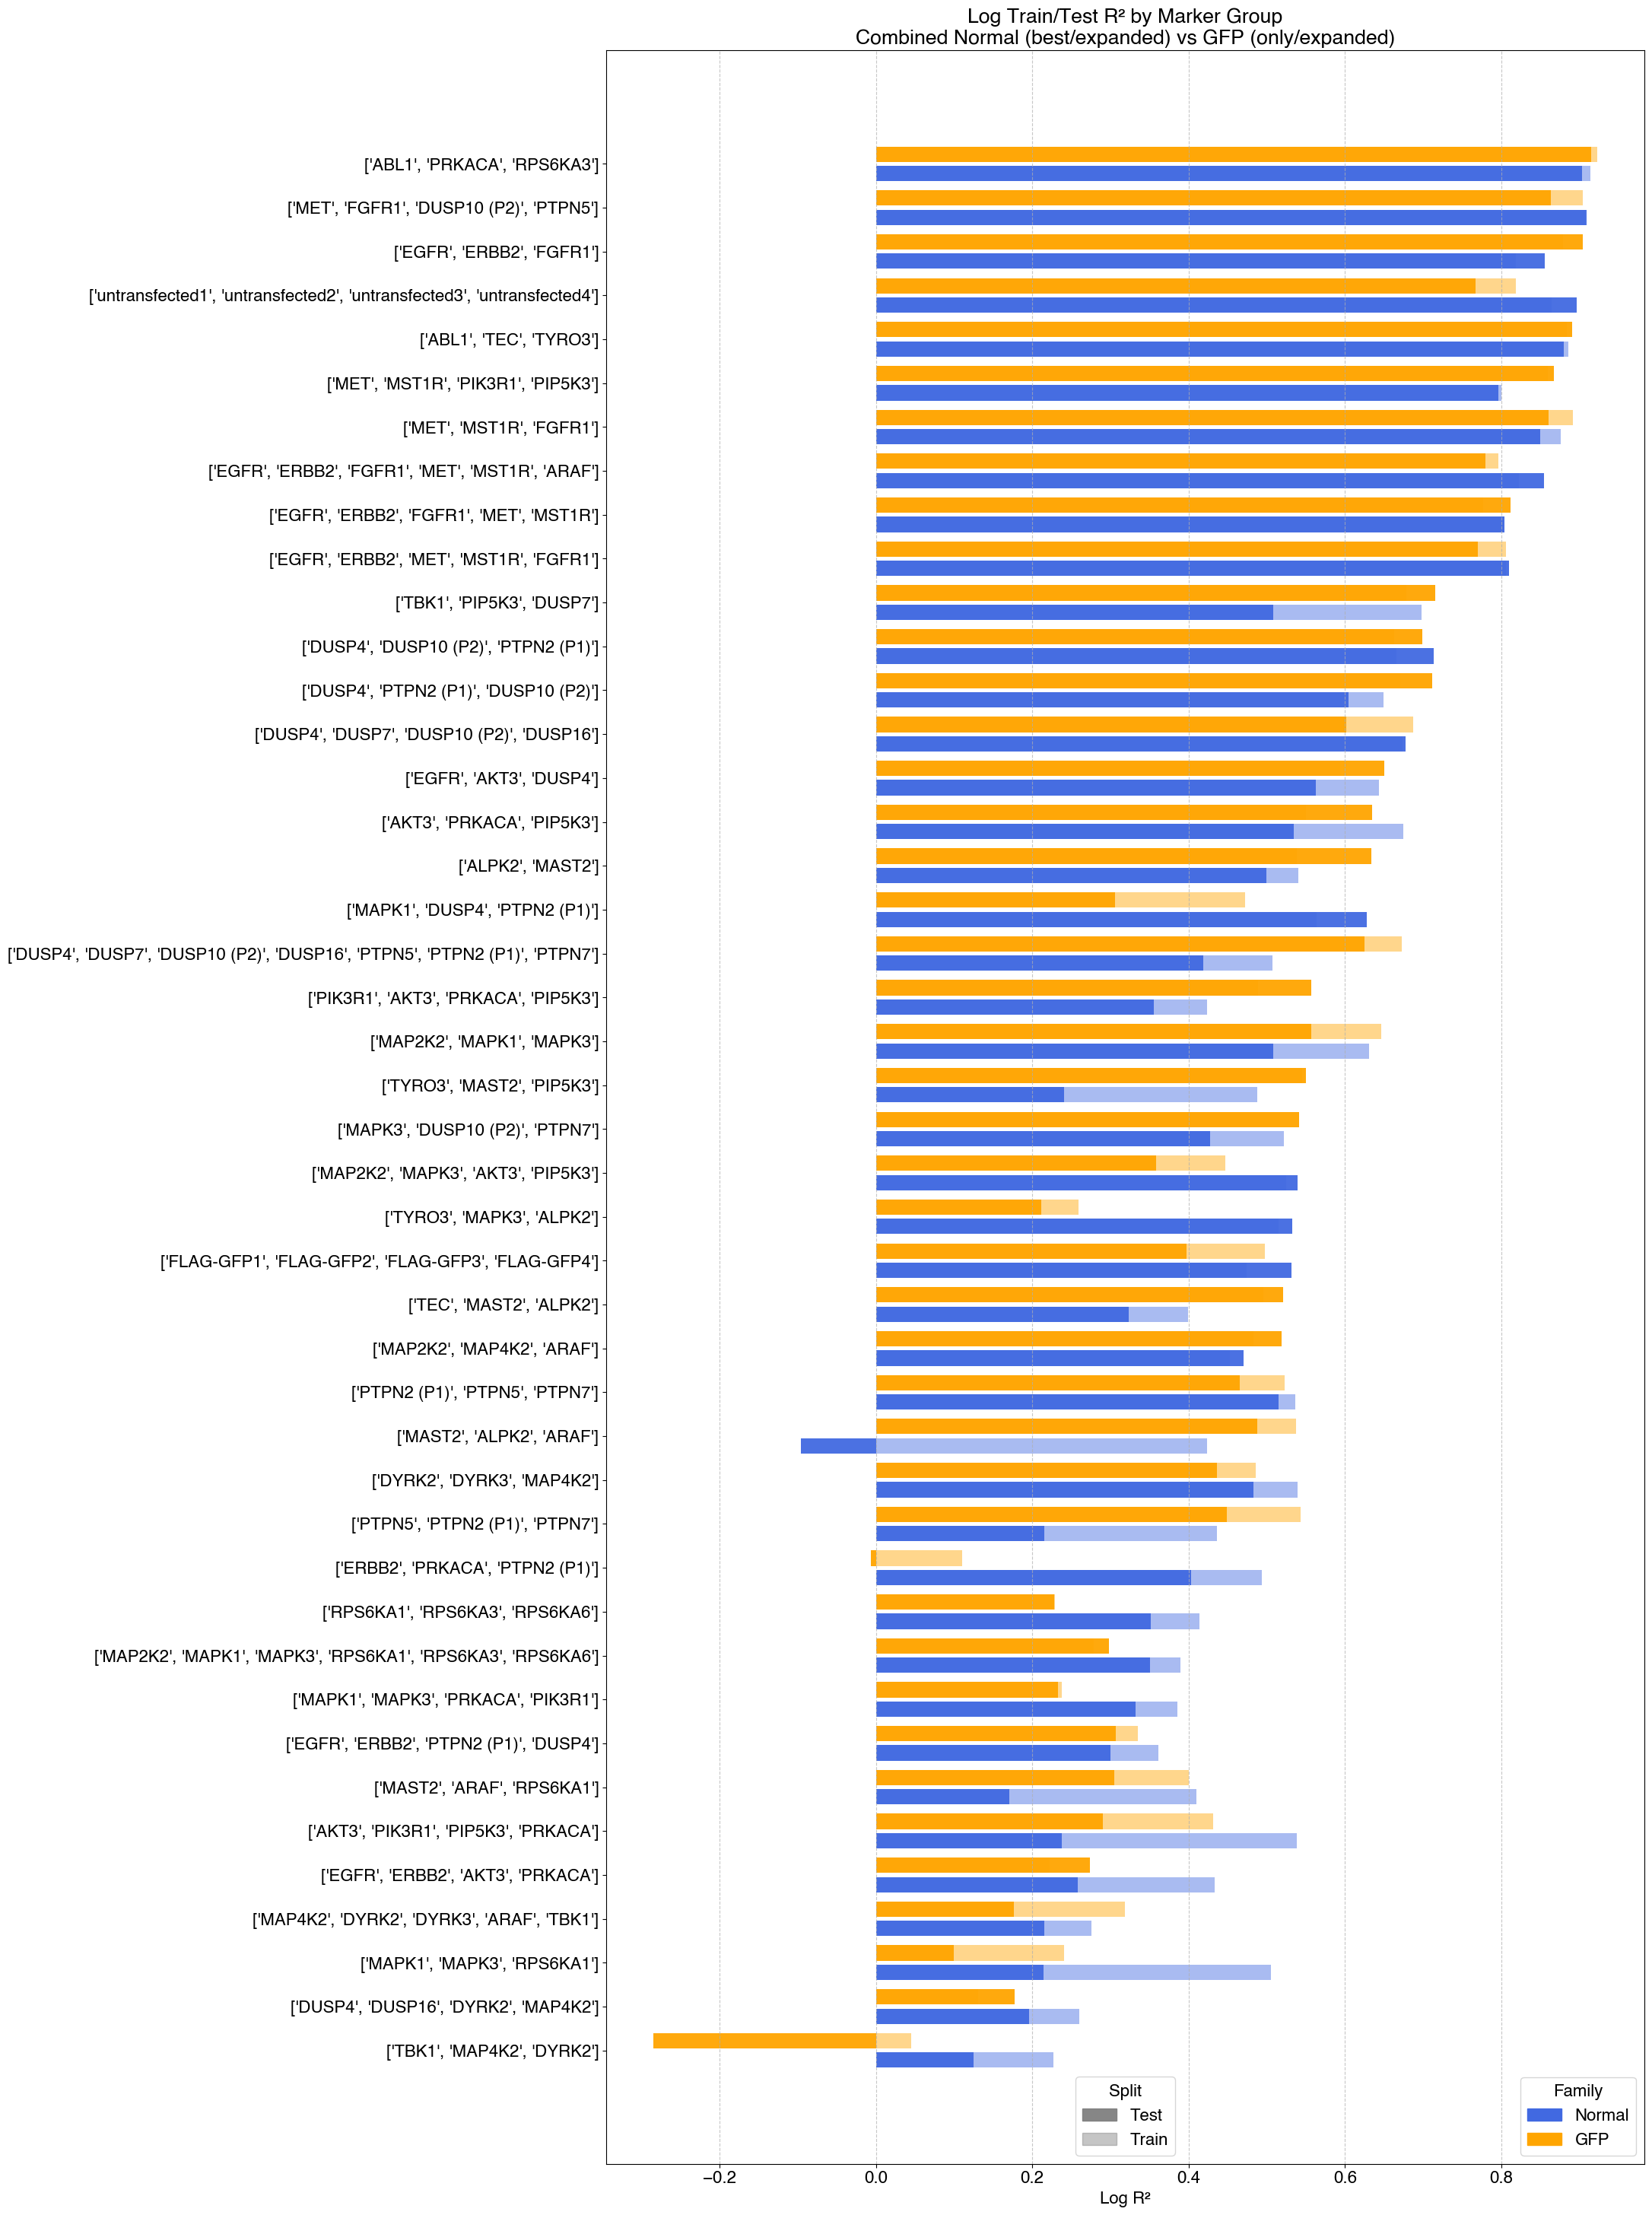

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Helper: union groups across two strategies; keep the entry with higher test R²
def combine_family(strategy_a, strategy_b):
    a = results_by_strategy.get(strategy_a, {})
    b = results_by_strategy.get(strategy_b, {})
    groups = sorted(set(a.keys()) | set(b.keys()))
    rows = []
    for g in groups:
        ra, rb = a.get(g), b.get(g)
        if ra is None:
            chosen, src = rb, strategy_b
        elif rb is None:
            chosen, src = ra, strategy_a
        else:
            chosen, src = (ra, strategy_a) if ra['test_r2_log'] >= rb['test_r2_log'] else (rb, strategy_b)
        rows.append({"group": g,
                     "train_r2_log": chosen['train_r2_log'],
                     "test_r2_log": chosen['test_r2_log'],
                     "source": src})
    return pd.DataFrame(rows)

normal_df = combine_family("best_features", "best_features_expanded")
gfp_df    = combine_family("GFP only", "GFP_expanded")

# Build unified table with union of all groups across families
all_groups = sorted(set(normal_df['group']) | set(gfp_df['group']))
def align_family(df, family_name):
    df = df.set_index('group')
    out = []
    for g in all_groups:
        if g in df.index:
            out.append({"group": g, "family": family_name,
                        "train_r2_log": df.loc[g, 'train_r2_log'],
                        "test_r2_log": df.loc[g, 'test_r2_log'],
                        "source": df.loc[g, 'source']})
        else:
            out.append({"group": g, "family": family_name,
                        "train_r2_log": np.nan, "test_r2_log": np.nan, "source": None})
    return pd.DataFrame(out)

plot_df = pd.concat([align_family(normal_df, "Normal"),
                     align_family(gfp_df,    "GFP")], ignore_index=True)

# Order groups by best available Test R² across families
order = (plot_df.groupby("group")["test_r2_log"]
         .max()
         .sort_values(ascending=True).index.tolist())
plot_df["group"] = pd.Categorical(plot_df["group"], categories=order, ordered=True)
plot_df = plot_df.sort_values(["group", "family"])

# Plot: per group two bars (Normal vs GFP). Test=darker, Train=lighter.
groups = plot_df["group"].cat.categories.tolist()
y = np.arange(len(groups))
bar_h = 0.35
offsets = np.array([-0.22, 0.22])  # Normal left, GFP right

family_colors = {"Normal": "royalblue", "GFP": "orange"}

fig, ax = plt.subplots(figsize=(max(10, len(groups) * 0.5), 0.6 * len(groups) + 3))

for i, fam in enumerate(["Normal", "GFP"]):
    sub = plot_df[plot_df["family"] == fam]
    test_vals, train_vals = [], []
    for g in groups:
        r = sub[sub["group"] == g]
        test_vals.append(r["test_r2_log"].values[0] if len(r) else np.nan)
        train_vals.append(r["train_r2_log"].values[0] if len(r) else np.nan)

    ax.barh(y + offsets[i], test_vals, height=bar_h,
            color=family_colors[fam], alpha=0.95, label=f"{fam} — Test")
    ax.barh(y + offsets[i], train_vals, height=bar_h,
            color=family_colors[fam], alpha=0.45, label=f"{fam} — Train")

ax.set_yticks(y)
ax.set_yticklabels(groups)
ax.set_xlabel("Log R²")
ax.set_title("Log Train/Test R² by Marker Group\nCombined Normal (best/expanded) vs GFP (only/expanded)")
ax.grid(axis="x", linestyle="--", alpha=0.7)

# Legend: color = family; shade = split
fam_patches = [Patch(facecolor=family_colors[f], edgecolor=family_colors[f], label=f) for f in ["Normal", "GFP"]]
shade_patches = [Patch(facecolor="gray", edgecolor="gray", alpha=0.95, label="Test"),
                 Patch(facecolor="gray", edgecolor="gray", alpha=0.45, label="Train")]
leg1 = ax.legend(handles=fam_patches, title="Family", loc="lower right")
ax.add_artist(leg1)
ax.legend(handles=shade_patches, title="Split", loc="lower center")

plt.tight_layout()
plt.show()

Fit with old parametric curve form

['MAP2K2', 'MAPK1', 'MAPK3', 'RPS6KA1', 'RPS6KA3', 'RPS6KA6']
Index(['ABL1', 'AKT3', 'ALPK2', 'ARAF', 'DUSP10 (P2)', 'DUSP16', 'DUSP4',
       'DUSP7', 'DYRK2', 'DYRK3', 'EGFR', 'ERBB2', 'FGFR1', 'FLAG-GFP1',
       'FLAG-GFP2', 'FLAG-GFP3', 'FLAG-GFP4', 'MAP2K2', 'MAP4K2', 'MAPK1',
       'MAPK3', 'MAST2', 'MET', 'MST1R', 'PIK3R1', 'PIP5K3', 'PRKACA',
       'PTPN2 (P1)', 'PTPN5', 'PTPN7', 'RPS6KA1', 'RPS6KA3', 'RPS6KA6', 'TBK1',
       'TEC', 'TYRO3', 'untransfected1', 'untransfected2', 'untransfected3',
       'untransfected4'],
      dtype='object', name='marker')
['MAP2K2', 'MAPK1', 'MAPK3', 'RPS6KA1', 'RPS6KA3', 'RPS6KA6']
Index(['ABL1', 'AKT3', 'ALPK2', 'ARAF', 'DUSP10 (P2)', 'DUSP16', 'DUSP4',
       'DUSP7', 'DYRK2', 'DYRK3', 'EGFR', 'ERBB2', 'FGFR1', 'FLAG-GFP1',
       'FLAG-GFP2', 'FLAG-GFP3', 'FLAG-GFP4', 'MAP2K2', 'MAP4K2', 'MAPK1',
       'MAPK3', 'MAST2', 'MET', 'MST1R', 'PIK3R1', 'PIP5K3', 'PRKACA',
       'PTPN2 (P1)', 'PTPN5', 'PTPN7', 'RPS6KA1', 'RPS6KA3', 'RPS6KA6'

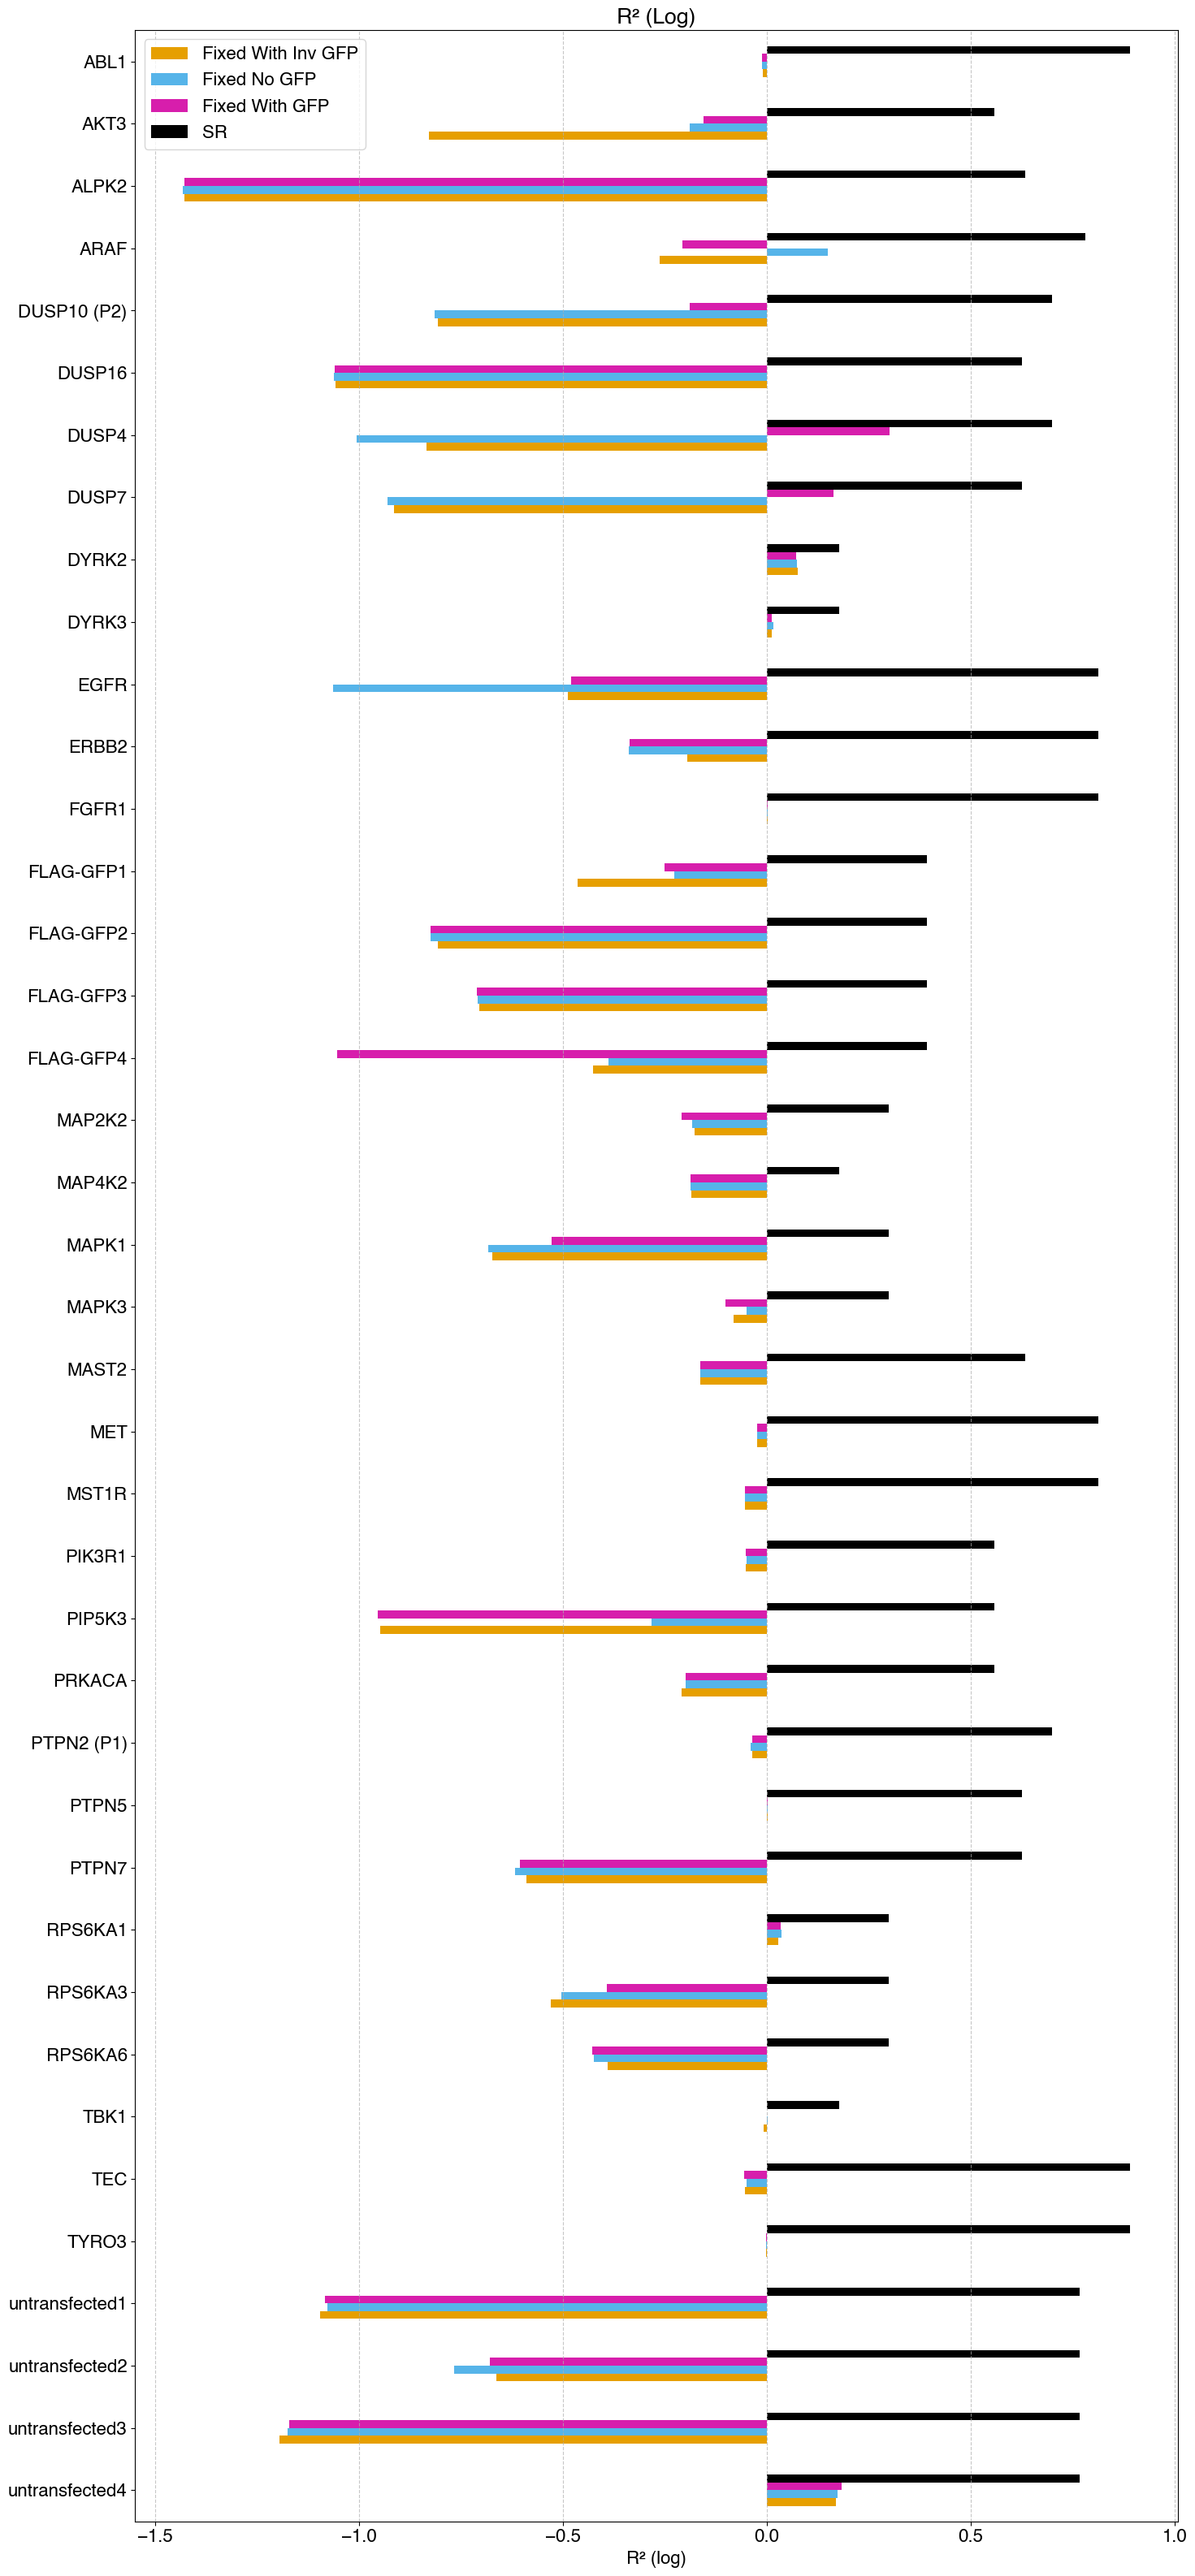

In [57]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

def signed_log(x, epsilon=log10_cutoff):
    return np.sign(x) * (np.log10(np.abs(x) + 10**epsilon) - epsilon)

markers = data['marker'].unique()
r2_scores = []
r2_log_scores = []

for marker in markers:
    subset = data[data['marker'] == marker].dropna(subset=['p-ERK1-2', 'p-ERK1-2_min', 'GFP', 'p-ERK1-2_dt'])
    if len(subset) < 5:
        r2_scores.append(np.nan)
        r2_log_scores.append(np.nan)
        continue

    X_perk = subset['p-ERK1-2'].values
    X_perkmin = subset['p-ERK1-2_min'].values
    X_gfp = subset['p-RAF'].values
    y = subset['p-ERK1-2_dt'].values

    def loss(params):
        A, B, C = params
        y_pred = curve_func(-X_perk + X_perkmin, X_gfp, A, B, C)
        return mean_absolute_error(signed_log(y), signed_log(y_pred))

    res = minimize(loss, x0=[0.01, 0.0001, 0.0], method='Nelder-Mead')
    A_fit, B_fit, C_fit = res.x
    y_pred = curve_func(-X_perk + X_perkmin, X_gfp, A_fit, B_fit, C_fit)

    r2_scores.append(r2_score(y, y_pred))
    r2_log_scores.append(r2_score(signed_log(y), signed_log(y_pred)))

# Create DataFrame for plotting
results_df = pd.DataFrame({
    'marker': markers,
    'R2': r2_scores,
    'R2_log': r2_log_scores
}).set_index('marker')

# Compute R² for the model without the GFP term
r2_scores_nogfp = []
r2_log_scores_nogfp = []

for marker in markers:
    subset = data[data['marker'] == marker].dropna(subset=['p-ERK1-2', 'p-ERK1-2_min', 'GFP', 'p-ERK1-2_dt'])
    if len(subset) < 5:
        r2_scores_nogfp.append(np.nan)
        r2_log_scores_nogfp.append(np.nan)
        continue

    X_perk = subset['p-ERK1-2'].values
    X_perkmin = subset['p-ERK1-2_min'].values
    y = subset['p-ERK1-2_dt'].values

    def loss_nogfp(params):
        A, B = params
        y_pred = A / (-X_perk + X_perkmin + B)
        return mean_absolute_error(signed_log(y), signed_log(y_pred))

    res_nogfp = minimize(loss_nogfp, x0=[0.01, 0.0001], method='Nelder-Mead')
    A_fit_nogfp, B_fit_nogfp = res_nogfp.x
    y_pred_nogfp = A_fit_nogfp / (-X_perk + X_perkmin + B_fit_nogfp)

    r2_scores_nogfp.append(r2_score(y, y_pred_nogfp))
    r2_log_scores_nogfp.append(r2_score(signed_log(y), signed_log(y_pred_nogfp)))

r2_scores_gfp = []
r2_log_scores_gfp = []

for marker in markers:
    subset = data[data['marker'] == marker].dropna(subset=['p-ERK1-2', 'p-ERK1-2_min', 'GFP', 'p-ERK1-2_dt'])
    if len(subset) < 5:
        r2_scores_gfp.append(np.nan)
        r2_log_scores_gfp.append(np.nan)
        continue

    X_perk = subset['p-ERK1-2'].values
    X_perkmin = subset['p-ERK1-2_min'].values
    X_gfp = subset['GFP'].values
    y = subset['p-ERK1-2_dt'].values

    def loss(params):
        A, B, C = params
        y_pred = curve_func(-X_perk + X_perkmin, X_gfp, A, B, C)
        return mean_absolute_error(signed_log(y), signed_log(y_pred))

    res = minimize(loss, x0=[0.01, 0.0001, 0.0], method='Nelder-Mead')
    A_fit, B_fit, C_fit = res.x
    y_pred = curve_func(-X_perk + X_perkmin, X_gfp, A_fit, B_fit, C_fit)

    r2_scores_gfp.append(r2_score(y, y_pred))
    r2_log_scores_gfp.append(r2_score(signed_log(y), signed_log(y_pred)))



# Add to results_df
results_df['R2_nogfp'] = r2_scores_nogfp
results_df['R2_log_nogfp'] = r2_log_scores_nogfp
results_df['R2_gfp'] = r2_scores_gfp
results_df['R2_log_gfp'] = r2_log_scores_gfp

marker_group_names = []
train_r2_log_list = []
test_r2_log_list = []

results_df['test_sr_r2_log'] = np.nan  # Initialize with NaN for test SR R²

for group, res in results_by_strategy["GFP only"].items():
    marker_group_names.append(group)
    train_r2_log_list.append(res['train_r2_log'])
    test_r2_log_list.append(res['test_r2_log'])
    for marker in res['markers_choice']:
        print(res['markers_choice'])
        print(results_df.index.unique())
        if pd.notna(results_df.loc[marker, 'test_sr_r2_log']):
            results_df.loc[marker, 'test_sr_r2_log'] = max(results_df.loc[marker, 'test_sr_r2_log'], res['test_r2_log'])
        else:
            results_df.loc[marker, 'test_sr_r2_log'] = res['test_r2_log']

# Reverse the order of marker groups for plotting
results_df = results_df.iloc[::-1]
# Grouped bar plot for comparison
fig, ax = plt.subplots(1, 1, figsize=(15, len(markers) * 0.8), sharex=True)

# Color-blind friendly palette: orange, blue, green, red
color_blind_palette = ['#E69F00', '#56B4E9', "#D71EAC", "#000000"]
results_df[['R2_log', 'R2_log_nogfp', 'R2_log_gfp', 'test_sr_r2_log']].plot(
    kind='barh', ax=ax, color=color_blind_palette
)
ax.set_title('R² (Log)')
ax.set_xlabel('R² (log)')
ax.set_ylabel('')
ax.legend(['Fixed With Inv GFP', 'Fixed No GFP', 'Fixed With GFP', 'SR'])

ax.grid(True, axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



0.7357754165476137
ABL1 0.002770124630309667
1.726360571535506
AKT3 22.670158473981658
0.6452192892046764
ALPK2 0.7772598478613582
0.5362494539569459
ARAF 1924291350833439.0
0.6019528126344688
DUSP10 (P2) 2169648567986066.0
0.3593588405184889
DUSP16 0.0009548075274348424
0.5314048949655175
DUSP4 3.342732892585367
0.641167416975078
DUSP7 2.6116544694966572
0.5080974395387031
DYRK2 0.0032380842669254076
0.8031260108246175
DYRK3 0.0013310825171730847
0.4781890242330323
EGFR 0.0030614176758920557
0.4724593922061796
ERBB2 0.0015051570208993092
0.7136470578240709
FGFR1 0.0030189102417312293
1.7994064633872988
FLAG-GFP1 -0.12438103651585522
1.31037718909
FLAG-GFP2 -0.0017970403155641928
1.390781190083913
FLAG-GFP3 -0.0001693982434080171
1.714658960052174
FLAG-GFP4 -0.013486236225658657
1.9812284446746575
MAP2K2 0.003887008758331062
0.8108791079786112
MAP4K2 0.00273239446653334
1.0437125350758214
MAPK1 5.961367953161038
1.0652872324
MAPK3 -0.16980479695905742
1.397814151331657
MAST2 0.00116140

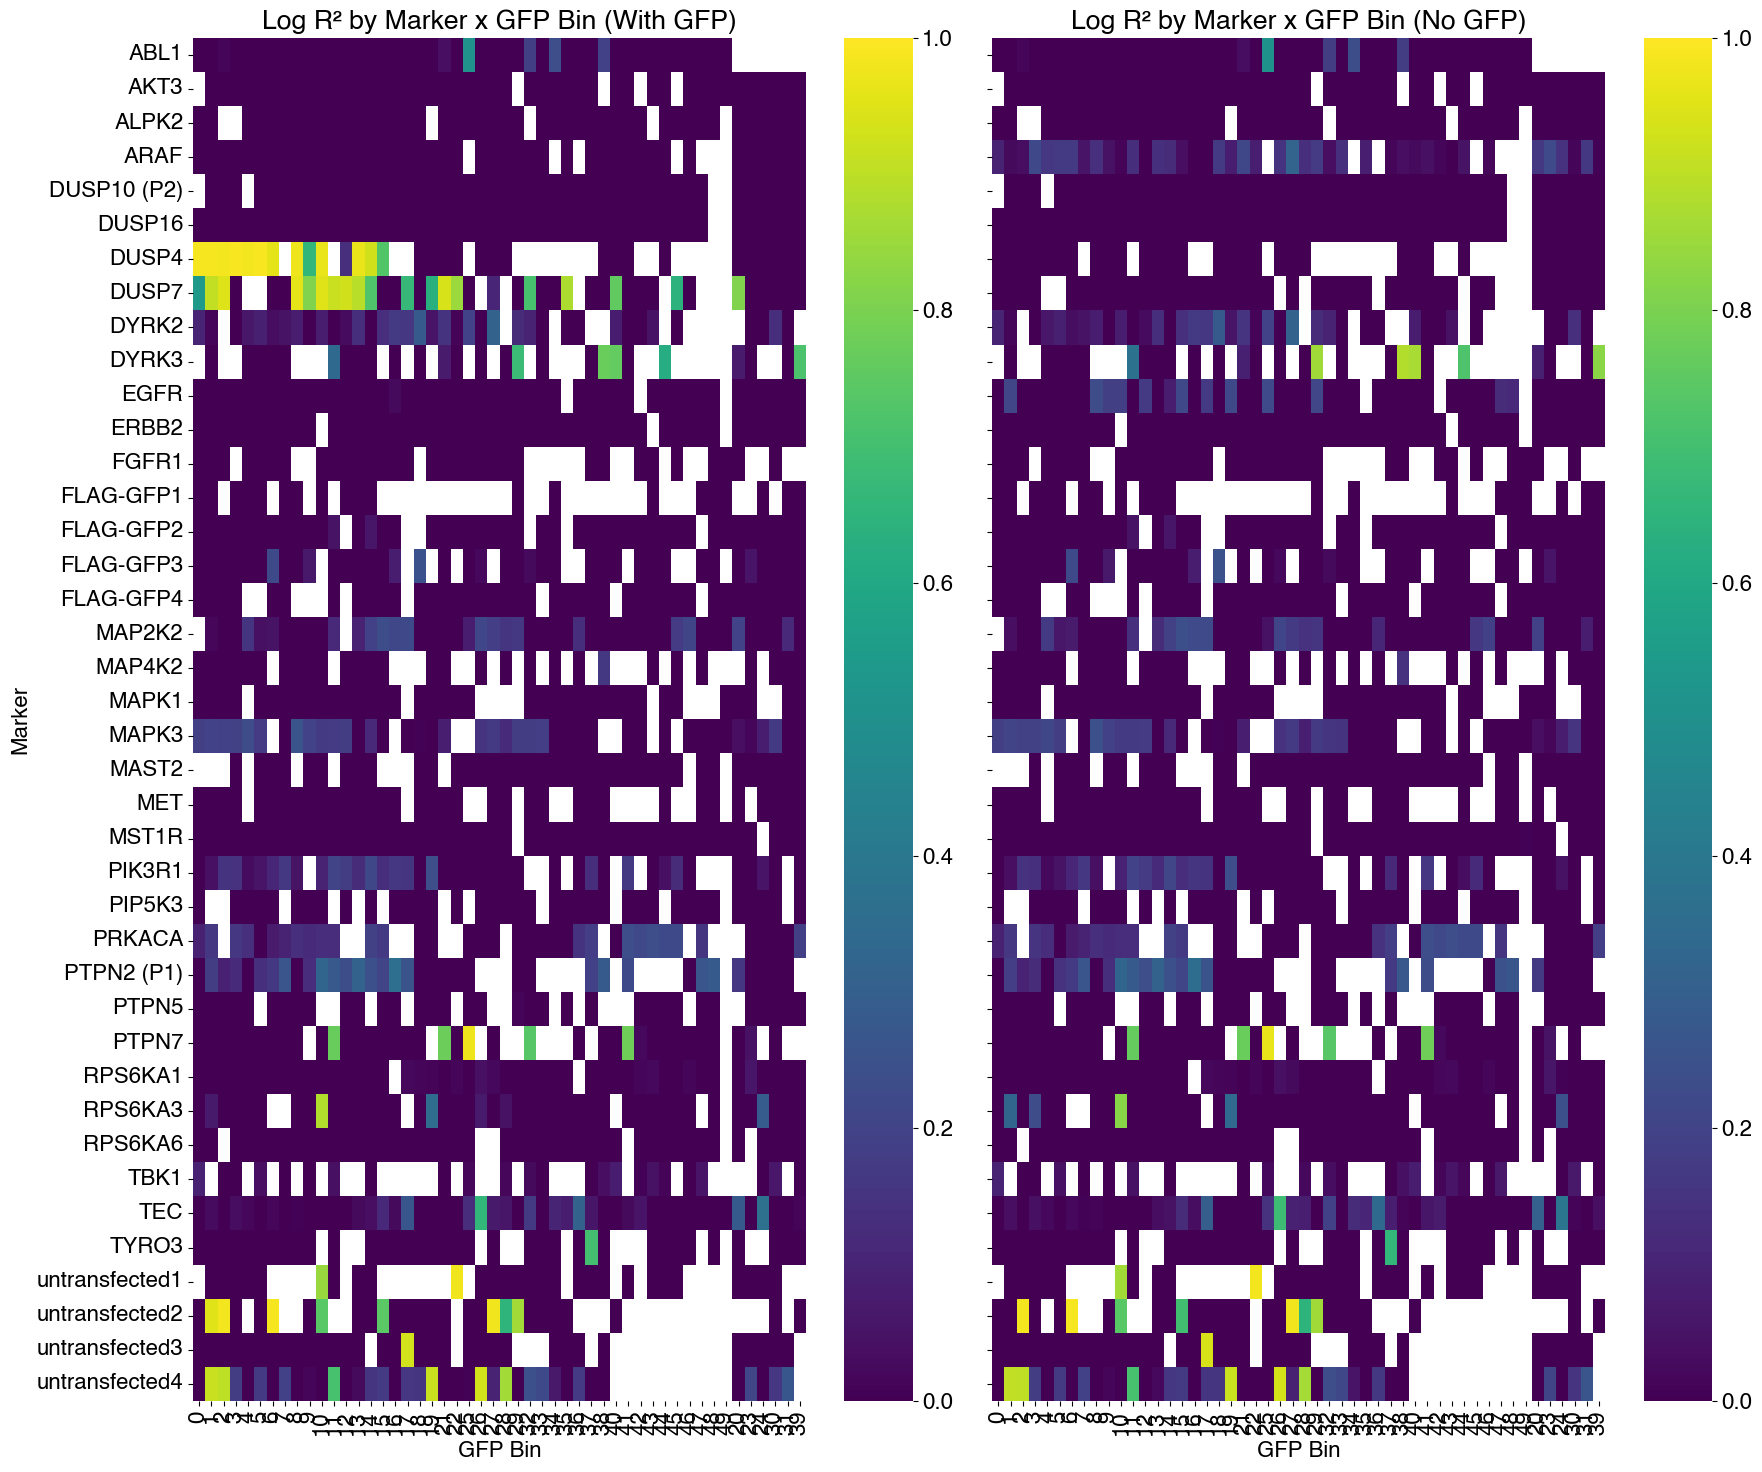

In [59]:
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import r2_score
import seaborn as sns

import matplotlib.pyplot as plt

markers = data['marker'].unique()
gfp_bins = data['GFP_bin'].unique()

# Initialize result matrices
r2_with_gfp = np.full((len(markers), len(gfp_bins)), np.nan)
r2_without_gfp = np.full((len(markers), len(gfp_bins)), np.nan)

def signed_log(x, epsilon=log10_cutoff):
    return np.sign(x) * (np.log10(np.abs(x) + 10**epsilon) - epsilon)

for i, marker in enumerate(markers):
    marker_data = data[data['marker'] == marker].dropna(subset=['p-ERK1-2', 'p-ERK1-2_min', 'p-MEK1-2', 'GFP', 'p-ERK1-2_dt'])
    if len(marker_data) < 6:
        continue

    X_perk = marker_data['p-ERK1-2'].values
    X_perkmin = marker_data['p-ERK1-2_min'].values
    X_gfp = marker_data['GFP'].values
    print(X_gfp[56])
    y = marker_data['p-ERK1-2_dt'].values
    gfp_bin_vals = marker_data['GFP_bin'].values

    # Fit with GFP
    def loss(params):
        A, B, C = params
        y_pred = curve_func(-X_perk + X_perkmin, X_gfp, A, B, C)
        return np.mean(np.abs(signed_log(y) - signed_log(y_pred)))
    res = minimize(loss, x0=[0.01, 0.0001, 0.0], method='Nelder-Mead', options={'maxiter': 10000})
    A_fit, B_fit, C_fit = res.x


    print(marker, C_fit)

    # Fit without GFP
    def loss_nogfp(params):
        A, B = params
        y_pred = A / (-X_perk + X_perkmin + B)
        return np.mean(np.abs(signed_log(y) - signed_log(y_pred)))
    res_nogfp = minimize(loss_nogfp, x0=[0.01, 0.0001], method='Nelder-Mead')
    A_fit_nogfp, B_fit_nogfp = res_nogfp.x

    # Evaluate R² for each GFP bin
    for j, gfp_bin in enumerate(gfp_bins):
        mask = gfp_bin_vals == gfp_bin
        if np.sum(mask) < 5:
            continue
        y_bin = y[mask]
        X_perk_bin = X_perk[mask]
        X_perkmin_bin = X_perkmin[mask]
        X_gfp_bin = X_gfp[mask]

        # With GFP
        y_pred_bin = curve_func(-X_perk_bin + X_perkmin_bin, X_gfp_bin, A_fit, B_fit, C_fit)
        r2_with_gfp[i, j] = r2_score(signed_log(y_bin), signed_log(y_pred_bin))

        # Without GFP
        y_pred_bin_nogfp = A_fit_nogfp / (-X_perk_bin + X_perkmin_bin + B_fit_nogfp)
        r2_without_gfp[i, j] = r2_score(signed_log(y_bin), signed_log(y_pred_bin_nogfp))


# Plot heatmaps

# Clip R² values below 0 to 0 for visualization
r2_with_gfp_clipped = np.clip(r2_with_gfp, 0, None)
r2_without_gfp_clipped = np.clip(r2_without_gfp, 0, None)

fig, axes = plt.subplots(1, 2, figsize=(18, len(markers) * 0.3 + 3), sharey=True)

sns.heatmap(r2_with_gfp_clipped, ax=axes[0], cmap='viridis', vmin=0, vmax=1,
            xticklabels=gfp_bins.astype(int), yticklabels=markers)
axes[0].set_title('Log R² by Marker x GFP Bin (With GFP)')
axes[0].set_xlabel('GFP Bin')
axes[0].set_ylabel('Marker')

sns.heatmap(r2_without_gfp_clipped, ax=axes[1], cmap='viridis', vmin=0, vmax=1,
            xticklabels=gfp_bins.astype(int), yticklabels=markers)
axes[1].set_title('Log R² by Marker x GFP Bin (No GFP)')
axes[1].set_xlabel('GFP Bin')

plt.tight_layout()
plt.show()

DUSP16 Fit Parameters: A=-10704704637.51508, B=0.00018527543238105055, C=3972061704065.889
Overall signed log R² for DUSP16 (all GFP bins): -0.0347


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_58910/2994635629.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05))


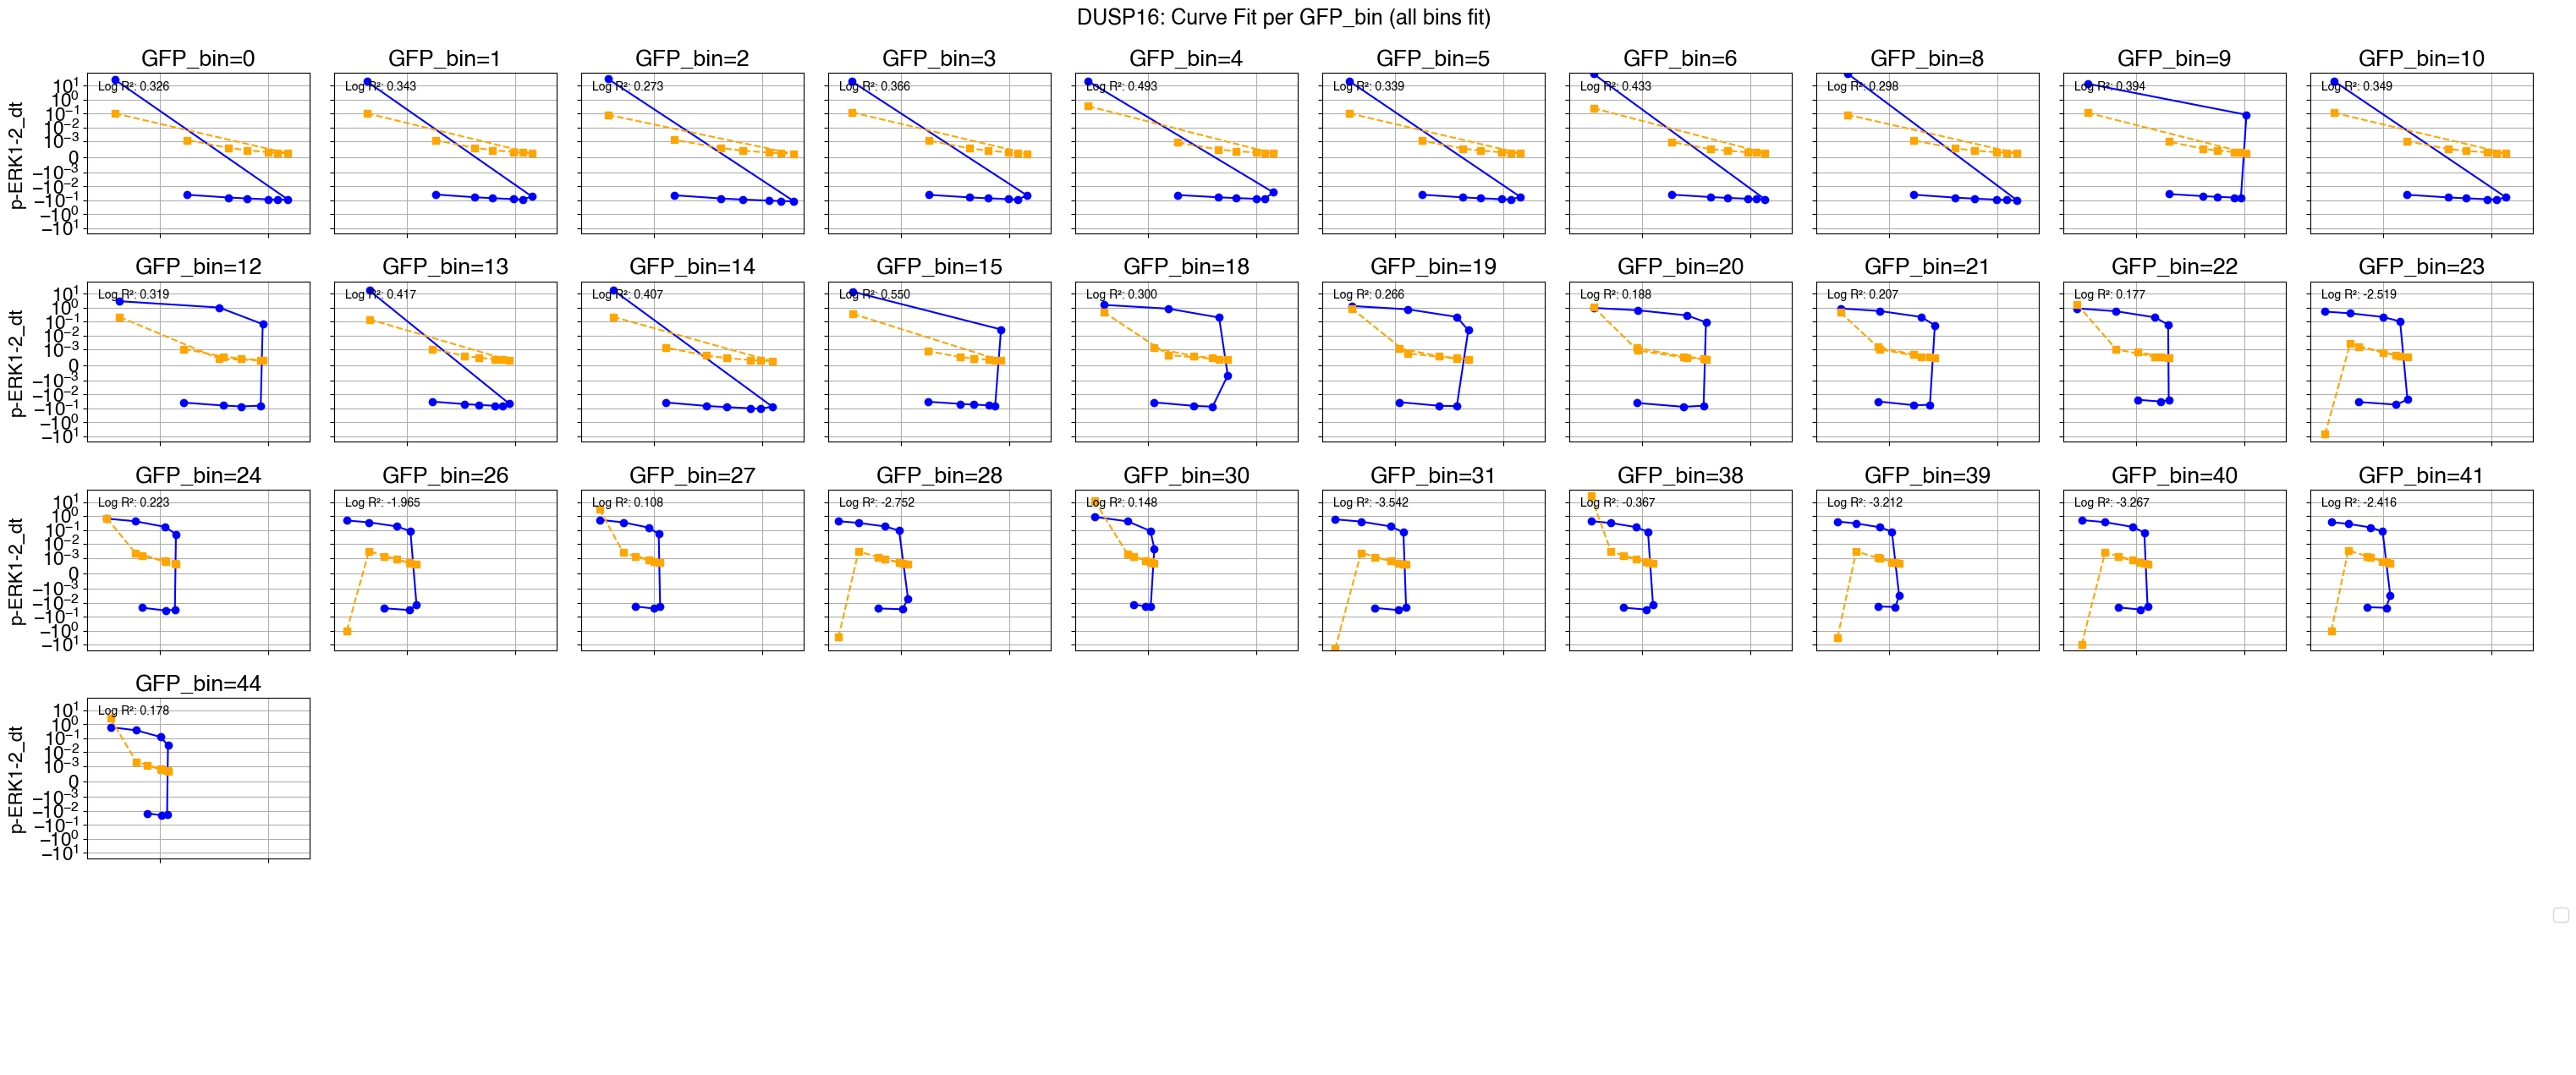

In [68]:
from scipy.optimize import minimize
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

# Filter data for DUSP16
dusp16_data = data[data['marker'] == 'DUSP4'].copy()
dusp16_data = dusp16_data.dropna(subset=['GFP_bin', 'p-ERK1-2', 'p-ERK1-2_min', 'GFP', 'p-ERK1-2_dt'])

# Fit the curve to all DUSP16 data (all bins)
X_perk = dusp16_data['p-ERK1-2'].values
X_perkmin = dusp16_data['p-ERK1-2_min'].values
X_gfp = dusp16_data['p-MEK1-2'].values
y = dusp16_data['p-ERK1-2_dt'].values

def signed_log(x, epsilon=log10_cutoff):
    return np.sign(x) * (np.log10(np.abs(x) + 10**epsilon) - epsilon)

def loss(params):
    A, B, C = params
    y_pred = curve_func(-X_perk + X_perkmin, X_gfp, A, B, C)
    return np.mean(np.abs(signed_log(y) - signed_log(y_pred)))

res = minimize(loss, x0=[0.01, 0.0001, 1.0], method='Nelder-Mead', options={'maxiter': 1000000})
A_fit, B_fit, C_fit = res.x

print(f"DUSP16 Fit Parameters: A={A_fit}, B={B_fit}, C={C_fit}")

# Prepare grid for plotting
gfp_bins = np.sort(dusp16_data['GFP_bin'].unique())
n_bins = len(gfp_bins)
n_cols = 10
n_rows = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5), sharex=True, sharey=True)
axes = axes.flatten()

for i, gfp_bin in enumerate(gfp_bins):
    ax = axes[i]
    bin_data = dusp16_data[dusp16_data['GFP_bin'] == gfp_bin]
    if bin_data.empty:
        ax.axis('off')
        continue

    X_perk_bin = bin_data['p-ERK1-2'].values
    X_perkmin_bin = bin_data['p-ERK1-2_min'].values
    X_gfp_bin = bin_data['p-MEK1-2'].values
    y_true = bin_data['p-ERK1-2_dt'].values

    # Model prediction using fitted parameters
    y_pred = curve_func(-X_perk_bin + X_perkmin_bin, X_gfp_bin, A_fit, B_fit, C_fit)

    ax.plot(X_perk_bin, y_true, 'o-', label='True', color='blue')
    ax.plot(X_perk_bin, y_pred, 's--', label='Fit', color='orange')
    ax.set_title(f'GFP_bin={int(gfp_bin)}')
    ax.grid(True)
    if i % n_cols == 0:
        ax.set_ylabel('p-ERK1-2_dt')
    if i >= (n_rows - 1) * n_cols:
        ax.set_xlabel('p-ERK1-2')

    # Compute and print signed log R² for each GFP_bin
    y_true_log = signed_log(y_true)
    y_pred_log = signed_log(y_pred)
    r2_log = r2_score(y_true_log, y_pred_log)
    ax.text(0.05, 0.95, f"Log R²: {r2_log:.3f}", transform=ax.transAxes, fontsize=10, verticalalignment='top')


# Hide unused subplots
for j in range(i + 1, n_rows * n_cols):
    axes[j].axis('off')

    # Compute and print overall signed log R² across all GFP bins for DUSP16
y_true_all = dusp16_data['p-ERK1-2_dt'].values
X_perk_all = dusp16_data['p-ERK1-2'].values
X_perkmin_all = dusp16_data['p-ERK1-2_min'].values
X_gfp_all = dusp16_data['GFP'].values
y_pred_all = curve_func(-X_perk_all + X_perkmin_all, X_gfp_all, A_fit, B_fit, C_fit)

r2_log_all = r2_score(signed_log(y_true_all), signed_log(y_pred_all))
print(f"Overall signed log R² for DUSP16 (all GFP bins): {r2_log_all:.4f}")

plt.tight_layout()
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05))
plt.suptitle('DUSP16: Curve Fit per GFP_bin (all bins fit)', y=1.02, fontsize=18)
plt.yscale('symlog', linthresh=1e-3)
plt.show()

Real curve form

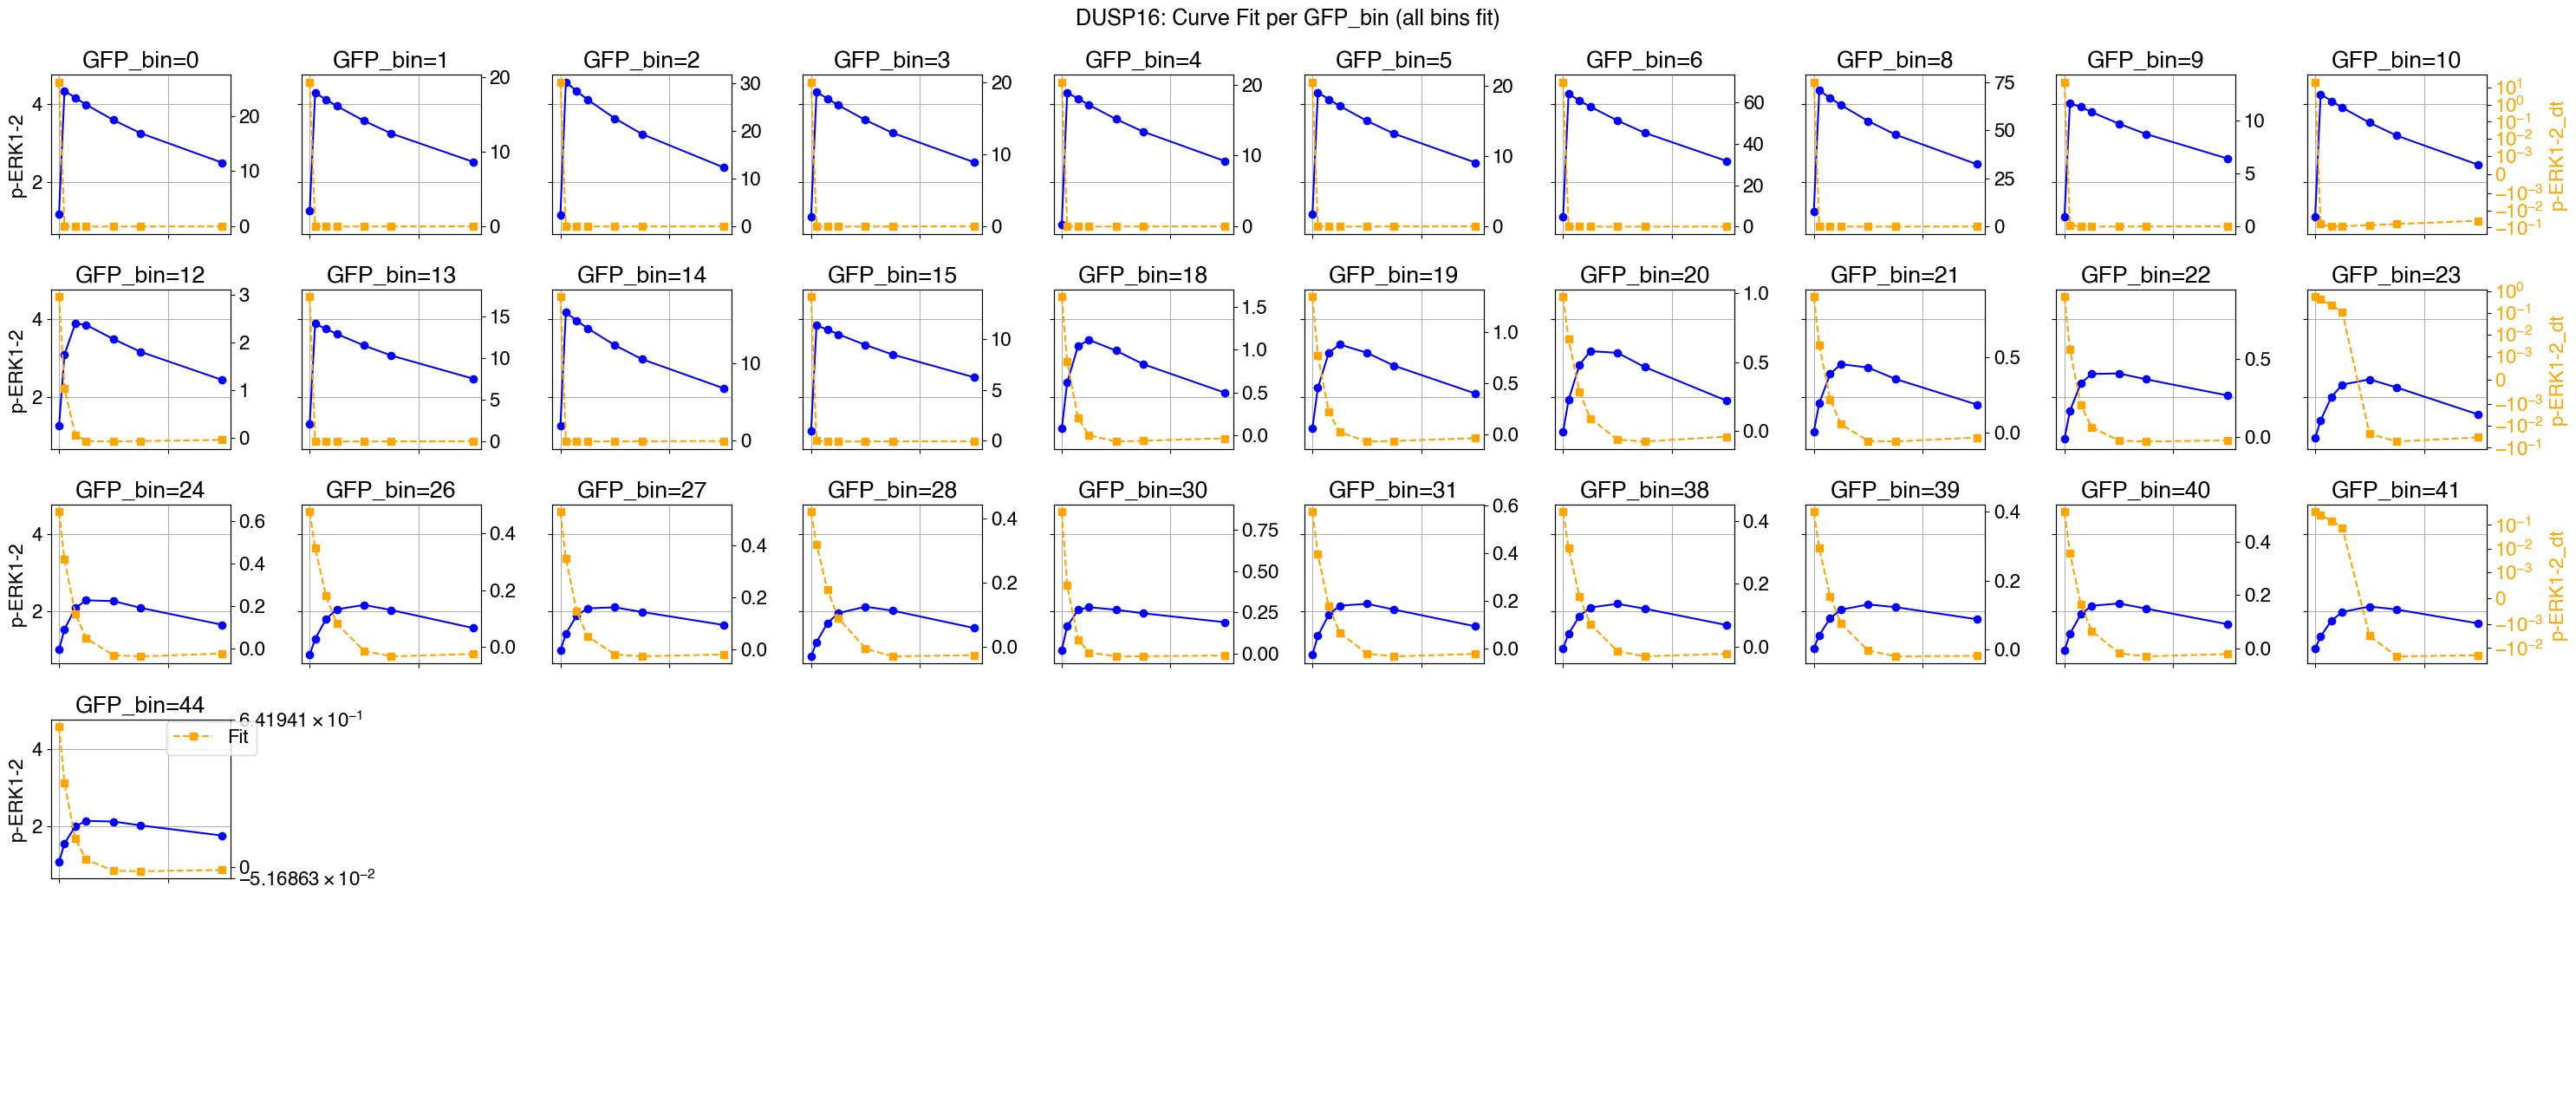

In [69]:
from scipy.optimize import minimize

import matplotlib.pyplot as plt

# Filter data for DUSP16
dusp16_data = data[data['marker'] == 'DUSP4'].copy()
dusp16_data = dusp16_data.dropna(subset=['GFP_bin', 'p-ERK1-2', 'p-ERK1-2_min', 'GFP', 'p-ERK1-2_dt'])


# Prepare grid for plotting
gfp_bins = np.sort(dusp16_data['GFP_bin'].unique())
n_bins = len(gfp_bins)
n_cols = 10
n_rows = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5), sharex=True, sharey=True)
axes = axes.flatten()

for i, gfp_bin in enumerate(gfp_bins):
    ax = axes[i]
    bin_data = dusp16_data[dusp16_data['GFP_bin'] == gfp_bin]
    if bin_data.empty:
        ax.axis('off')
        continue

    X_perk_bin = bin_data['p-ERK1-2'].values
    X_perkmin_bin = bin_data['p-ERK1-2_dt'].values
    timepoint = bin_data['timepoint'].values


    ax.plot(timepoint, X_perk_bin, 'o-', label='True', color='blue')
    ax2 = ax.twinx()
    ax2.plot(timepoint, X_perkmin_bin, 's--', label='Fit', color='orange')

    ax.set_title(f'GFP_bin={int(gfp_bin)}')
    ax.grid(True)
    if i % n_cols == 0:
        ax.set_ylabel('p-ERK1-2')
    if i % n_cols == 9:
        ax2.set_ylabel('p-ERK1-2_dt', color='orange')
        ax2.tick_params(axis='y', labelcolor='orange')
        ax2.set_yscale('symlog', linthresh=1e-3)
    if i >= (n_rows - 1) * n_cols:
        ax.set_xlabel('time')


# Hide unused subplots
for j in range(i + 1, n_rows * n_cols):
    axes[j].axis('off')

plt.tight_layout()
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05))
plt.suptitle('DUSP16: Curve Fit per GFP_bin (all bins fit)', y=1.02, fontsize=18)
plt.yscale('symlog')
plt.show()

Checking best performing groups from sweep

In [70]:
log10_cutoff = -2  # Cutoff for log10 transformation to avoid log(0

def signed_log(x, epsilon=log10_cutoff):
    return np.sign(x) * (np.log10(np.abs(x) + 10**epsilon) - epsilon)

In [71]:
unique_markers

array(['ABL1', 'AKT3', 'ALPK2', 'ARAF', 'DUSP10 (P2)', 'DUSP16', 'DUSP4',
       'DUSP7', 'DYRK2', 'DYRK3', 'EGFR', 'ERBB2', 'FGFR1', 'FLAG-GFP1',
       'FLAG-GFP2', 'FLAG-GFP3', 'FLAG-GFP4', 'MAP2K2', 'MAP4K2', 'MAPK1',
       'MAPK3', 'MAST2', 'MET', 'MST1R', 'PIK3R1', 'PIP5K3', 'PRKACA',
       'PTPN2 (P1)', 'PTPN5', 'PTPN7', 'RPS6KA1', 'RPS6KA3', 'RPS6KA6',
       'TBK1', 'TEC', 'TYRO3', 'untransfected1', 'untransfected2',
       'untransfected3', 'untransfected4'], dtype=object)

In [102]:
# markers_choice = ['DUSP7', 'PTPN7', 'DUSP16']
# markers_choice = ['untransfected4']#['untransfected1', 'untransfected2', 'untransfected3', 'untransfected4']
marker_choice = ['EGFR', 'ERBB2', 'FGFR1']

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [103]:
best_best_features
best_best_features_expanded = list(set(best_best_features) | {'GFP', 'p-ERK1-2_min'})

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [104]:
log10_cutoff = -2

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [105]:
from IPython.display import display, Math

features_choice = best_best_features_expanded

results_by_group = {}
for markers_choice in [markers_choice]:
    print(f"Processing markers: {markers_choice}")
        
    
    # Filter the balanced data for the selected markers
    balanced_data_filtered = balanced_data[(balanced_data['marker'].isin(markers_choice))]

    # balanced_data_filtered = balanced_data_filtered[balanced_data_filtered['GFP_bin'] >= 25]

    X = balanced_data_filtered.drop(columns=['p-ERK1-2_dt', 'p-MEK1-2_dt', 'marker', 'timepoint', 'GFP_bin'])
    y = balanced_data_filtered['p-ERK1-2_dt']

    # Remove rows with NaN values in X or y
    X = X.dropna()
    X = X[features_choice]
    y = y[X.index]

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    X_train.columns = X_train.columns.str.replace('-', '_')
    X_test.columns = X_test.columns.str.replace('-', '_')


    # Assume 'GFP' and 'timepoint' are in balanced_data_filtered
    weights = np.ones(len(balanced_data_filtered))

    # Option 1: Emphasize higher GFP values (linear or exponential)
    weights *= 3 * balanced_data_filtered['GFP'] # or e.g. np.exp(0.5 * balanced_data_filtered['GFP'])

    # # Option 2: Emphasize specific timepoints (e.g., 5 min)
    # weights *= (balanced_data_filtered['timepoint'] == 5).astype(float) * 4 + 1  # double weight for 5min

    # Subset to the same indices as X and y (after dropna)
    weights = weights.loc[X.index]

    model = PySRRegressor(
                niterations=N_ITERATIONS,
                population_size=POPULATION_SIZE,
                populations=POPULATIONS,
                binary_operators=BINARY_OPERATORS,
                # unary_operators=UNARY_OPERATORS,
                maxsize=MAX_SIZE,
                # maxdepth=MAX_DEPTH,
                # parsimony=PARSIMONY,
                verbosity=1,
                batching=BATCHING,
                elementwise_loss=LOG_SPACE_LOSS,
                annealing=ANNEALING,
                # weights=weights
            )

    model.fit(X_train, y_train)

    y_pred_test = model.predict(X_test.values)
    y_pred_train = model.predict(X_train)

    # Calculate the loss on the test and training sets
    rel_mae_train = np.mean(np.abs((y_train - y_pred_train) / (np.abs(y_train) + 1e-8)))
    rel_mae_test = np.mean(np.abs((y_test - y_pred_test) / (np.abs(y_test) + 1e-8)))

    test_loss_log = mean_absolute_error(signed_log(y_test), signed_log(y_pred_test))
    train_loss_log = mean_absolute_error(signed_log(y_train), signed_log(y_pred_train))

    # Calculate R² on the test and training sets
    test_r2 = r2_score(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)

    test_r2_log = r2_score(signed_log(y_test), signed_log(y_pred_test))
    train_r2_log = r2_score(signed_log(y_train), signed_log(y_pred_train))

    # Store only metrics and marker group in a dict (one entry for this run)
    results = {
        'markers_choice': markers_choice,
        'train_loss_log': train_loss_log,
        'test_loss_log': test_loss_log,
        'rel_mae_train': rel_mae_train,
        'rel_mae_test': rel_mae_test,
        'train_r2_log': train_r2_log,
        'test_r2_log': test_r2_log,
        'train_r2': train_r2,
        'test_r2': test_r2,
    }

    results_by_group[str(markers_choice)] = results

    print(f"Training set size: {len(y_train)}")
    print(f"Test set size: {len(y_test)}")
    print()
    print("Best model equation:")
    display(Math(f"$$ {model.latex()} $$"))
    print()
    print(f"Log MAE on Training Set: {train_loss_log:.4f}")
    print(f"Log MAE on Test Set: {test_loss_log:.4f}")
    print()
    print(f"Relative MAE on Training Set: {rel_mae_train:.4f}")
    print(f"Relative MAE on Test Set: {rel_mae_test:.4f}")
    print()
    print(f"Log R² on Training Set: {train_r2_log:.4f}")
    print(f"Log R² on Test Set: {test_r2_log:.4f}")
    print()
    print(f"Linear R² on Training Set: {train_r2:.4f}")
    print(f"Linear R² on Test Set: {test_r2:.4f}")
    print()
    print()
    # Calculate R² over all data for this marker by combining train and test sets
    X_all = pd.concat([X_train, X_test])
    y_all = pd.concat([y_train, y_test])

    y_pred_all = model.predict(X_all)
    # Calculate R² in signed log space over all data
    y_all_log = signed_log(y_all)
    y_pred_all_log = signed_log(y_pred_all)
    r2_all_log = r2_score(y_all_log, y_pred_all_log)
    print(f"Log R² over all data (train+test) for marker {markers_choice}: {r2_all_log:.4f}")



Processing markers: ['untransfected4']


/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!


Training set size: 103
Test set size: 26

Best model equation:


[ Info: Final population:
[ Info: Results saved to:


<IPython.core.display.Math object>


Log MAE on Training Set: 0.6086
Log MAE on Test Set: 0.7106

Relative MAE on Training Set: 1.9608
Relative MAE on Test Set: 3.0545

Log R² on Training Set: 0.8306
Log R² on Test Set: 0.7307

Linear R² on Training Set: 0.2252
Linear R² on Test Set: 0.1249


Log R² over all data (train+test) for marker ['untransfected4']: 0.8177
Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [106]:
from IPython.display import display, Math

for i in range(len(model.equations_)):
    display(Math(f"$$ {model.latex(i)} $$"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

Overall signed log R² for untransfected4 (all GFP bins, SR): 0.6757


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_58910/2436519864.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05))


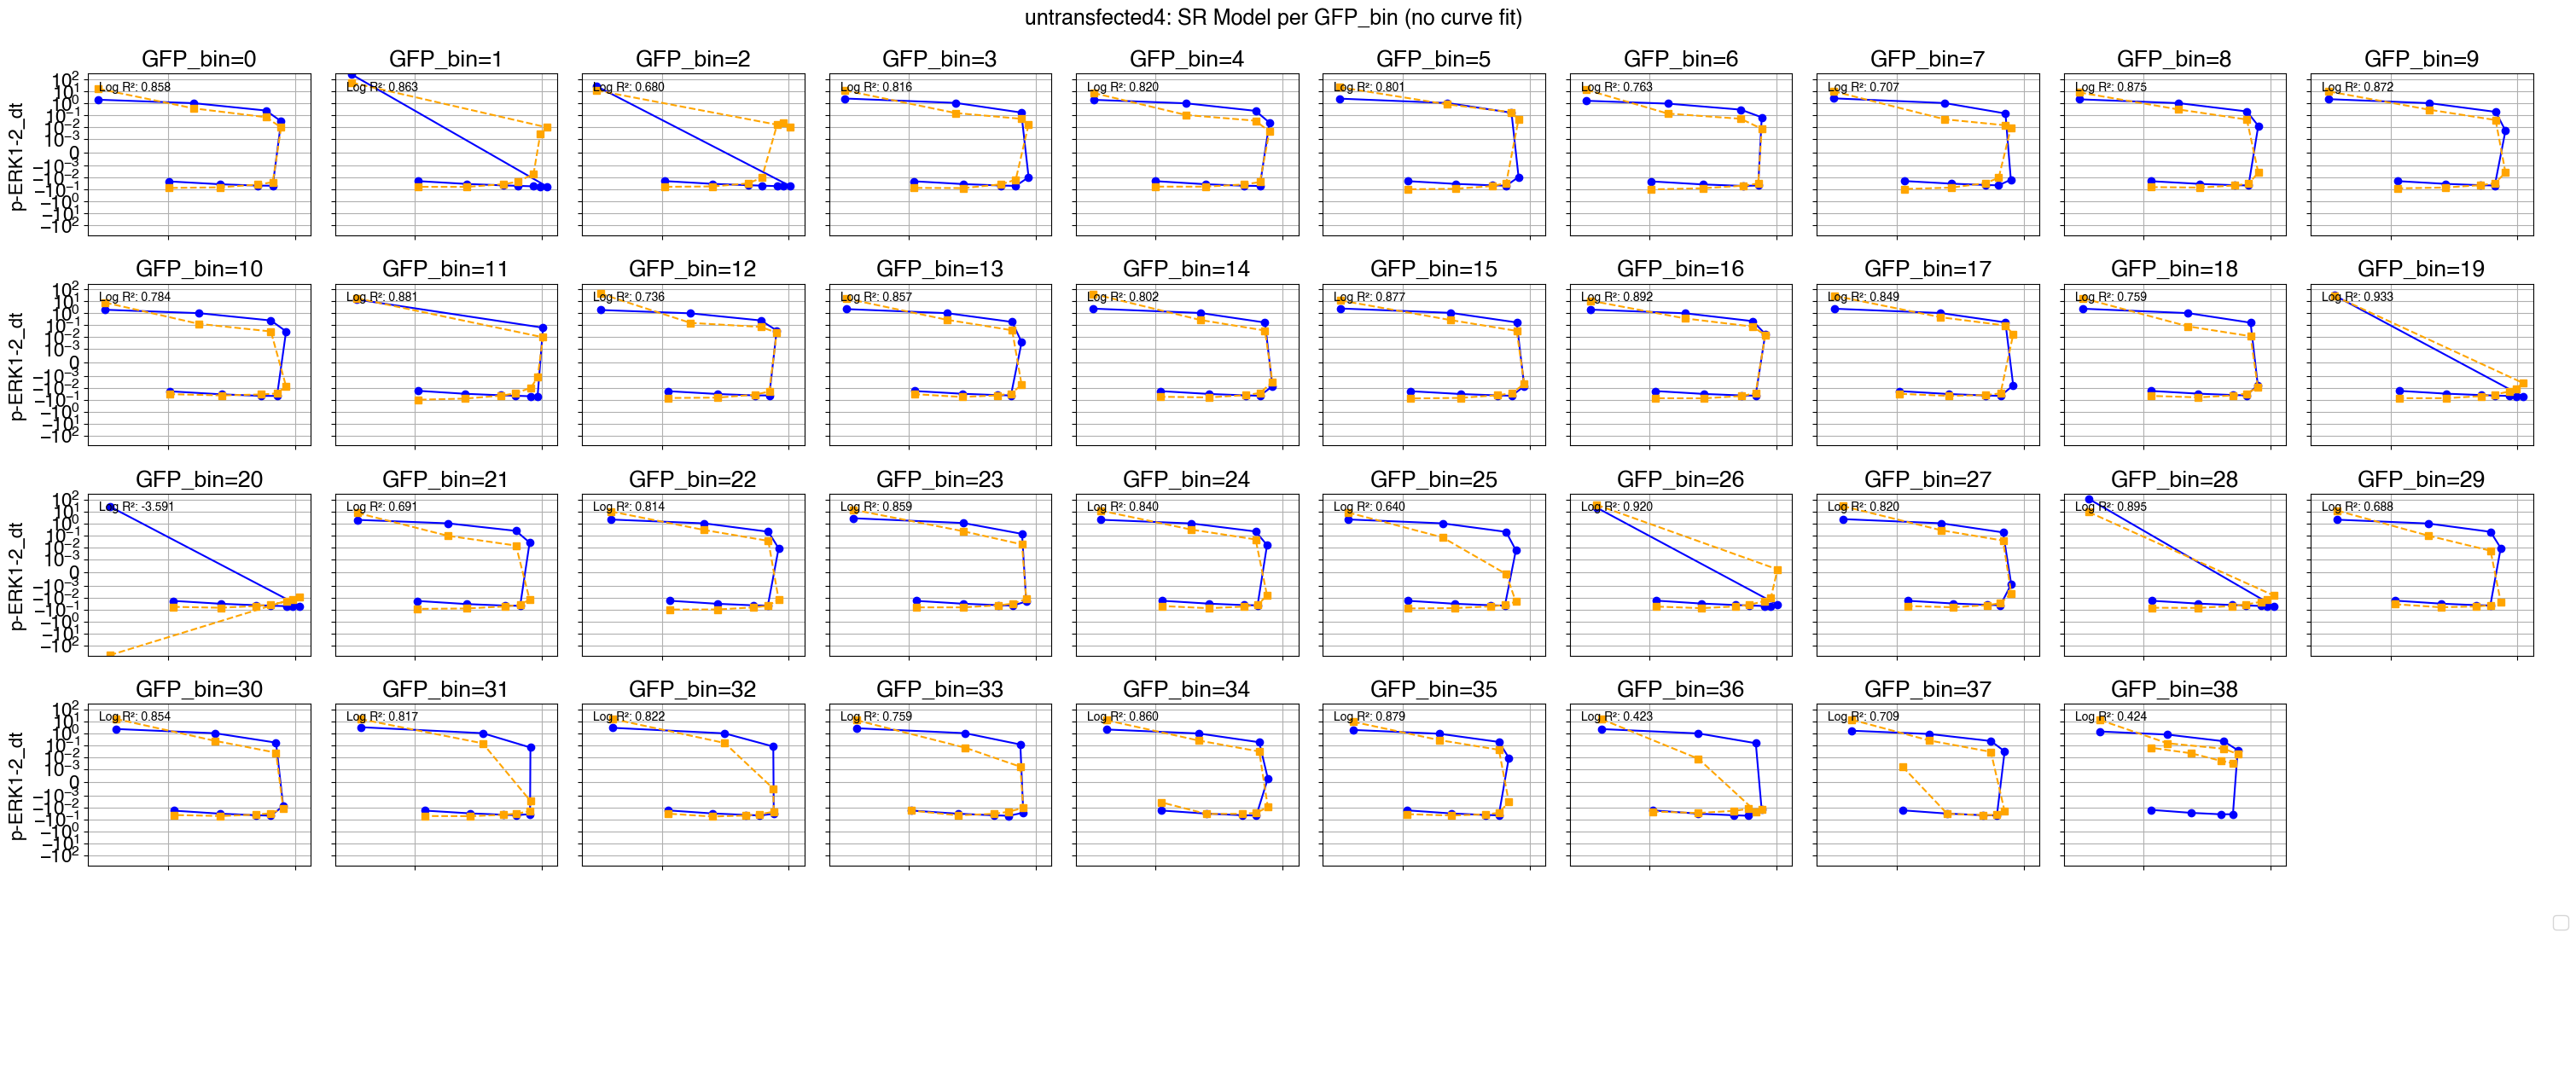

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [107]:
from sklearn.metrics import r2_score
from scipy.interpolate import interp1d
import numpy as np

import matplotlib.pyplot as plt

for marker_select in markers_choice:
    # Filter data for DUSP16
    dusp16_data = data[data['marker'] == marker_select].copy()
    dusp16_data = dusp16_data.dropna(subset=['GFP_bin', 'p-ERK1-2', 'p-ERK1-2_min', 'GFP', 'p-ERK1-2_dt'])

    # Prepare grid for plotting
    gfp_bins = np.sort(dusp16_data['GFP_bin'].unique())
    n_bins = len(gfp_bins)
    n_cols = 10
    n_rows = 5
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5), sharex=True, sharey=True)
    axes = axes.flatten()

    for i, gfp_bin in enumerate(gfp_bins):
        ax = axes[i]
        bin_data = dusp16_data[dusp16_data['GFP_bin'] == gfp_bin]
        if bin_data.empty:
            ax.axis('off')
            continue

        # Prepare input features for the SR model
        bin_data = bin_data.dropna(subset=features_choice + ['p-ERK1-2_dt'])
        X_bin = bin_data[features_choice].copy()
        X_bin.columns = X_bin.columns.str.replace('-', '_')
        y_true = bin_data['p-ERK1-2_dt'].values

        # Model prediction using the trained SR model
        
        try:
            y_pred = model.predict(X_bin)
            ax.plot(bin_data['p-ERK1-2'].values, y_true, 'o-', label='True', color='blue')
            ax.plot(bin_data['p-ERK1-2'].values, y_pred, 's--', label='SR', color='orange')
                    # Compute and print signed log R² for each GFP_bin
            y_true_log = signed_log(y_true)
            y_pred_log = signed_log(y_pred)
            r2_log = r2_score(y_true_log, y_pred_log)
            ax.text(0.05, 0.95, f"Log R²: {r2_log:.3f}", transform=ax.transAxes, fontsize=10, verticalalignment='top')
        except Exception as e:
            print(f"Error predicting for {marker_select} GFP_bin={gfp_bin}: {e}")

        ax.set_title(f'GFP_bin={int(gfp_bin)}')
        ax.grid(True)
        if i % n_cols == 0:
            ax.set_ylabel('p-ERK1-2_dt')
        if i >= (n_rows - 1) * n_cols:
            ax.set_xlabel('p-ERK1-2')

    # Hide unused subplots
    for j in range(i + 1, n_rows * n_cols):
        axes[j].axis('off')

    # Compute and print overall signed log R² across all GFP bins for DUSP16
    # Drop rows with NaN in features or target before overall R² calculation
    valid_idx = dusp16_data[features_choice + ['p-ERK1-2_dt']].dropna().index
    X_all = dusp16_data.loc[valid_idx, features_choice].copy()
    X_all.columns = X_all.columns.str.replace('-', '_')
    y_true_all = dusp16_data.loc[valid_idx, 'p-ERK1-2_dt'].values
    y_pred_all = model.predict(X_all)
    r2_log_all = r2_score(signed_log(y_true_all), signed_log(y_pred_all))
    print(f"Overall signed log R² for {marker_select} (all GFP bins, SR): {r2_log_all:.4f}")

    plt.tight_layout()
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05))
    plt.suptitle(f'{marker_select}: SR Model per GFP_bin (no curve fit)', y=1.02, fontsize=18)
    plt.yscale('symlog', linthresh=1e-3)
    plt.show()

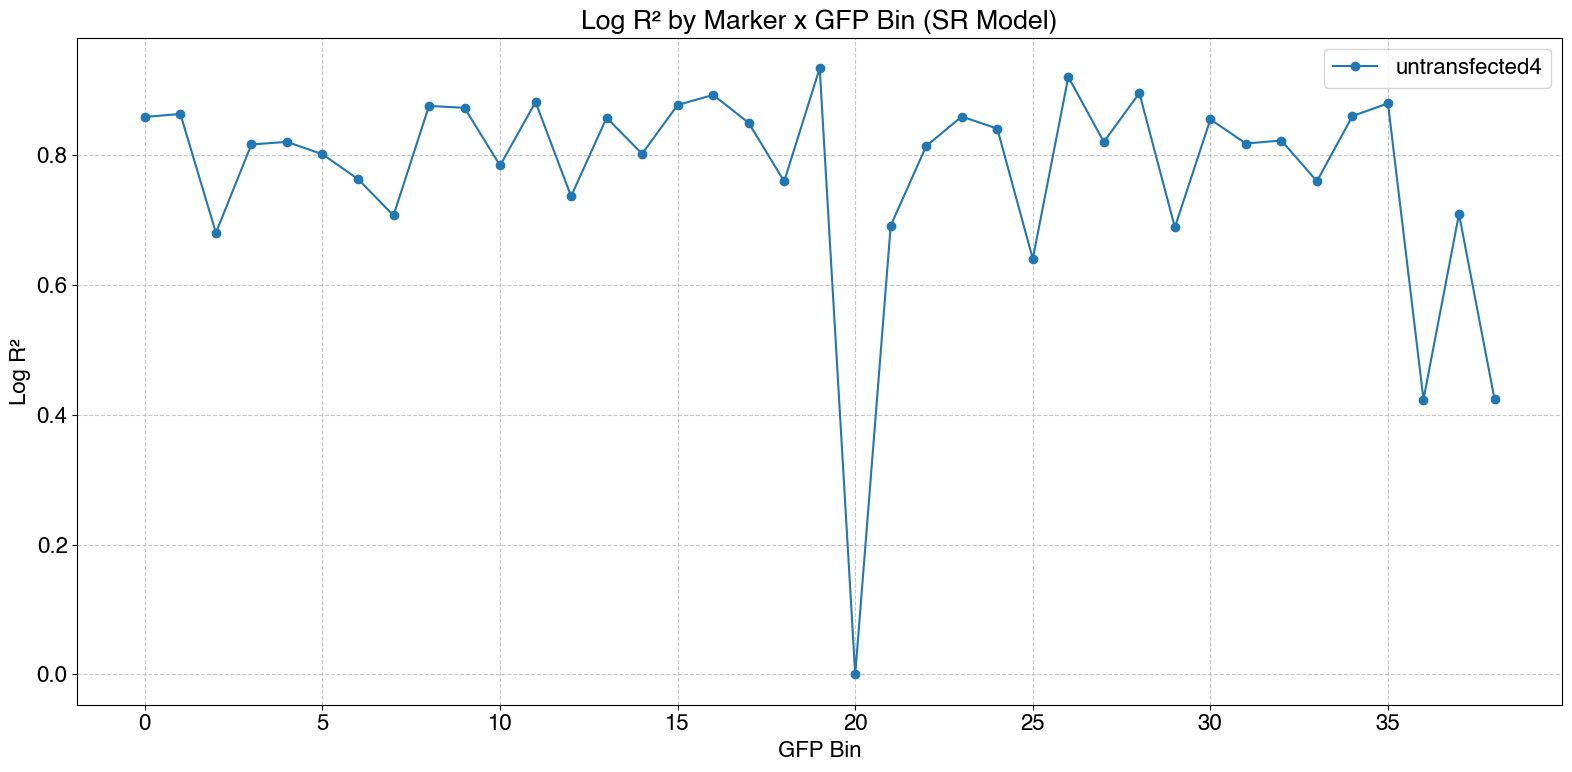

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [108]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare data
gfp_bins = np.sort(data[data['marker'].isin(markers_choice)]['GFP_bin'].unique())
n_markers = len(markers_choice)
n_bins = len(gfp_bins)
r2_matrix = np.full((n_markers, n_bins), np.nan)

for i, marker in enumerate(markers_choice):
    marker_data = data[data['marker'] == marker].dropna(subset=features_choice + ['GFP_bin', 'p-ERK1-2_dt'])
    for j, gfp_bin in enumerate(gfp_bins):
        bin_data = marker_data[marker_data['GFP_bin'] == gfp_bin]
        if len(bin_data) < 5:
            continue
        X_bin = bin_data[features_choice].copy()
        X_bin.columns = X_bin.columns.str.replace('-', '_')
        y_true = bin_data['p-ERK1-2_dt'].values
        y_pred = model.predict(X_bin)
        r2_matrix[i, j] = r2_score(signed_log(y_true), signed_log(y_pred))

plt.figure(figsize=(16, 8))
for i, marker in enumerate(markers_choice):
    plt.plot(gfp_bins, np.maximum(r2_matrix[i], 0), marker='o', label=str(marker))
plt.xlabel("GFP Bin")
plt.ylabel("Log R²")
plt.title("Log R² by Marker x GFP Bin (SR Model)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [79]:
ghdfs

NameError: name 'ghdfs' is not defined

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

Evolution

In [ ]:
import numpy as np
import pandas as pd

# Select the variable to vary
var_to_vary = X.columns[0]

# Create a base input where all features are fixed to median
base_input = X.median().to_dict()

# Define range for the chosen variable
var_range = np.linspace(X[var_to_vary].min(), X[var_to_vary].max(), 200)

# Generate input DataFrame with varied `var_to_vary`
trajectory_input = pd.DataFrame([{
    **base_input,
    var_to_vary: val
} for val in var_range])

In [ ]:
from sklearn.metrics import pairwise_distances

# Find datapoints close to the fixed feature vector
distances = pairwise_distances(X, pd.DataFrame([base_input]), metric='manhattan')
close_mask = distances.flatten() < 0.1  # adjust threshold as needed
X_close = X[close_mask]
y_close = y[close_mask]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Model prediction line
plt.plot(var_range, y_pred_traj, label='Model Prediction', linewidth=2)

# Optional: scatter real points near the fixed background
plt.scatter(X_close[var_to_vary], y_close, color='red', alpha=0.6, label='Observed Data')

plt.xlabel(var_to_vary)
plt.ylabel('p-ERK1-2_dt')
plt.title(f'Model vs Data: Varying {var_to_vary}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
unique_markers

array(['ABL1', 'AKT3', 'ALPK2', 'ARAF', 'DUSP10 (P2)', 'DUSP16', 'DUSP4',
       'DUSP7', 'DYRK2', 'DYRK3', 'EGFR', 'ERBB2', 'FGFR1', 'FLAG-GFP1',
       'FLAG-GFP2', 'FLAG-GFP3', 'FLAG-GFP4', 'MAP2K2', 'MAP4K2', 'MAPK1',
       'MAPK3', 'MAST2', 'MET', 'MST1R', 'PIK3R1', 'PIP5K3', 'PRKACA',
       'PTPN2 (P1)', 'PTPN5', 'PTPN7', 'RPS6KA1', 'RPS6KA3', 'RPS6KA6',
       'TBK1', 'TEC', 'TYRO3', 'untransfected1', 'untransfected2',
       'untransfected3', 'untransfected4'], dtype=object)

Error in callback _flush_stdio (for post_execute), with arguments args (),kwargs {}:


UnicodeDecodeError: 'utf-8' codec can't decode bytes in position 4094-4095: unexpected end of data

In [ ]:
# === Hyperparameters ===
N_MARKERS = 10
POPULATION_SIZE = 20
MAX_GENERATIONS = 50
MUTATION_RATE = 0.3
TOURNAMENT_SIZE = 3

# PySR settings
N_ITERATIONS = 200
POP_SIZE_SR = 30
POPULATIONS = 30
MAX_SIZE = 30
PARSIMONY = 0.5
ANNEALING = True
BATCHING = False
LOG_SPACE_LOSS = "my_loss(x,y)=(sign(x)*(log10(abs(x))+3)-sign(y)*(log10(abs(y))+3))^2"


In [ ]:
eval_cache = {}

def evaluate_subset(subset):
    key = tuple(sorted(subset))
    if key in eval_cache:
        return eval_cache[key]

    X_list = []
    y_list = []
    for m in subset:
        Xm, ym = get_X_y(data, m, features=best_features)
        X_list.append(Xm)
        y_list.append(ym)
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    if X.shape[0] < 3:
        return (-np.inf, None, None)

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    losses, r2s = [], []
    best_formula = None

    for tr, te in kf.split(X):
        Xt, Xv = X[tr], X[te]
        yt, yv = y[tr], y[te]

        model = PySRRegressor(
            niterations=N_ITERATIONS,
            population_size=POP_SIZE_SR,
            populations=POPULATIONS,
            maxsize=MAX_SIZE,
            parsimony=PARSIMONY,
            verbosity=0,
            batching=BATCHING,
            annealing=ANNEALING,
            elementwise_loss=LOG_SPACE_LOSS,
        )

        try:
            model.fit(Xt, yt)
        except Exception:
            continue

        eqns = model.equations_
        if eqns is None or eqns.empty:
            continue

        best_loss_fold = -np.inf
        best_r2_fold = -np.inf
        best_idx = None

        for idx in eqns.index:
            try:
                yhat = model.predict(Xv, index=idx)
                mask = (~np.isnan(yv)) & (~np.isnan(yhat))
                if not np.any(mask):
                    continue
                lv = signed_log(yv[mask])
                lp = signed_log(yhat[mask])
                loss = -np.mean(np.abs(lv - lp))
                r2 = r2_score(yv[mask], yhat[mask])

                if loss > best_loss_fold:
                    best_loss_fold = loss
                    best_r2_fold = r2
                    best_idx = idx
            except Exception:
                continue

        if best_idx is None:
            continue

        losses.append(best_loss_fold)
        r2s.append(best_r2_fold)
        best_formula = model.sympy(index=best_idx)

    if not losses:
        return (-np.inf, None, None)

    avg_loss = np.mean(losses)
    avg_r2 = np.mean(r2s)
    eval_cache[key] = (avg_loss, avg_r2, best_formula)
    return eval_cache[key]

In [ ]:
print("=== Evaluating Custom Marker Set ===\n")
marker_set = markers_DUSP  # Select the first marker set

loss, r2, formula = evaluate_subset(marker_set)
print(f"Signed-log loss: {loss:.4f}")
print(f"Average R²: {r2:.4f}")
print(f"Formula: {formula}\n")

=== Evaluating Custom Marker Set ===



/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
<lambdifygenerated-8>:2: RuntimeWarning: divide by zero encountered in divide
  return (-3.1634717)*(-1.8053489)*x1/(0.13109308*(-x1 + x6))
/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
<lambdifygenerated-15>:2: RuntimeWarning: divide by zero encountered in divide
  return (-1.5201924)*(x0 - 0.27928162*0.98960835/(-x0 + x0))
/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
<lambdifygenerated-25>:2: RuntimeWarning: di

Signed-log loss: -2.2102
Average R²: -0.0329
Formula: (x1 - x4 + x4 + x6*(-1.2924306))*0.12552293



In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from pysr import PySRRegressor

# === Hyperparameters ===
N_MARKERS = 10
POPULATION_SIZE = 20
MAX_GENERATIONS = 50
MUTATION_RATE = 0.3
TOURNAMENT_SIZE = 3

# PySR settings
N_ITERATIONS = 200
POP_SIZE_SR = 30
POPULATIONS = 30
MAX_SIZE = 30
PARSIMONY = 0.5
ANNEALING = True
BATCHING = False
LOG_SPACE_LOSS = "my_loss(x,y)=(sign(x)*(log10(abs(x))+3)-sign(y)*(log10(abs(y))+3))^2"

# Assume these helper functions exist:
# get_X_y(data, marker, features)
# signed_log(x)

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("marker", random.choice, list(unique_markers))
toolbox.register("individual", tools.initRepeat, creator.Individual,
                 toolbox.marker, n=N_MARKERS)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("select", tools.selTournament, tournsize=TOURNAMENT_SIZE)

def mate(ind1, ind2):
    p1 = random.sample(ind1, N_MARKERS//2)
    p2 = random.sample(ind2, N_MARKERS//2)
    child = list(set(p1 + p2))
    while len(child) < N_MARKERS:
        child.append(random.choice(list(unique_markers)))
    return creator.Individual(child)

def mutate(ind):
    if random.random() < MUTATION_RATE:
        idx = random.randrange(N_MARKERS)
        choices = list(set(unique_markers) - set(ind))
        if choices:
            ind[idx] = random.choice(choices)
    return ind,

toolbox.register("mate", mate)
toolbox.register("mutate", mutate)

eval_cache = {}

def evaluate_subset(subset):
    key = tuple(sorted(subset))
    if key in eval_cache:
        return eval_cache[key]

    X_list = []
    y_list = []
    for m in subset:
        Xm, ym = get_X_y(data, m, features=best_features)
        X_list.append(Xm)
        y_list.append(ym)
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    if X.shape[0] < 3:
        return (-np.inf, None, None)

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    losses, r2s = [], []
    best_formula = None

    for tr, te in kf.split(X):
        Xt, Xv = X[tr], X[te]
        yt, yv = y[tr], y[te]

        model = PySRRegressor(
            niterations=N_ITERATIONS,
            population_size=POP_SIZE_SR,
            populations=POPULATIONS,
            maxsize=MAX_SIZE,
            parsimony=PARSIMONY,
            verbosity=0,
            batching=BATCHING,
            annealing=ANNEALING,
            elementwise_loss=LOG_SPACE_LOSS,
            parallelism="multiprocessing"
        )

        try:
            model.fit(Xt, yt)
        except Exception:
            continue

        eqns = model.equations_
        if eqns is None or eqns.empty:
            continue

        best_loss_fold = -np.inf
        best_r2_fold = -np.inf
        best_idx = None

        for idx in eqns.index:
            try:
                yhat = model.predict(Xv, index=idx)
                mask = (~np.isnan(yv)) & (~np.isnan(yhat))
                if not np.any(mask):
                    continue
                print(yv[mask], yhat[mask])
                lv = signed_log(yv[mask])
                lp = signed_log(yhat[mask])
                loss = -np.mean(np.abs(lv - lp))
                r2 = r2_score(yv[mask], yhat[mask])

                if loss > best_loss_fold:
                    best_loss_fold = loss
                    best_r2_fold = r2
                    best_idx = idx
            except Exception:
                continue

        if best_idx is None:
            continue

        losses.append(best_loss_fold)
        r2s.append(best_r2_fold)
        best_formula = model.sympy(index=best_idx)

    if not losses:
        return (-np.inf, None, None)

    avg_loss = np.mean(losses)
    avg_r2 = np.mean(r2s)
    eval_cache[key] = (avg_loss, avg_r2, best_formula)
    return eval_cache[key]

def eval_wrapper(ind):
    print(f"Evaluating individual: {ind}", flush=True)
    loss, _, _ = evaluate_subset(ind)
    print(f" -> Loss = {loss:.4f}", flush=True)
    return (loss,)

toolbox.register("evaluate", eval_wrapper)

def main():
    pop = toolbox.population(n=POPULATION_SIZE)
    hof = tools.HallOfFame(1)
    stats = tools.Statistics(key=lambda ind: ind.fitness.values)
    stats.register("max", np.max)
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    logbook = tools.Logbook()
    logbook.header = ("gen", "nevals", "max", "avg", "min")

    pop, logbook_ea = algorithms.eaSimple(
        pop, toolbox,
        cxpb=0.5, mutpb=MUTATION_RATE,
        ngen=MAX_GENERATIONS,
        stats=stats, halloffame=hof,
        verbose=True
    )

    print("\n=== Generation summary ===")
    for record in logbook_ea:
        print(f"Gen {record['gen']}: evals={record['nevals']}, max={record['max']:.4f}, avg={record['avg']:.4f}, min={record['min']:.4f}")

    best = hof[0]
    best_loss, best_r2, best_formula = evaluate_subset(best)
    return list(best), best_formula, best_loss

if __name__ == "__main__":
    best_markers, best_formula, best_signed_log_loss = main()
    print("\n=== Best result ===")
    print("Markers:", best_markers)
    print("Signed-log loss:", best_signed_log_loss)
    print("Formula:", best_formula)

Evaluating individual: ['DUSP10 (P2)', 'ERBB2', 'MAP4K2', 'FLAG-GFP1', 'MAP2K2', 'MAP4K2', 'MET', 'RPS6KA1', 'EGFR', 'ALPK2']


/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMax' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/Users/pomeret/Desktop/overexpression_signalling/overexpression/lib/python3.12/site-packages/pysr/sr.py:2776: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
UNHANDLED TASK ERROR: Distributed.ProcessExitedException(16)
Stacktrace:
  [1] try_yi

 -> Loss = -inf
Evaluating individual: ['TYRO3', 'untransfected1', 'RPS6KA3', 'MST1R', 'untransfected4', 'RPS6KA3', 'RPS6KA3', 'ABL1', 'ABL1', 'RPS6KA3']


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: invalid value encountered in multiply
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: invalid value encountered in multiply
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykern

 -> Loss = -inf
Evaluating individual: ['ARAF', 'FLAG-GFP3', 'MAP4K2', 'MAPK3', 'DYRK3', 'untransfected3', 'FLAG-GFP2', 'FLAG-GFP4', 'DUSP4', 'RPS6KA6']


...

/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: invalid value encountered in multiply
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: invalid value encountered in multiply
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykern

 -> Loss = -inf
Evaluating individual: ['DUSP10 (P2)', 'PTPN2 (P1)', 'MST1R', 'untransfected1', 'RPS6KA1', 'ABL1', 'PTPN5', 'PRKACA', 'RPS6KA3', 'PTPN7']


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: invalid value encountered in multiply
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: invalid value encountered in multiply
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykern

 -> Loss = -inf
Evaluating individual: ['MST1R', 'PRKACA', 'PIP5K3', 'MAP4K2', 'TYRO3', 'EGFR', 'untransfected2', 'TEC', 'PTPN5', 'MAP4K2']


/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: invalid value encountered in multiply
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: invalid value encountered in multiply
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykernel_30432/786586995.py:12: RuntimeWarning: divide by zero encountered in log10
  return np.sign(x) * (np.log10(np.abs(x)) - epsilon)
/var/folders/pn/khhmnw650hb1xn7840m6mw8m0000gp/T/ipykern